#HEAT EQUATION

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import imageio
from IPython.display import Image, display
import cv2
from pathlib import Path

# 1. Determinism & Device
torch.manual_seed(42)
np.random.seed(42)
torch.backends.cudnn.benchmark = True
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ==========================================
# 2. Enhanced Configuration
# ==========================================
CONFIG = {
    'train_size': 64,
    'test_size': 128,
    'batch_size': 8,
    'epochs': 5000,
    'lr': 0.001,
    'weight_decay': 1e-4,
    'alpha': 0.5,
    'dt': 0.1,
    'min_steps': 40,
    'max_steps': 150,
    'val_freq': 500,

    # NEW: Extended testing parameters
    'short_test_steps': 2000,      # Original test length
    'long_test_steps': 10000,      # Much longer simulation
    'video_fps': 30,              # Higher quality video
    'frame_interval': 20,          # Capture every N steps
}

# ==========================================
# 3. Analytical Teacher (EXACT ORIGINAL)
# ==========================================
class HeatEquationSolver:
    def __init__(self, alpha, dt):
        self.alpha = alpha
        self.dt = dt
        self.kernel = torch.tensor([[0, 1, 0], [1, -4, 1], [0, 1, 0]],
                                   dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)

    def step(self, grid):
        padded = torch.nn.functional.pad(grid, (1, 1, 1, 1), mode='circular')
        laplacian = torch.nn.functional.conv2d(padded, self.kernel)
        return grid + self.alpha * laplacian * self.dt

# ==========================================
# 4. Deep Flux-NCA (EXACT ORIGINAL)
# ==========================================
class DeepFluxNCA(nn.Module):
    def __init__(self):
        super().__init__()
        self.perceive = nn.Conv2d(1, 32, 3, padding=1, padding_mode='circular')
        self.process = nn.Sequential(
            nn.ReLU(),
            nn.Conv2d(32, 64, 1),
            nn.ReLU(),
            nn.Conv2d(64, 32, 1),
            nn.ReLU(),
            nn.Conv2d(32, 2, 1, bias=False)
        )
        with torch.no_grad():
            self.process[-1].weight.data.fill_(0.0)
            nn.init.kaiming_normal_(self.perceive.weight, nonlinearity='relu')
            nn.init.kaiming_normal_(self.process[1].weight, nonlinearity='relu')
            nn.init.kaiming_normal_(self.process[3].weight, nonlinearity='relu')

    def forward(self, x):
        flux = self.process(self.perceive(x))
        flux_x, flux_y = flux[:, 0:1], flux[:, 1:2]
        dx = (torch.roll(flux_x, 1, 3) - flux_x) + (torch.roll(flux_y, 1, 2) - flux_y)
        return x + dx

# ==========================================
# 5. Generator (EXACT ORIGINAL)
# ==========================================
def make_state(batch_size, size):
    grid = torch.zeros(batch_size, 1, size, size).to(device)
    x = torch.arange(0, size).float().to(device)
    y = torch.arange(0, size).float().to(device)
    yy, xx = torch.meshgrid(y, x, indexing='ij')

    for i in range(batch_size):
        for _ in range(np.random.randint(3, 6)):
            cx, cy = np.random.randint(0, size, 2)
            sigma = size * 0.08
            amp = np.random.uniform(5.0, 10.0)
            dx = torch.abs(xx - cx); dx = torch.min(dx, size - dx)
            dy = torch.abs(yy - cy); dy = torch.min(dy, size - dy)
            grid[i, 0] += amp * torch.exp(-(dx**2 + dy**2) / (2 * sigma**2))
    return grid

# ==========================================
# 6. Training Loop (ORIGINAL with tracking)
# ==========================================
print("=" * 70)
print("TRAINING DEEP FLUX NCA ON 64×64 GRIDS")
print("=" * 70)

model = DeepFluxNCA().to(device)
solver = HeatEquationSolver(CONFIG['alpha'], CONFIG['dt'])
optimizer = optim.Adam(model.parameters(), lr=CONFIG['lr'], weight_decay=CONFIG['weight_decay'])
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=200)
loss_fn = nn.MSELoss()

loss_history = []
val_history = []
best_loss = float('inf')
best_weights = None

for i in range(CONFIG['epochs']):
    model.train()
    state = make_state(CONFIG['batch_size'], CONFIG['train_size'])
    state = state + torch.randn_like(state) * 0.02

    target = state.clone()
    pred = state.clone()
    current_steps = np.random.randint(CONFIG['min_steps'], CONFIG['max_steps'])

    seq_loss = 0
    for _ in range(current_steps):
        with torch.no_grad():
            target = solver.step(target)
        pred = model(pred)
        seq_loss += loss_fn(pred, target)

    loss_val = seq_loss / current_steps
    optimizer.zero_grad()
    loss_val.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5)
    optimizer.step()
    scheduler.step(loss_val)
    loss_history.append(loss_val.item())

    if i % CONFIG['val_freq'] == 0:
        model.eval()
        with torch.no_grad():
            v_state = make_state(CONFIG['batch_size'], CONFIG['train_size'])
            v_target, v_pred = v_state.clone(), v_state.clone()
            for _ in range(20):
                v_target = solver.step(v_target)
                v_pred = model(v_pred)
            v_loss = loss_fn(v_pred, v_target).item()
            val_history.append((i, v_loss))
            print(f"Epoch {i:4d}: Train Loss {loss_val.item():.7f} | Val Loss {v_loss:.7f}")

    if loss_val.item() < best_loss:
        best_loss = loss_val.item()
        best_weights = model.state_dict()

model.load_state_dict(best_weights)
print(f"\n✓ Training Complete! Best Loss: {best_loss:.7f}\n")

# ==========================================
# 7. NEW: Multi-Scale Testing Function
# ==========================================
def run_comparison(model, solver, size, steps, title_prefix, save_prefix):
    """
    Run comparative simulation and generate visualizations
    """
    print(f"\n{'='*70}")
    print(f"{title_prefix}: {size}×{size} for {steps} steps")
    print(f"{'='*70}")

    init_state = make_state(1, size)
    curr_t = init_state.clone()
    curr_m = init_state.clone()

    frames = []
    mse_series = []
    energy_pct_error = []
    max_abs_error = []
    start_E = torch.sum(init_state).item()
    max_v = torch.max(init_state).item()

    # Determine if we need video or GIF
    use_video = steps > 1000
    frame_interval = CONFIG['frame_interval']

    for t in range(steps):
        with torch.no_grad():
            curr_t = solver.step(curr_t)
            curr_m = model(curr_m)

        mse = torch.mean((curr_t - curr_m)**2).item()
        mse_series.append(mse)

        model_energy = torch.sum(curr_m).item()
        energy_pct_error.append(abs(model_energy - start_E) / start_E * 100.0)

        max_err = torch.max(torch.abs(curr_t - curr_m)).item()
        max_abs_error.append(max_err)

        # Capture frames
        if t % frame_interval == 0:
            fig, ax = plt.subplots(1, 3, figsize=(18, 5))

            ax[0].imshow(curr_t.cpu().squeeze().numpy(), cmap='inferno', vmin=0, vmax=max_v)
            ax[0].set_title(f"Analytical Solution (t={t})", fontsize=14, fontweight='bold')
            ax[0].axis('off')

            ax[1].imshow(curr_m.cpu().squeeze().numpy(), cmap='inferno', vmin=0, vmax=max_v)
            ax[1].set_title(f"Flux-NCA Prediction (t={t})", fontsize=14, fontweight='bold')
            ax[1].axis('off')

            diff = torch.abs(curr_t - curr_m).cpu().squeeze().numpy()
            im = ax[2].imshow(diff, cmap='viridis', vmin=0, vmax=max_v*0.15)
            ax[2].set_title(f"Absolute Error\nMSE: {mse:.6f}", fontsize=14, fontweight='bold')
            ax[2].axis('off')

            plt.colorbar(im, ax=ax[2], fraction=0.046, pad=0.04)
            plt.tight_layout()

            fig.canvas.draw()
            frame = np.asarray(fig.canvas.buffer_rgba())[:, :, :3]
            frames.append(frame)
            plt.close()

        if (t + 1) % 100 == 0:
            print(f"  Step {t+1}/{steps}: MSE={mse:.6f}, Energy Drift={energy_pct_error[-1]:.4f}%")

    # Save as video or GIF
    output_path = f'{save_prefix}_comparison.{"mp4" if use_video else "gif"}'
    if use_video:
        # Save as MP4 with better quality
        height, width = frames[0].shape[:2]
        fourcc = cv2.VideoWriter_fourcc(*'mp4v')
        out = cv2.VideoWriter(output_path, fourcc, CONFIG['video_fps'], (width, height))
        for frame in frames:
            out.write(cv2.cvtColor(frame, cv2.COLOR_RGB2BGR))
        out.release()
        print(f"\n✓ Video saved: {output_path}")
    else:
        imageio.mimsave(output_path, frames, fps=15)
        print(f"\n✓ GIF saved: {output_path}")

    # Generate metrics plots
    fig, ax = plt.subplots(2, 2, figsize=(16, 12))

    # MSE over time
    ax[0, 0].plot(mse_series, color='purple', linewidth=2)
    ax[0, 0].set_title(f'MSE Evolution ({size}×{size})', fontsize=14, fontweight='bold')
    ax[0, 0].set_xlabel('Time Step')
    ax[0, 0].set_ylabel('MSE')
    ax[0, 0].set_yscale('log')
    ax[0, 0].grid(True, alpha=0.3)

    # Energy conservation
    ax[0, 1].plot(energy_pct_error, color='green', linewidth=2)
    ax[0, 1].set_title(f'Energy Conservation ({size}×{size})', fontsize=14, fontweight='bold')
    ax[0, 1].set_xlabel('Time Step')
    ax[0, 1].set_ylabel('Energy Drift (%)')
    ax[0, 1].grid(True, alpha=0.3)

    # Max absolute error
    ax[1, 0].plot(max_abs_error, color='red', linewidth=2)
    ax[1, 0].set_title(f'Maximum Absolute Error ({size}×{size})', fontsize=14, fontweight='bold')
    ax[1, 0].set_xlabel('Time Step')
    ax[1, 0].set_ylabel('Max |Error|')
    ax[1, 0].set_yscale('log')
    ax[1, 0].grid(True, alpha=0.3)

    # Final heatmaps comparison
    ax[1, 1].axis('off')
    summary_text = f"""
    SUMMARY STATISTICS ({size}×{size}, {steps} steps)
    {'='*45}

    Final MSE:              {mse_series[-1]:.6e}
    Mean MSE:               {np.mean(mse_series):.6e}
    Max MSE:                {np.max(mse_series):.6e}

    Final Energy Drift:     {energy_pct_error[-1]:.4f}%
    Mean Energy Drift:      {np.mean(energy_pct_error):.4f}%

    Final Max Error:        {max_abs_error[-1]:.6e}
    Mean Max Error:         {np.mean(max_abs_error):.6e}
    """
    ax[1, 1].text(0.1, 0.5, summary_text, fontsize=12, family='monospace',
                  verticalalignment='center')

    plt.tight_layout()
    plt.savefig(f'{save_prefix}_metrics.png', dpi=150, bbox_inches='tight')
    print(f"✓ Metrics plot saved: {save_prefix}_metrics.png")
    plt.show()

    return {
        'mse_series': mse_series,
        'energy_error': energy_pct_error,
        'max_abs_error': max_abs_error,
        'final_analytical': curr_t,
        'final_model': curr_m
    }

# ==========================================
# 8. Run All Tests
# ==========================================

# Test 1: Same size as training (64×64) - Short
results_64_short = run_comparison(
    model, solver,
    size=64,
    steps=CONFIG['short_test_steps'],
    title_prefix="TEST 1: Training Scale (Short)",
    save_prefix="64x64_short"
)

# Test 2: Same size as training (64×64) - Long
results_64_long = run_comparison(
    model, solver,
    size=64,
    steps=CONFIG['long_test_steps'],
    title_prefix="TEST 2: Training Scale (Long)",
    save_prefix="64x64_long"
)

# Test 3: Generalization to larger size (128×128) - Short
results_128_short = run_comparison(
    model, solver,
    size=128,
    steps=CONFIG['short_test_steps'],
    title_prefix="TEST 3: Generalization to Larger Scale (Short)",
    save_prefix="128x128_short"
)

# Test 4: Generalization to larger size (128×128) - Long
results_128_long = run_comparison(
    model, solver,
    size=128,
    steps=CONFIG['long_test_steps'],
    title_prefix="TEST 4: Generalization to Larger Scale (Long)",
    save_prefix="128x128_long"
)

# ==========================================
# 9. Cross-Comparison Visualization
# ==========================================
print("\n" + "="*70)
print("GENERATING CROSS-SCALE COMPARISON")
print("="*70)

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# MSE Comparison
axes[0, 0].plot(results_64_short['mse_series'], label='64×64 (400 steps)', linewidth=2)
axes[0, 0].plot(results_64_long['mse_series'], label='64×64 (2000 steps)', linewidth=2, alpha=0.7)
axes[0, 0].plot(results_128_short['mse_series'], label='128×128 (400 steps)', linewidth=2)
axes[0, 0].plot(results_128_long['mse_series'], label='128×128 (2000 steps)', linewidth=2, alpha=0.7)
axes[0, 0].set_title('MSE Comparison Across Scales', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Time Step')
axes[0, 0].set_ylabel('MSE')
axes[0, 0].set_yscale('log')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Energy Conservation Comparison
axes[0, 1].plot(results_64_short['energy_error'], label='64×64 (400 steps)', linewidth=2)
axes[0, 1].plot(results_64_long['energy_error'], label='64×64 (2000 steps)', linewidth=2, alpha=0.7)
axes[0, 1].plot(results_128_short['energy_error'], label='128×128 (400 steps)', linewidth=2)
axes[0, 1].plot(results_128_long['energy_error'], label='128×128 (2000 steps)', linewidth=2, alpha=0.7)
axes[0, 1].set_title('Energy Conservation Across Scales', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Time Step')
axes[0, 1].set_ylabel('Energy Drift (%)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Training History
axes[1, 0].plot(loss_history, alpha=0.3, label='Train Loss', linewidth=1)
if val_history:
    v_idx, v_val = zip(*val_history)
    axes[1, 0].plot(v_idx, v_val, 'o-', color='red', label='Val Loss', markersize=4)
axes[1, 0].set_yscale('log')
axes[1, 0].set_title('Training History', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Final State Comparison
axes[1, 1].axis('off')
comparison_text = f"""
GENERALIZATION ANALYSIS
{'='*50}

64×64 (Training Scale):
  Final MSE (400 steps):   {results_64_short['mse_series'][-1]:.6e}
  Final MSE (2000 steps):  {results_64_long['mse_series'][-1]:.6e}
  Energy Drift (2000):     {results_64_long['energy_error'][-1]:.4f}%

128×128 (2× Generalization):
  Final MSE (400 steps):   {results_128_short['mse_series'][-1]:.6e}
  Final MSE (2000 steps):  {results_128_long['mse_series'][-1]:.6e}
  Energy Drift (2000):     {results_128_long['energy_error'][-1]:.4f}%

Generalization Ratio (MSE @ 2000 steps):
  128×128 / 64×64:         {results_128_long['mse_series'][-1] / results_64_long['mse_series'][-1]:.2f}×
"""
axes[1, 1].text(0.1, 0.5, comparison_text, fontsize=11, family='monospace',
                verticalalignment='center')

plt.tight_layout()
plt.savefig('cross_scale_comparison.png', dpi=150, bbox_inches='tight')
print("✓ Cross-scale comparison saved: cross_scale_comparison.png")
plt.show()

print("\n" + "="*70)
print("ALL TESTS COMPLETE!")
print("="*70)
print("\nGenerated files:")
print("  • 64x64_short_comparison.gif")
print("  • 64x64_long_comparison.mp4")
print("  • 128x128_short_comparison.gif")
print("  • 128x128_long_comparison.mp4")
print("  • Individual metrics plots for each test")
print("  • cross_scale_comparison.png")

TRAINING DEEP FLUX NCA ON 64×64 GRIDS
Epoch    0: Train Loss 0.0243598 | Val Loss 0.0104019
Epoch  500: Train Loss 0.0000407 | Val Loss 0.0000492
Epoch 1000: Train Loss 0.0000885 | Val Loss 0.0000262


KeyboardInterrupt: 

In [1]:
import torch
import torch.nn as nn

# ==========================================
# Model Definition
# ==========================================
class DeepFluxNCA(nn.Module):
    def __init__(self):
        super().__init__()
        self.perceive = nn.Conv2d(1, 32, 3, padding=1, padding_mode='circular')
        self.process = nn.Sequential(
            nn.ReLU(),
            nn.Conv2d(32, 64, 1),
            nn.ReLU(),
            nn.Conv2d(64, 32, 1),
            nn.ReLU(),
            nn.Conv2d(32, 2, 1, bias=False)
        )

    def forward(self, x):
        flux = self.process(self.perceive(x))
        flux_x, flux_y = flux[:, 0:1], flux[:, 1:2]
        dx = (torch.roll(flux_x, 1, 3) - flux_x) + (torch.roll(flux_y, 1, 2) - flux_y)
        return x + dx

# ==========================================
# Simple Print - Just use print()!
# ==========================================
model = DeepFluxNCA()

print("="*70)
print("MODEL ARCHITECTURE")
print("="*70)
print(model)

print("\n" + "="*70)
print("PARAMETER COUNT")
print("="*70)
total = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total:,}")
print(f"Trainable parameters: {trainable:,}")

MODEL ARCHITECTURE
DeepFluxNCA(
  (perceive): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), padding_mode=circular)
  (process): Sequential(
    (0): ReLU()
    (1): Conv2d(32, 64, kernel_size=(1, 1), stride=(1, 1))
    (2): ReLU()
    (3): Conv2d(64, 32, kernel_size=(1, 1), stride=(1, 1))
    (4): ReLU()
    (5): Conv2d(32, 2, kernel_size=(1, 1), stride=(1, 1), bias=False)
  )
)

PARAMETER COUNT
Total parameters: 4,576
Trainable parameters: 4,576


In [2]:
!pip install torchviz graphviz

In [3]:
import torch
from torchviz import make_dot

# Create model and dummy input
model = DeepFluxNCA().to(device)
x = torch.randn(1, 1, 64, 64).to(device)

# Forward pass
y = model(x)

# Generate and save the graph
dot = make_dot(y, params=dict(model.named_parameters()))
dot.render("model_architecture", format="png")  # Saves as model_architecture.png

NameError: name 'device' is not defined

TRAINING DEEP FLUX NCA ON 64×64 GRIDS

MEMORY & PERFORMANCE - Before Training
RAM Usage:      0.24 GB (Current: 0.76 GB)
VRAM Usage:     0.00 GB (Current: 0.00 GB)
VRAM Peak:      0.00 GB
Elapsed Time:   0:00:08



/usr/local/lib/python3.12/dist-packages/torch/optim/lr_scheduler.py:1343: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  current = float(metrics)


Epoch    0: Train Loss 0.0243598 | Val MSE 0.0104019 | Val MAE 0.0520367 | Val PSNR 42.79 dB
Epoch  500: Train Loss 0.0000795 | Val MSE 0.0000754 | Val MAE 0.0051569 | Val PSNR 63.82 dB
Epoch 1000: Train Loss 0.0000322 | Val MSE 0.0000078 | Val MAE 0.0015663 | Val PSNR 73.10 dB
Epoch 1500: Train Loss 0.0000200 | Val MSE 0.0000093 | Val MAE 0.0017138 | Val PSNR 73.17 dB
Epoch 2000: Train Loss 0.0000145 | Val MSE 0.0000047 | Val MAE 0.0012251 | Val PSNR 76.12 dB
Epoch 2500: Train Loss 0.0000189 | Val MSE 0.0000046 | Val MAE 0.0011868 | Val PSNR 77.60 dB
Epoch 3000: Train Loss 0.0000127 | Val MSE 0.0000031 | Val MAE 0.0010619 | Val PSNR 75.71 dB
Epoch 3500: Train Loss 0.0000121 | Val MSE 0.0000044 | Val MAE 0.0011776 | Val PSNR 75.84 dB
Epoch 4000: Train Loss 0.0000129 | Val MSE 0.0000030 | Val MAE 0.0009640 | Val PSNR 77.05 dB
Epoch 4500: Train Loss 0.0000152 | Val MSE 0.0000028 | Val MAE 0.0009156 | Val PSNR 75.78 dB

✓ Best model weights saved to best_flux_nca_model.pth
  Best epoch: 4

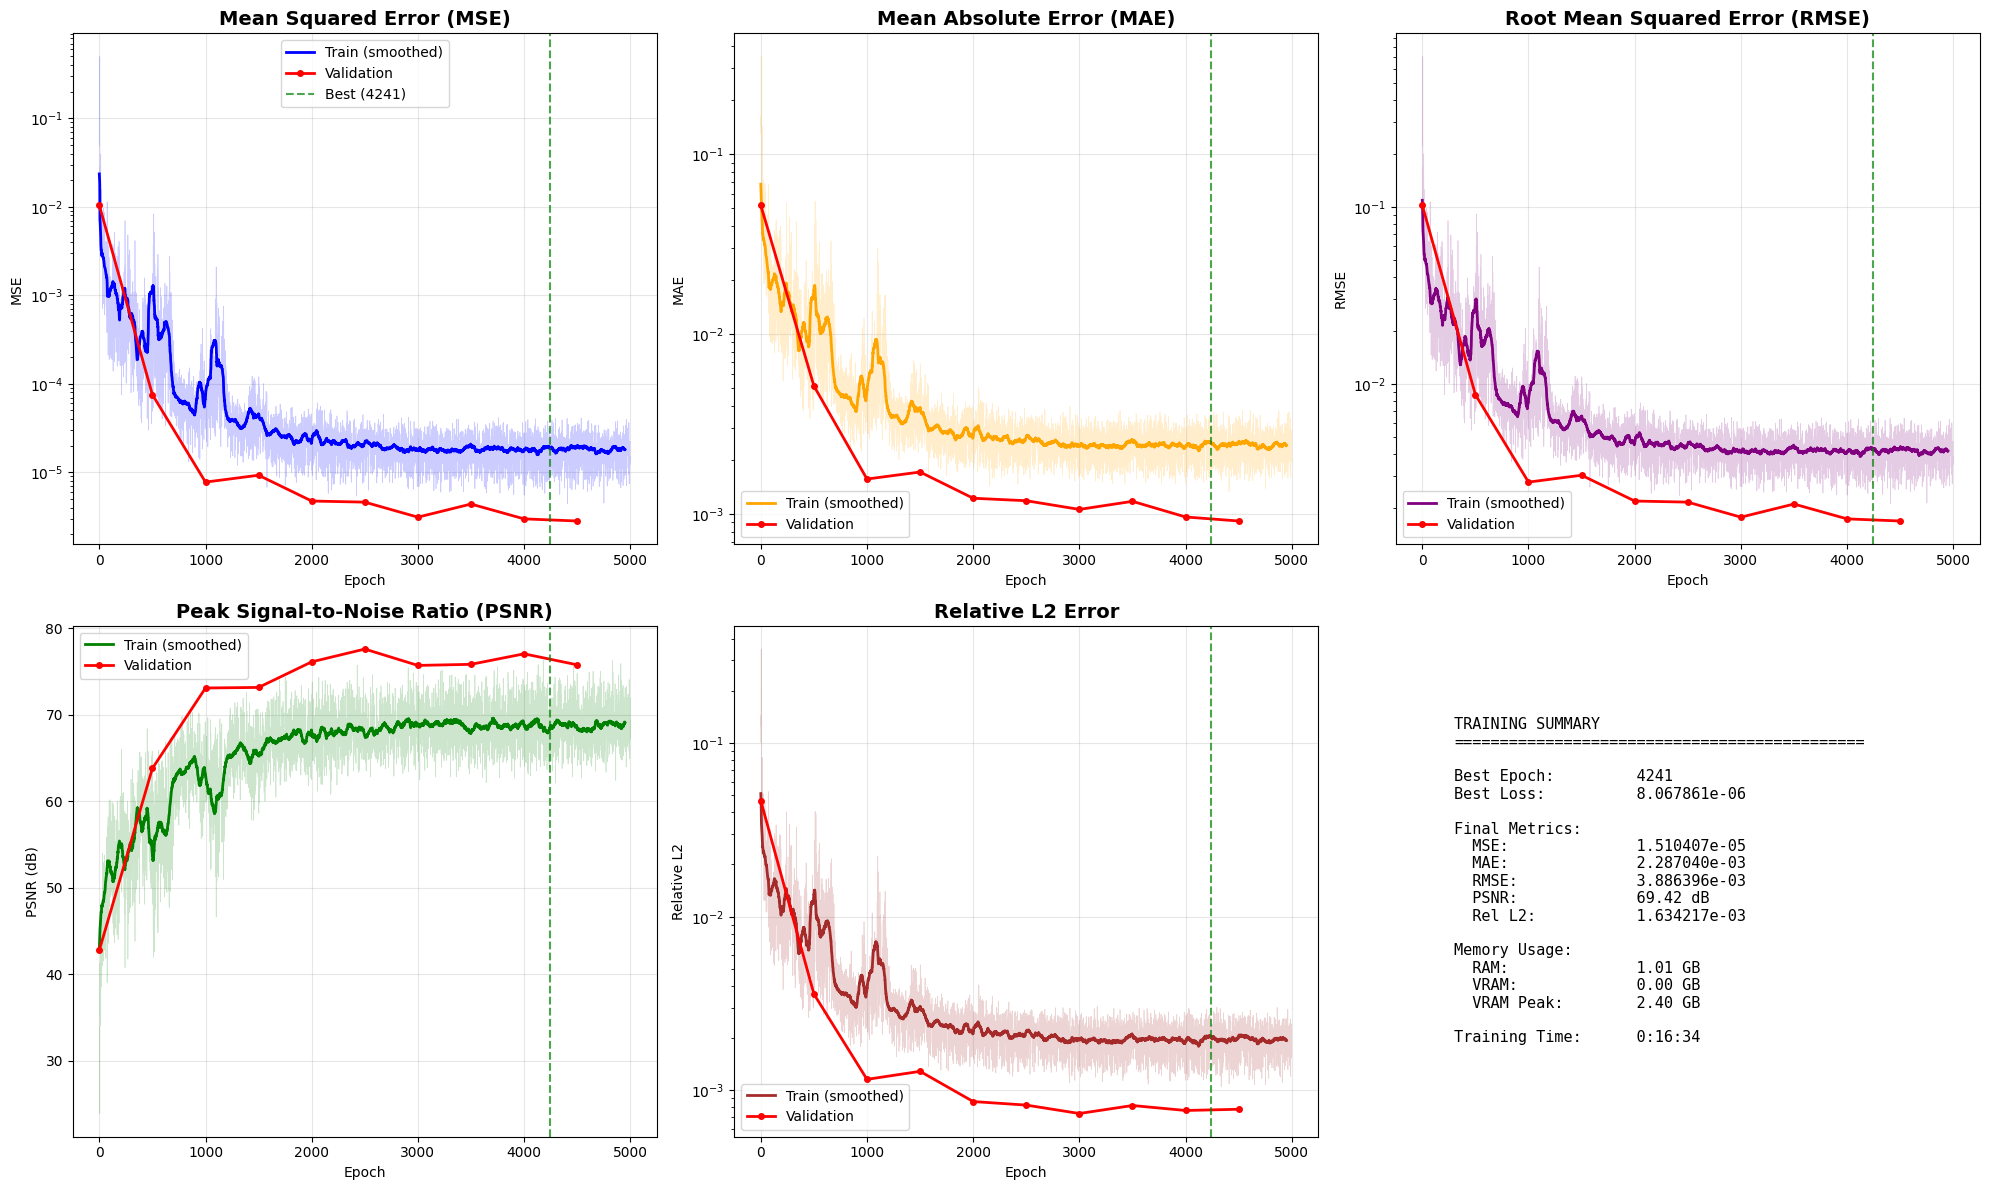


MEMORY & PERFORMANCE - Before Testing
RAM Usage:      1.11 GB (Current: 1.63 GB)
VRAM Usage:     0.00 GB (Current: 0.00 GB)
VRAM Peak:      2.40 GB
Elapsed Time:   0:16:37


TEST 1: Training Scale (Short): 64×64 for 2000 steps
  Step 100/2000: MSE=4.45e-06, MAE=1.50e-03, PSNR=70.12 dB
  Step 200/2000: MSE=1.00e-05, MAE=2.36e-03, PSNR=64.50 dB
  Step 300/2000: MSE=1.69e-05, MAE=3.18e-03, PSNR=60.52 dB
  Step 400/2000: MSE=2.43e-05, MAE=3.91e-03, PSNR=57.55 dB
  Step 500/2000: MSE=3.22e-05, MAE=4.55e-03, PSNR=55.15 dB
  Step 600/2000: MSE=3.95e-05, MAE=5.09e-03, PSNR=53.24 dB
  Step 700/2000: MSE=4.53e-05, MAE=5.51e-03, PSNR=51.77 dB
  Step 800/2000: MSE=4.91e-05, MAE=5.78e-03, PSNR=50.66 dB
  Step 900/2000: MSE=5.12e-05, MAE=5.93e-03, PSNR=49.80 dB
  Step 1000/2000: MSE=5.19e-05, MAE=6.00e-03, PSNR=49.15 dB
  Step 1100/2000: MSE=5.16e-05, MAE=6.03e-03, PSNR=48.66 dB
  Step 1200/2000: MSE=5.07e-05, MAE=6.02e-03, PSNR=48.27 dB
  Step 1300/2000: MSE=4.94e-05, MAE=5.99e-03, PSNR=47.96 dB
 

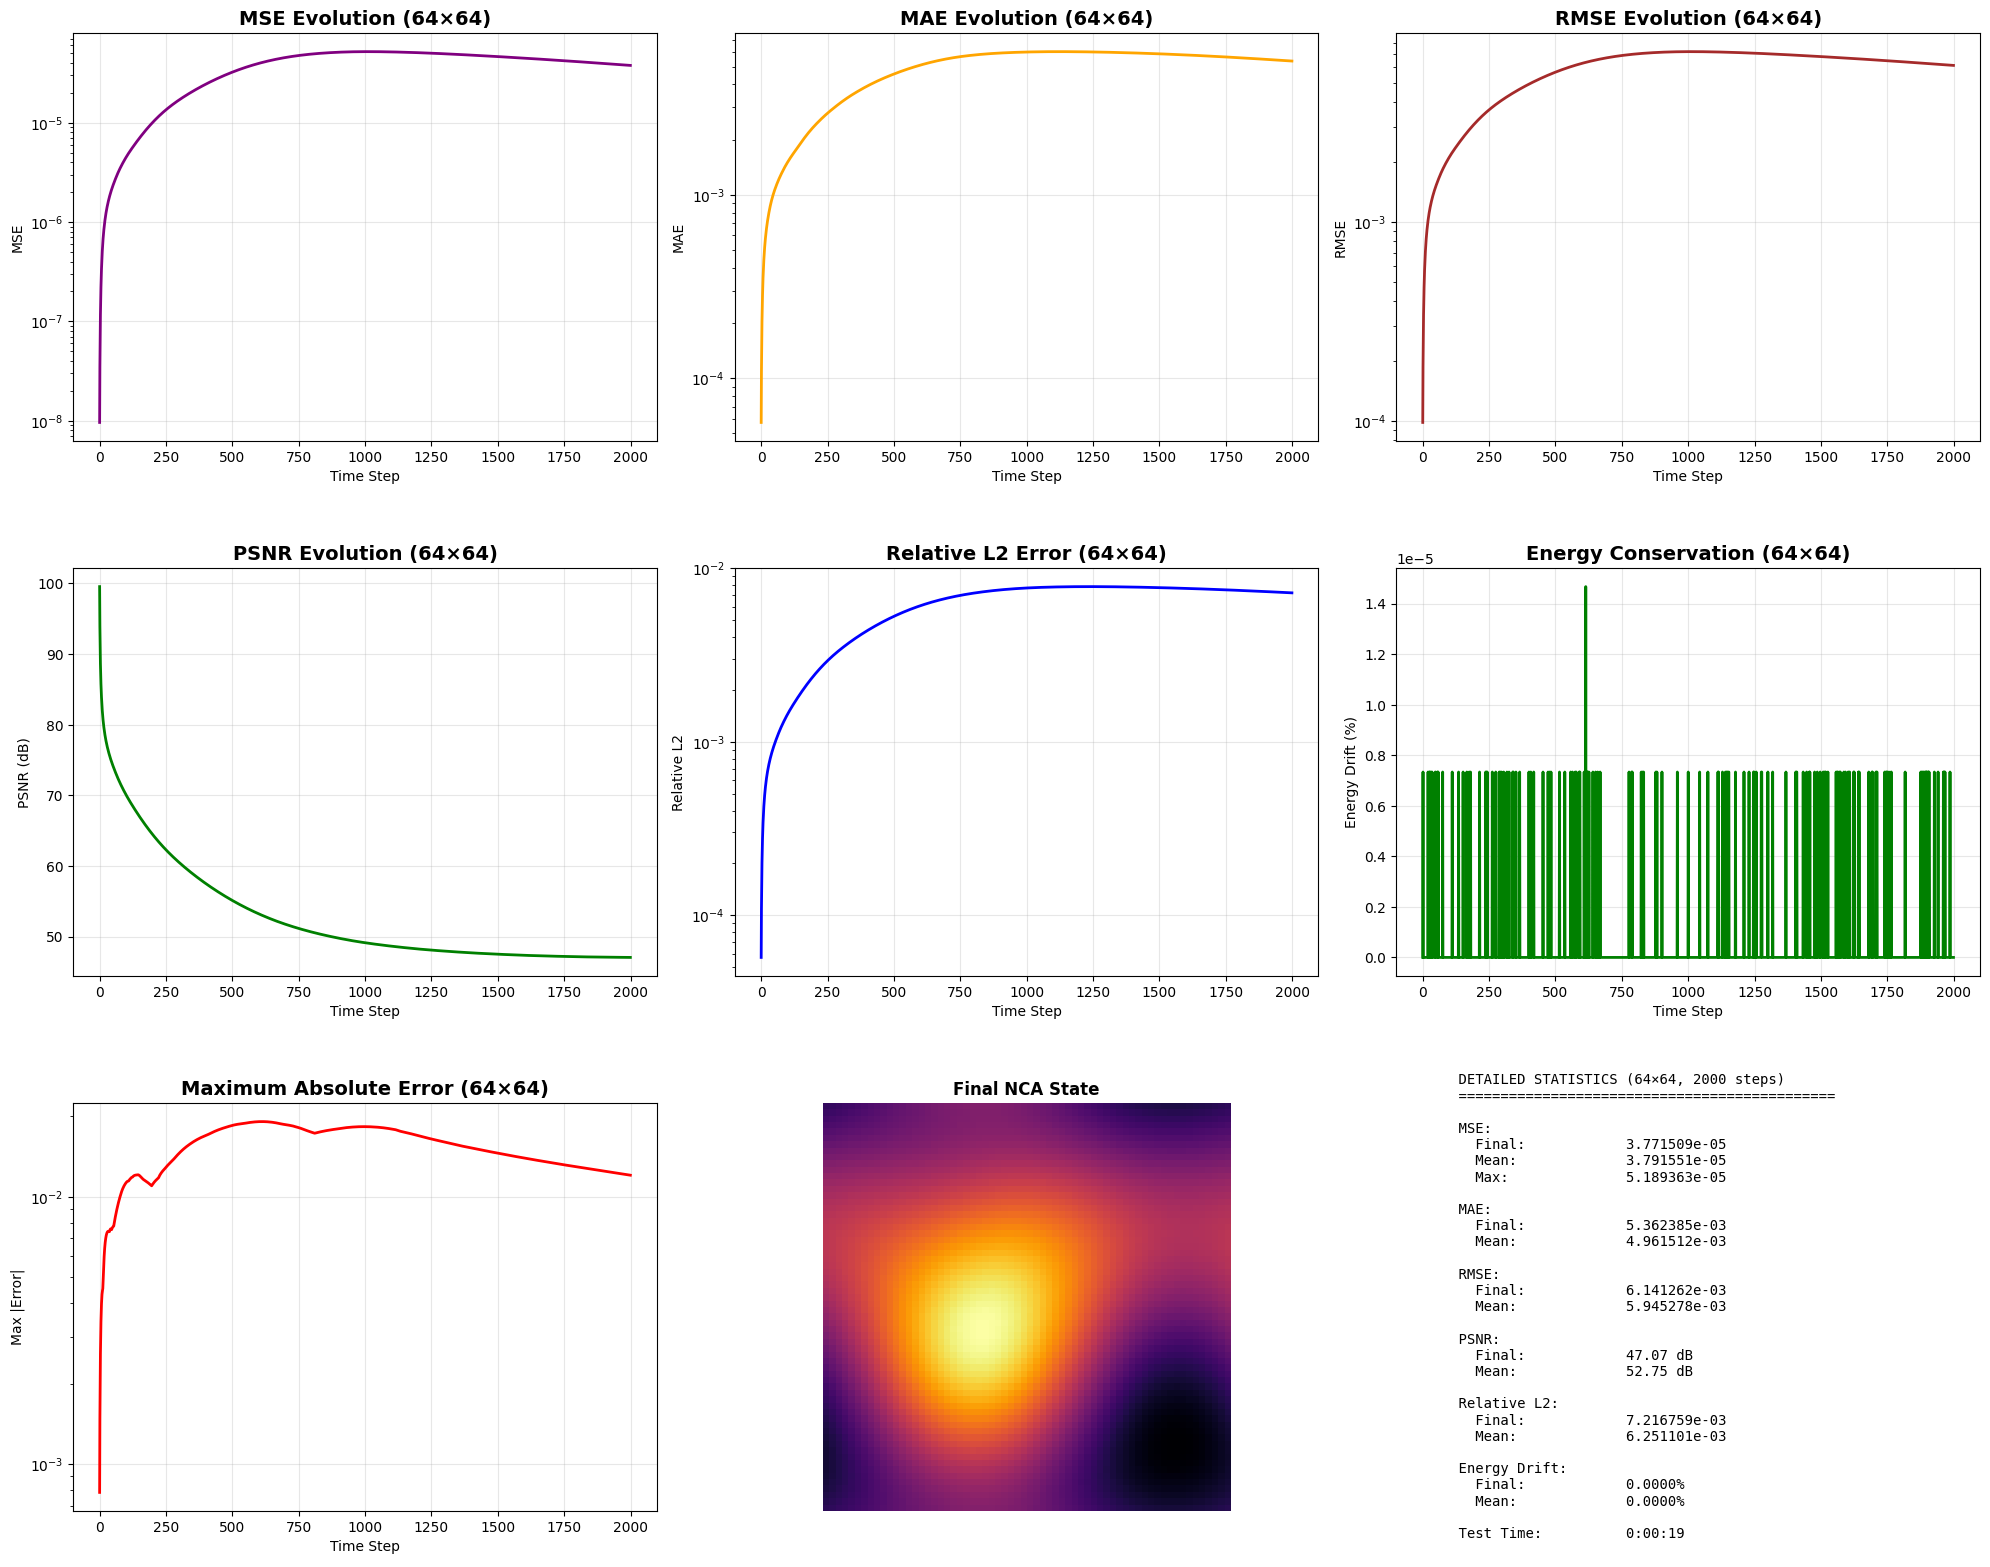


TEST 2: Training Scale (Long): 64×64 for 10000 steps
  Step 100/10000: MSE=3.24e-05, MAE=3.63e-03, PSNR=63.22 dB
  Step 200/10000: MSE=5.25e-05, MAE=4.91e-03, PSNR=59.50 dB
  Step 300/10000: MSE=6.18e-05, MAE=5.61e-03, PSNR=57.47 dB
  Step 400/10000: MSE=6.85e-05, MAE=6.10e-03, PSNR=55.89 dB
  Step 500/10000: MSE=7.44e-05, MAE=6.48e-03, PSNR=54.57 dB
  Step 600/10000: MSE=7.94e-05, MAE=6.76e-03, PSNR=53.44 dB
  Step 700/10000: MSE=8.38e-05, MAE=7.03e-03, PSNR=52.47 dB
  Step 800/10000: MSE=8.73e-05, MAE=7.22e-03, PSNR=51.64 dB
  Step 900/10000: MSE=8.96e-05, MAE=7.33e-03, PSNR=50.96 dB
  Step 1000/10000: MSE=9.04e-05, MAE=7.38e-03, PSNR=50.40 dB
  Step 1100/10000: MSE=9.01e-05, MAE=7.40e-03, PSNR=49.96 dB
  Step 1200/10000: MSE=8.89e-05, MAE=7.40e-03, PSNR=49.61 dB
  Step 1300/10000: MSE=8.69e-05, MAE=7.36e-03, PSNR=49.33 dB
  Step 1400/10000: MSE=8.44e-05, MAE=7.28e-03, PSNR=49.12 dB
  Step 1500/10000: MSE=8.14e-05, MAE=7.18e-03, PSNR=48.97 dB
  Step 1600/10000: MSE=7.81e-05, MAE=7.0

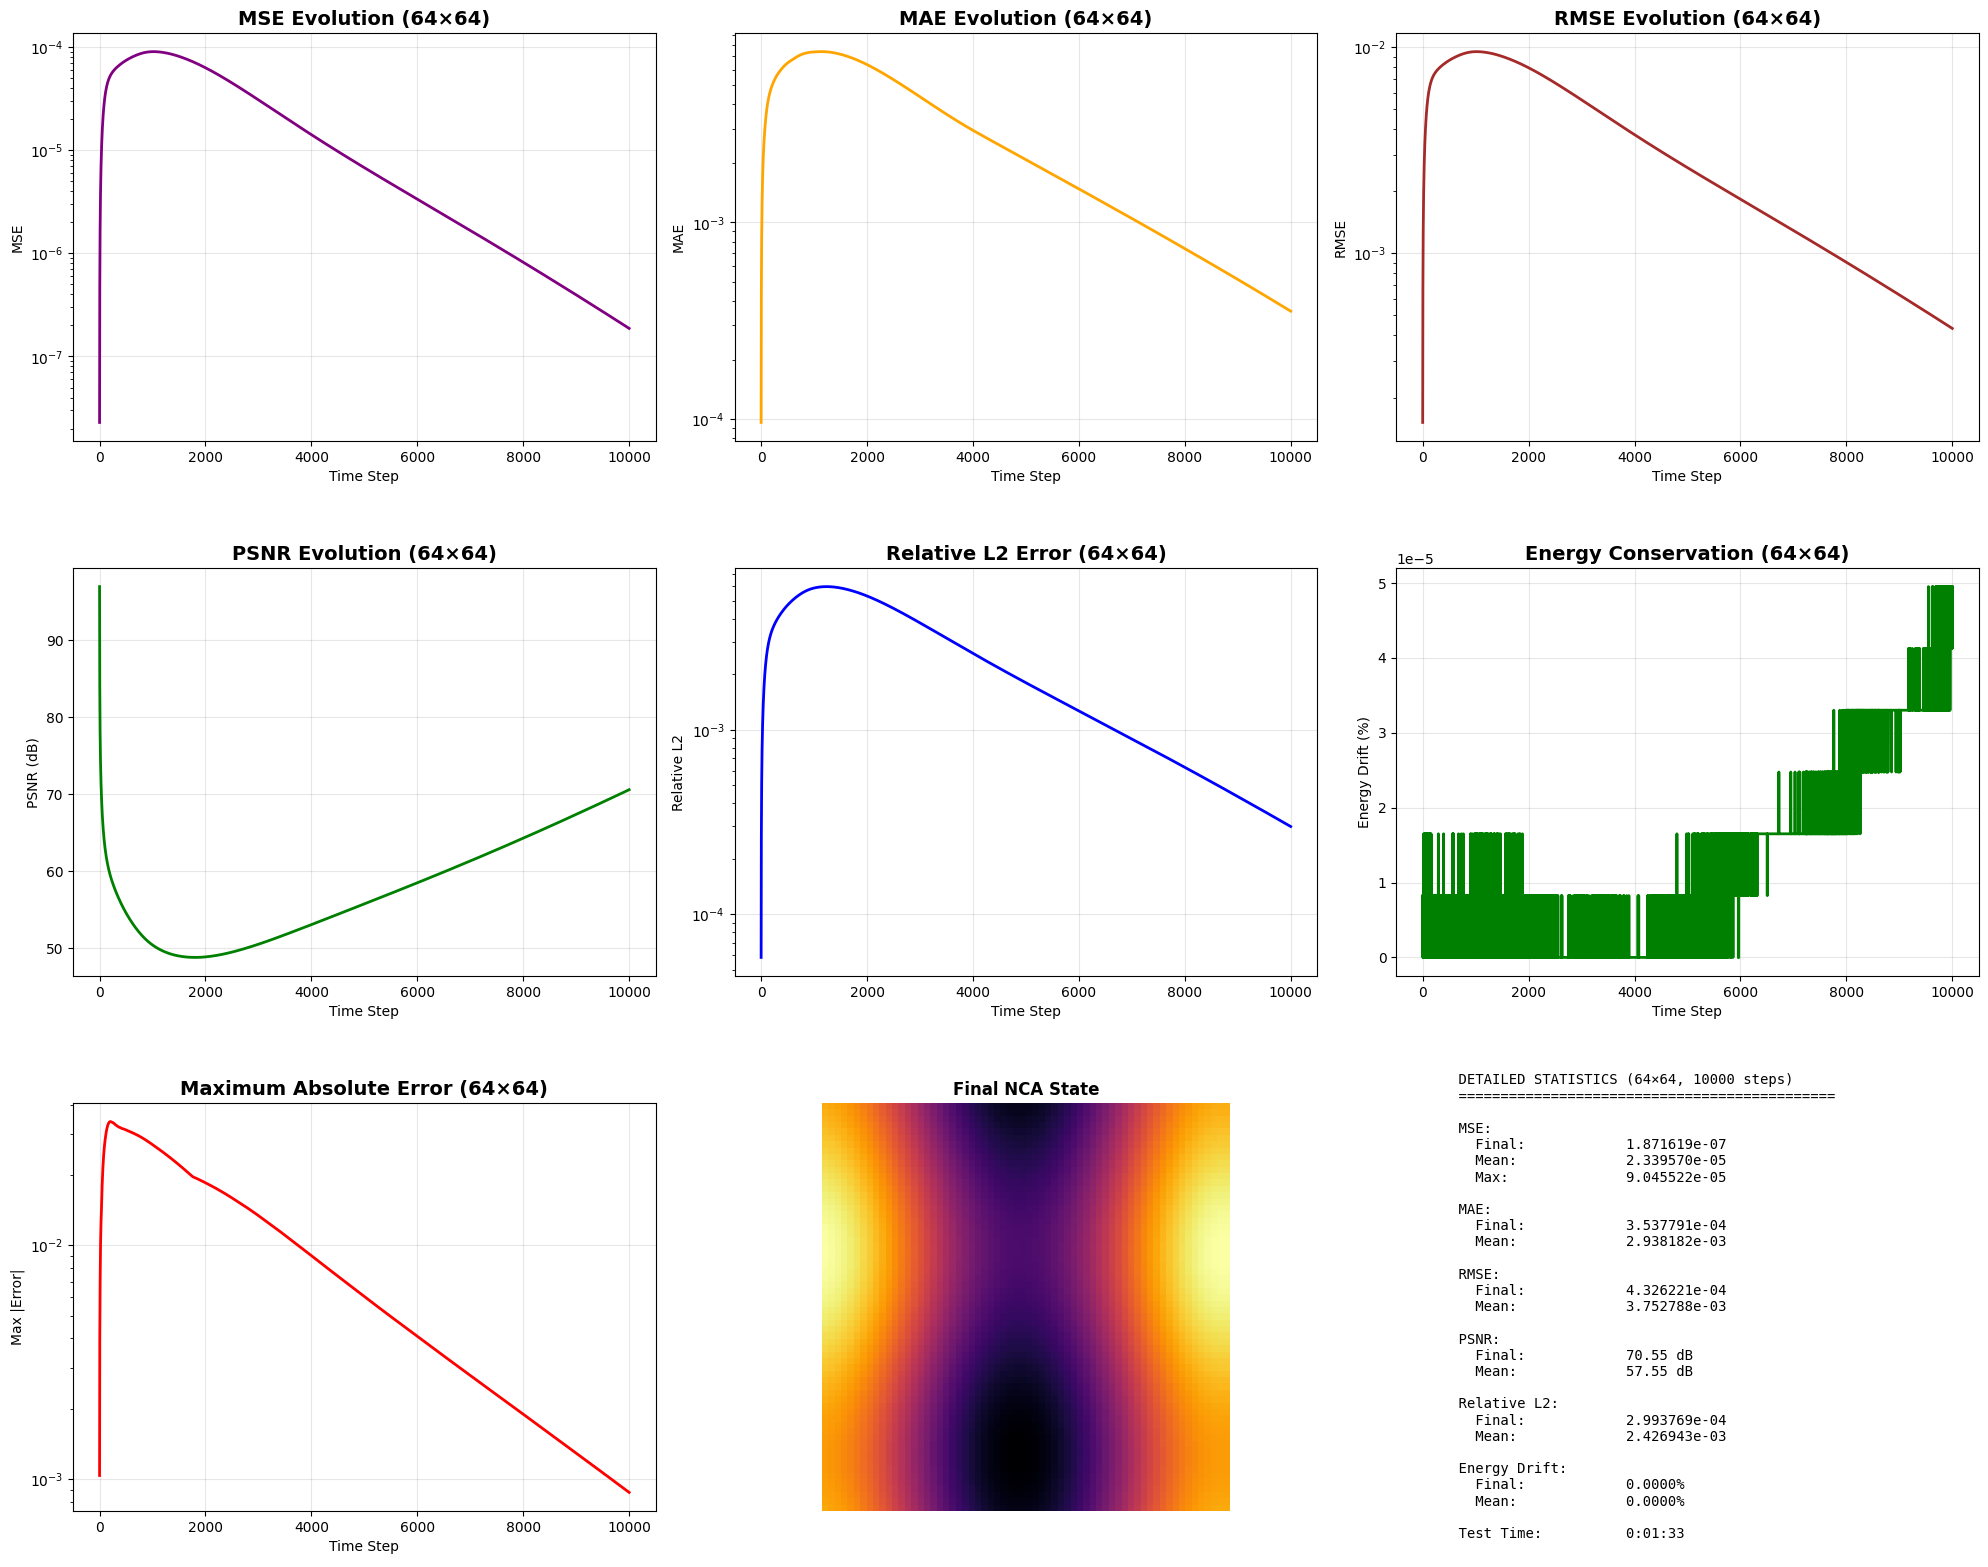


TEST 3: Generalization to Larger Scale (Short): 128×128 for 2000 steps
  Step 100/2000: MSE=5.64e-06, MAE=1.42e-03, PSNR=71.64 dB
  Step 200/2000: MSE=1.74e-05, MAE=2.52e-03, PSNR=66.04 dB
  Step 300/2000: MSE=3.19e-05, MAE=3.46e-03, PSNR=62.77 dB
  Step 400/2000: MSE=4.72e-05, MAE=4.27e-03, PSNR=60.46 dB
  Step 500/2000: MSE=6.25e-05, MAE=4.98e-03, PSNR=58.70 dB
  Step 600/2000: MSE=7.72e-05, MAE=5.60e-03, PSNR=57.29 dB
  Step 700/2000: MSE=9.11e-05, MAE=6.16e-03, PSNR=56.11 dB
  Step 800/2000: MSE=1.04e-04, MAE=6.67e-03, PSNR=55.10 dB
  Step 900/2000: MSE=1.16e-04, MAE=7.13e-03, PSNR=54.22 dB
  Step 1000/2000: MSE=1.28e-04, MAE=7.55e-03, PSNR=53.45 dB
  Step 1100/2000: MSE=1.39e-04, MAE=7.93e-03, PSNR=52.75 dB
  Step 1200/2000: MSE=1.49e-04, MAE=8.28e-03, PSNR=52.14 dB
  Step 1300/2000: MSE=1.58e-04, MAE=8.60e-03, PSNR=51.58 dB
  Step 1400/2000: MSE=1.67e-04, MAE=8.89e-03, PSNR=51.07 dB
  Step 1500/2000: MSE=1.76e-04, MAE=9.17e-03, PSNR=50.60 dB
  Step 1600/2000: MSE=1.84e-04, MAE=9

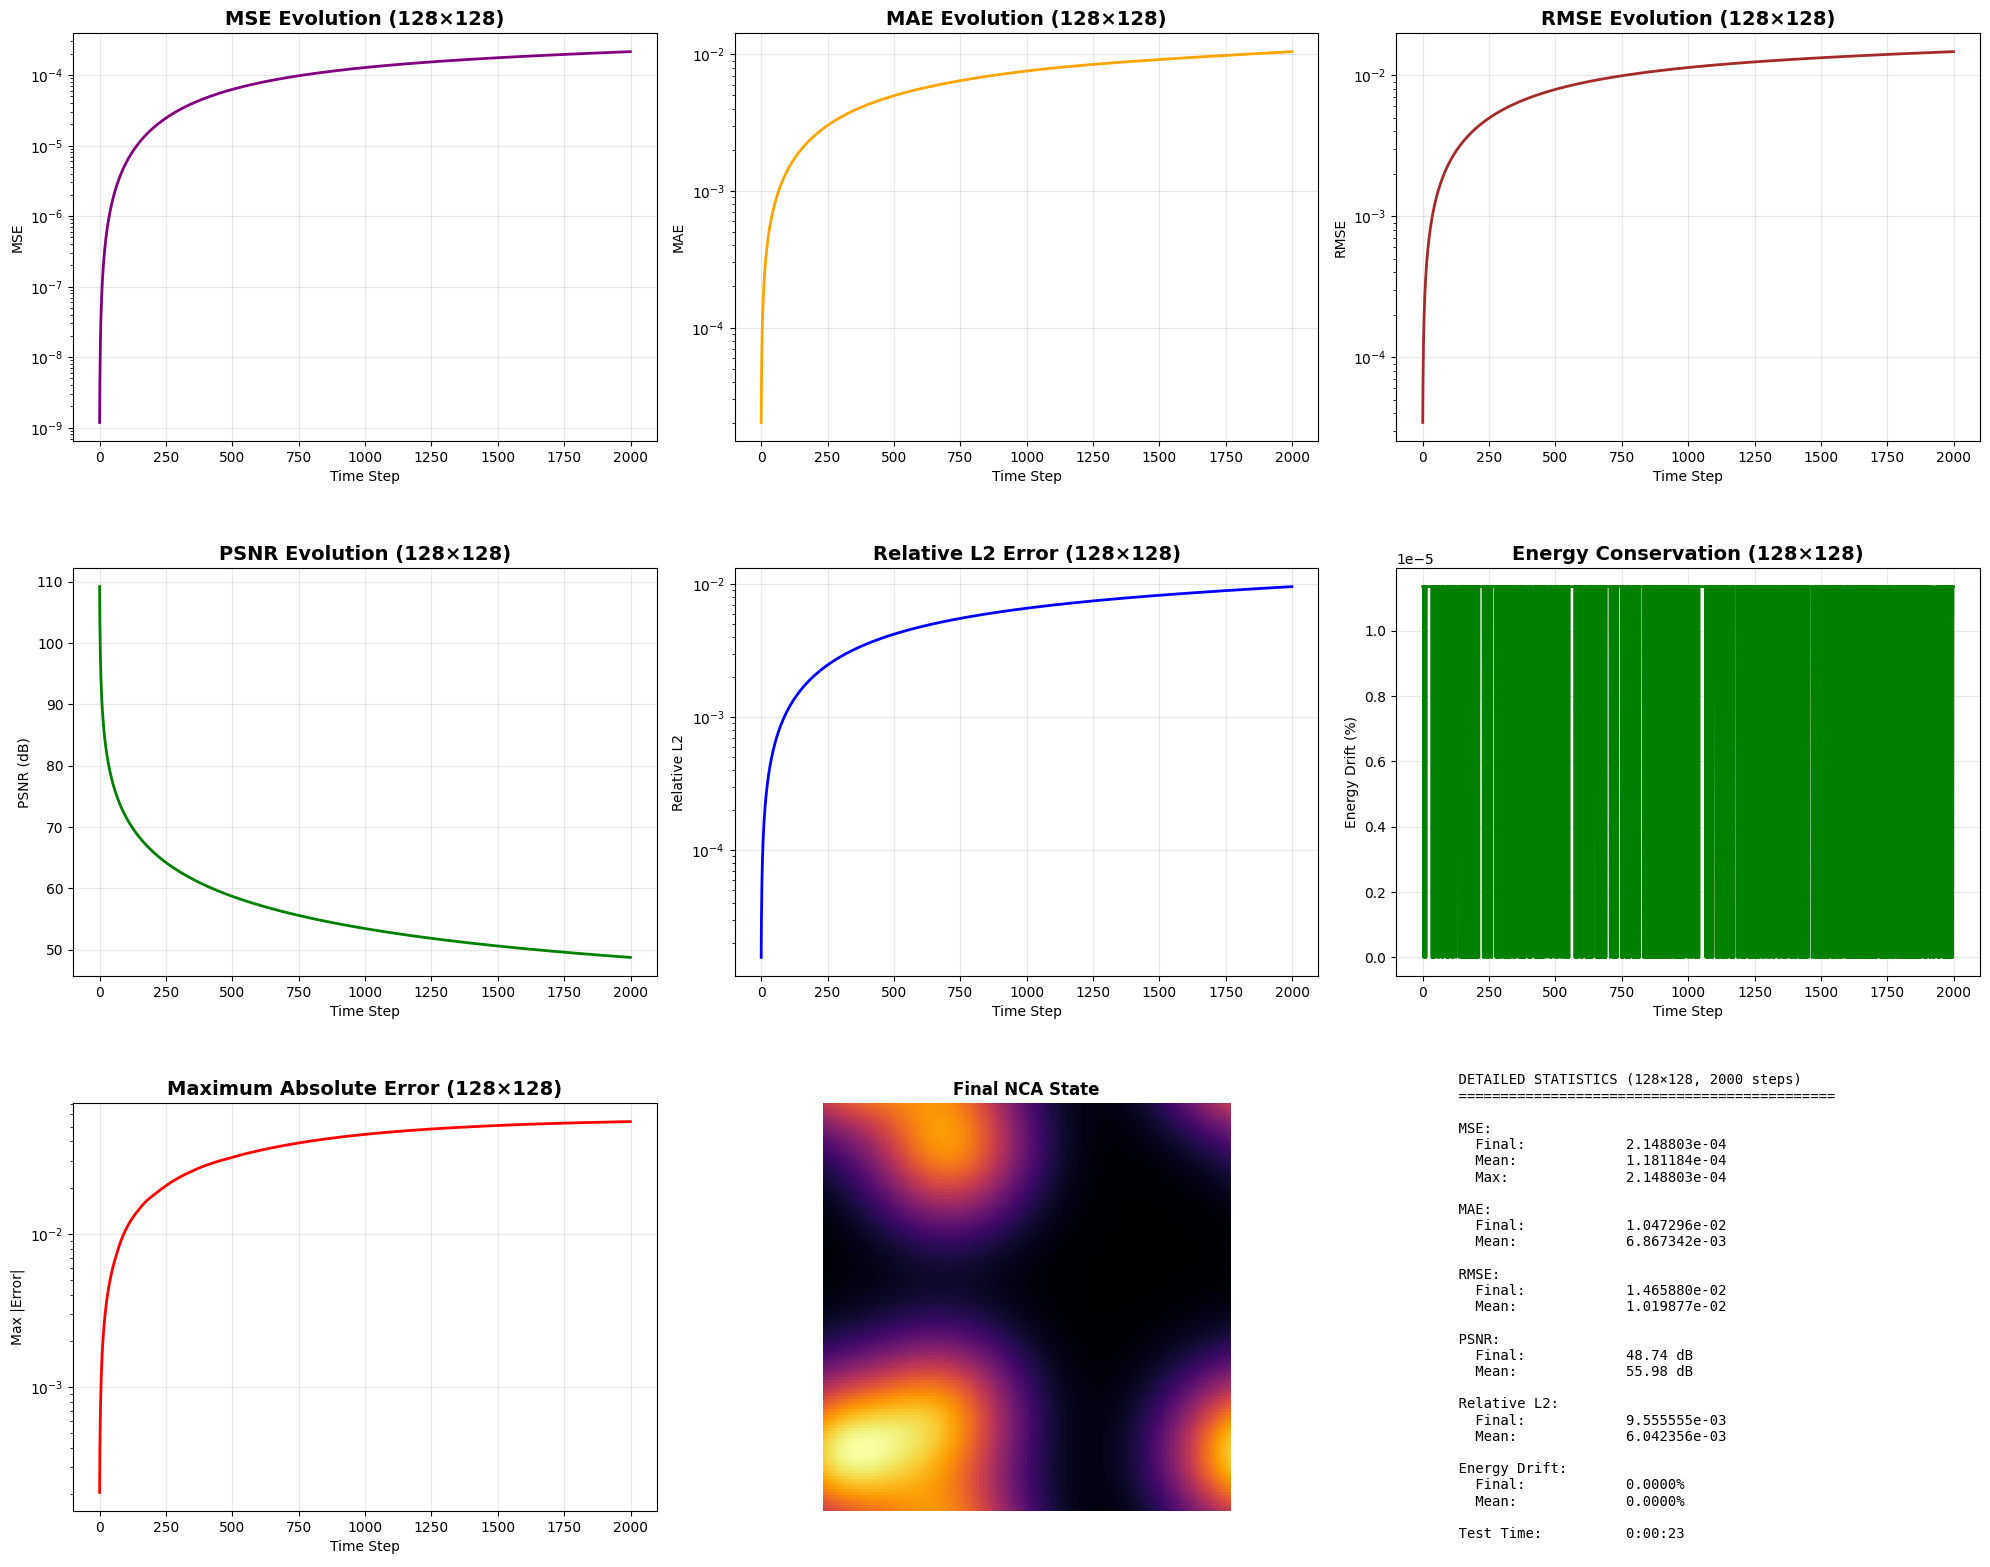


TEST 4: Generalization to Larger Scale (Long): 128×128 for 10000 steps
  Step 100/10000: MSE=4.43e-06, MAE=1.32e-03, PSNR=72.71 dB
  Step 200/10000: MSE=1.29e-05, MAE=2.29e-03, PSNR=67.35 dB
  Step 300/10000: MSE=2.28e-05, MAE=3.09e-03, PSNR=64.22 dB
  Step 400/10000: MSE=3.31e-05, MAE=3.78e-03, PSNR=62.01 dB
  Step 500/10000: MSE=4.30e-05, MAE=4.37e-03, PSNR=60.31 dB
  Step 600/10000: MSE=5.24e-05, MAE=4.91e-03, PSNR=58.95 dB
  Step 700/10000: MSE=6.10e-05, MAE=5.41e-03, PSNR=57.81 dB
  Step 800/10000: MSE=6.90e-05, MAE=5.86e-03, PSNR=56.84 dB
  Step 900/10000: MSE=7.65e-05, MAE=6.27e-03, PSNR=55.98 dB
  Step 1000/10000: MSE=8.36e-05, MAE=6.65e-03, PSNR=55.21 dB
  Step 1100/10000: MSE=9.03e-05, MAE=7.00e-03, PSNR=54.51 dB
  Step 1200/10000: MSE=9.66e-05, MAE=7.31e-03, PSNR=53.88 dB
  Step 1300/10000: MSE=1.03e-04, MAE=7.60e-03, PSNR=53.31 dB
  Step 1400/10000: MSE=1.08e-04, MAE=7.87e-03, PSNR=52.78 dB
  Step 1500/10000: MSE=1.14e-04, MAE=8.11e-03, PSNR=52.29 dB
  Step 1600/10000: MSE

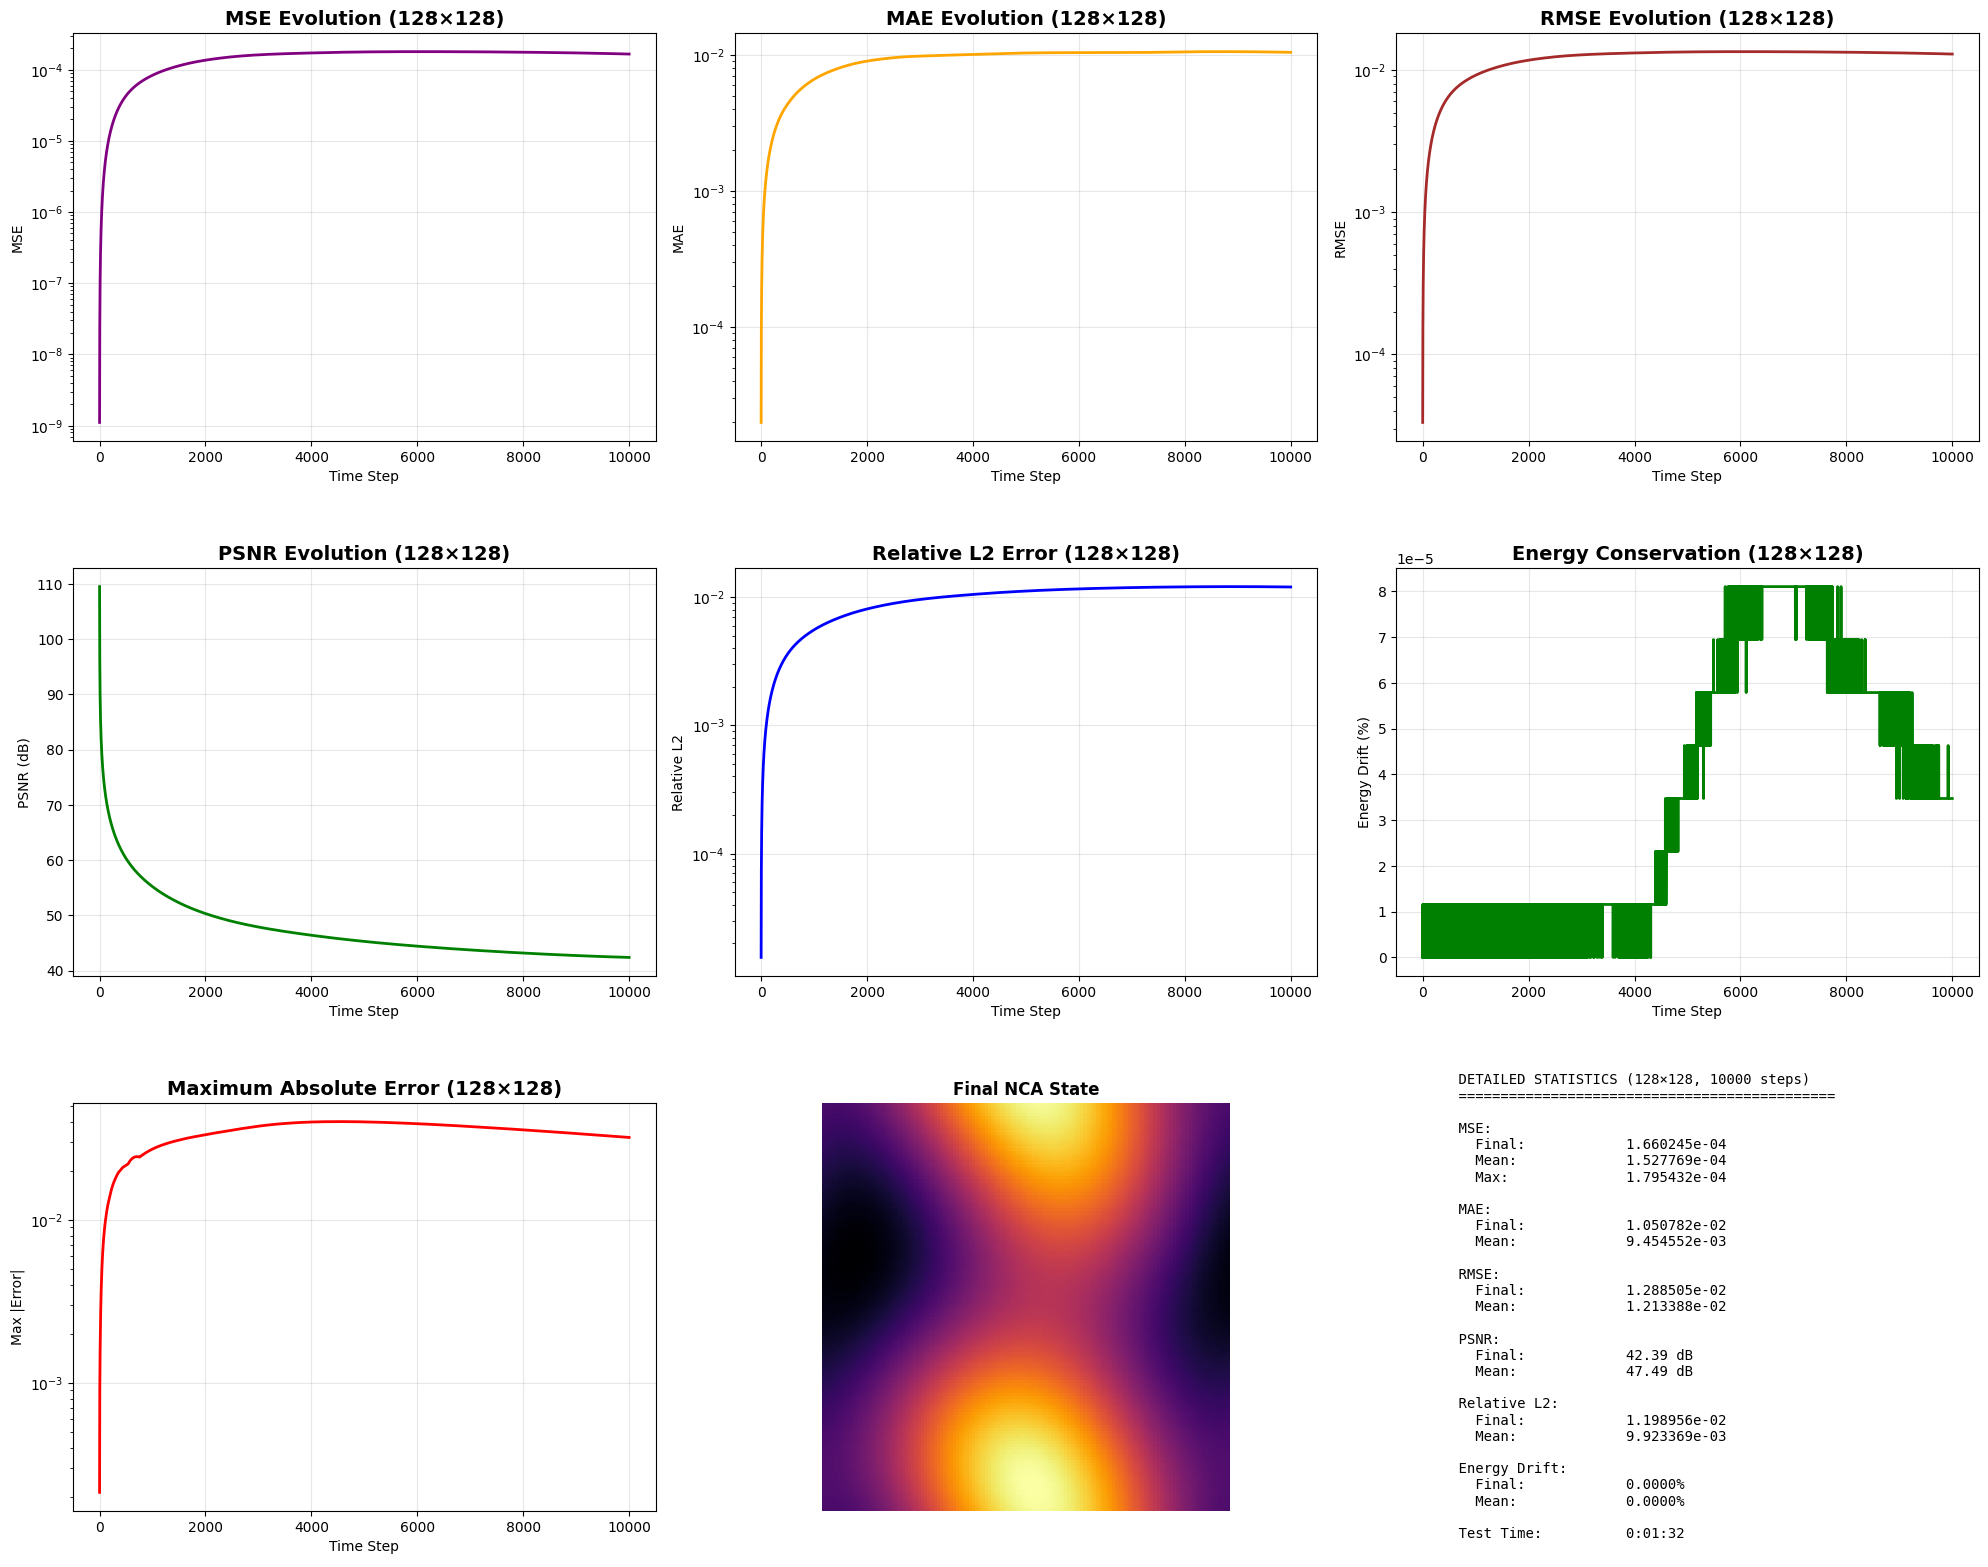


MEMORY & PERFORMANCE - After All Tests
RAM Usage:      3.87 GB (Current: 4.39 GB)
VRAM Usage:     0.00 GB (Current: 0.00 GB)
VRAM Peak:      2.40 GB
Elapsed Time:   0:20:42


GENERATING CROSS-SCALE COMPARISON
✓ Cross-scale comparison saved: cross_scale_comparison.png


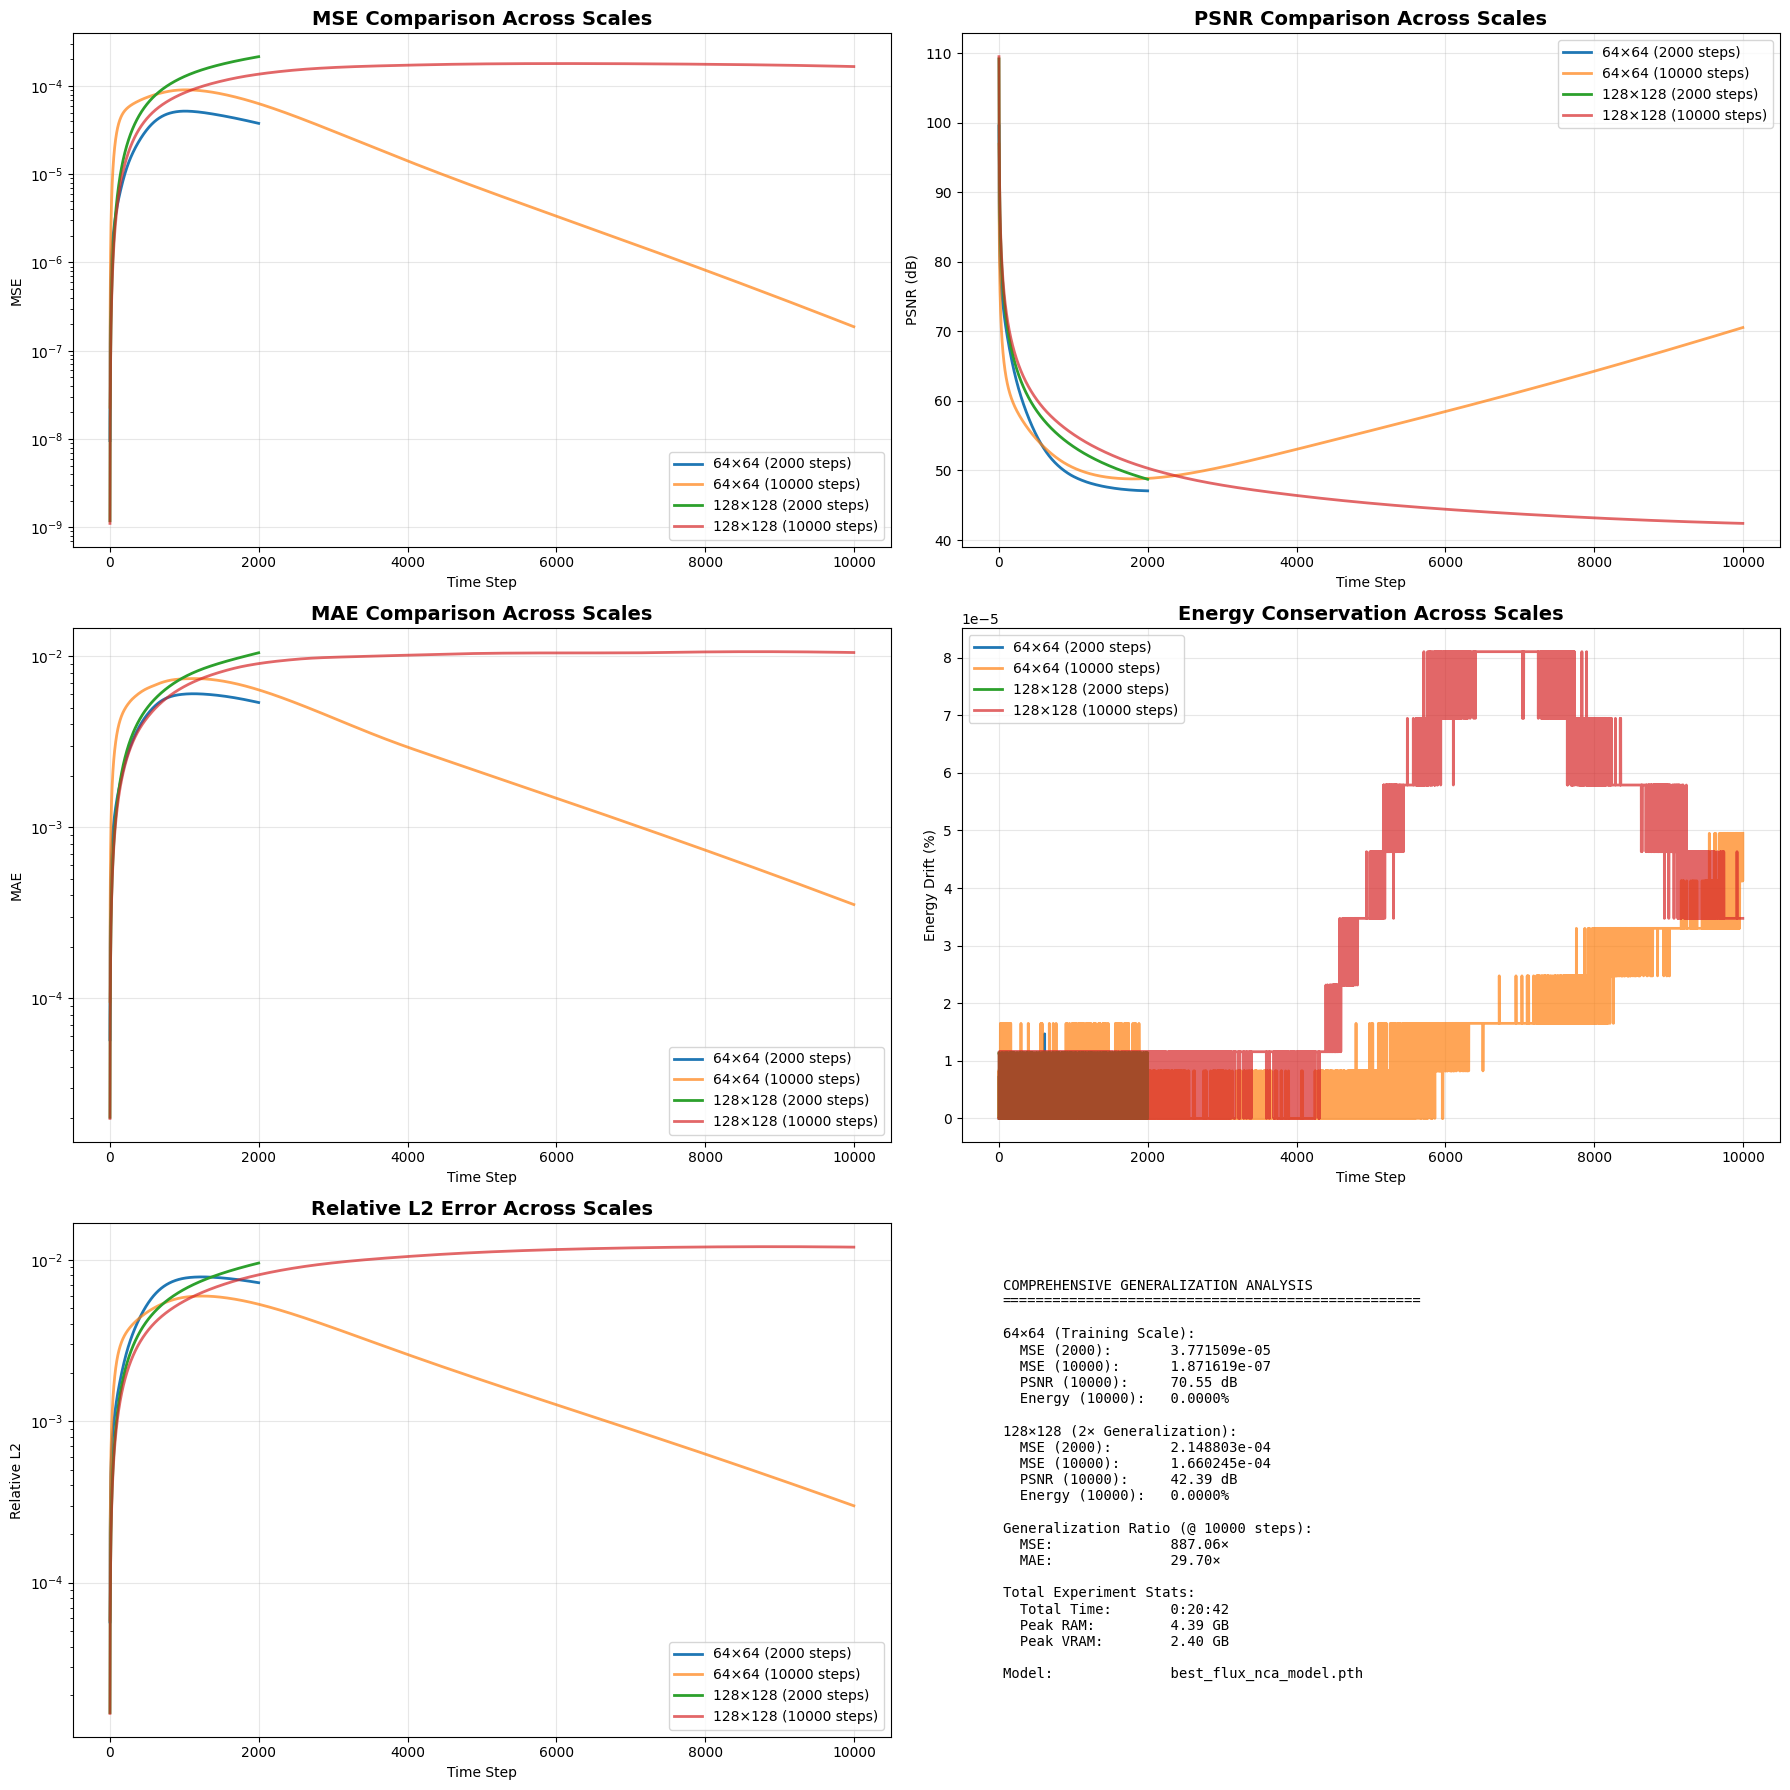


ALL TESTS COMPLETE!

Generated files:
  • training_metrics.png - Full training curves (MSE, MAE, RMSE, PSNR, Rel L2)
  • best_flux_nca_model.pth - Best model weights
  • 64x64_short_comparison.gif
  • 64x64_long_comparison.mp4
  • 128x128_short_comparison.gif
  • 128x128_long_comparison.mp4
  • Individual detailed metrics plots for each test
  • cross_scale_comparison.png - Multi-scale performance analysis

MEMORY & PERFORMANCE - FINAL
RAM Usage:      4.01 GB (Current: 4.52 GB)
VRAM Usage:     0.00 GB (Current: 0.00 GB)
VRAM Peak:      2.40 GB
Elapsed Time:   0:20:46



In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import imageio
from IPython.display import Image, display
import cv2
from pathlib import Path
import psutil
import time
from datetime import timedelta

# 1. Determinism & Device
torch.manual_seed(42)
np.random.seed(42)
torch.backends.cudnn.benchmark = True
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ==========================================
# NEW: Memory & Performance Tracker
# ==========================================
class PerformanceMonitor:
    def __init__(self):
        self.start_time = time.time()
        self.process = psutil.Process()
        self.initial_ram = self.process.memory_info().rss / 1024**3  # GB
        if torch.cuda.is_available():
            torch.cuda.reset_peak_memory_stats()
            self.initial_vram = torch.cuda.memory_allocated() / 1024**3
        else:
            self.initial_vram = 0

    def get_stats(self):
        current_ram = self.process.memory_info().rss / 1024**3
        ram_used = current_ram - self.initial_ram

        if torch.cuda.is_available():
            current_vram = torch.cuda.memory_allocated() / 1024**3
            peak_vram = torch.cuda.max_memory_allocated() / 1024**3
            vram_used = current_vram - self.initial_vram
        else:
            current_vram = peak_vram = vram_used = 0

        elapsed = time.time() - self.start_time

        return {
            'ram_used_gb': ram_used,
            'ram_current_gb': current_ram,
            'vram_used_gb': vram_used,
            'vram_current_gb': current_vram,
            'vram_peak_gb': peak_vram,
            'elapsed_time': elapsed,
            'elapsed_str': str(timedelta(seconds=int(elapsed)))
        }

    def print_stats(self, stage=""):
        stats = self.get_stats()
        print(f"\n{'='*70}")
        print(f"MEMORY & PERFORMANCE - {stage}")
        print(f"{'='*70}")
        print(f"RAM Usage:      {stats['ram_used_gb']:.2f} GB (Current: {stats['ram_current_gb']:.2f} GB)")
        if torch.cuda.is_available():
            print(f"VRAM Usage:     {stats['vram_used_gb']:.2f} GB (Current: {stats['vram_current_gb']:.2f} GB)")
            print(f"VRAM Peak:      {stats['vram_peak_gb']:.2f} GB")
        print(f"Elapsed Time:   {stats['elapsed_str']}")
        print(f"{'='*70}\n")

# Initialize monitor
perf_monitor = PerformanceMonitor()

# ==========================================
# 2. Enhanced Configuration
# ==========================================
CONFIG = {
    'train_size': 64,
    'test_size': 128,
    'batch_size': 8,
    'epochs': 5000,
    'lr': 0.001,
    'weight_decay': 1e-4,
    'alpha': 0.5,
    'dt': 0.1,
    'min_steps': 40,
    'max_steps': 150,
    'val_freq': 500,

    # Testing parameters
    'short_test_steps': 2000,
    'long_test_steps': 10000,
    'video_fps': 30,
    'frame_interval': 20,

    # NEW: Visualization options
    'use_relative_error': True,  # Use relative error normalization
    'save_best_weights': True,   # Save best model weights
    'weights_path': 'best_flux_nca_model.pth',
}

# ==========================================
# NEW: Enhanced Metrics Calculator
# ==========================================
def calculate_metrics(pred, target):
    """
    Calculate comprehensive metrics between prediction and target
    """
    mse = torch.mean((pred - target)**2).item()
    mae = torch.mean(torch.abs(pred - target)).item()

    # RMSE
    rmse = np.sqrt(mse)

    # PSNR (Peak Signal-to-Noise Ratio)
    max_val = torch.max(target).item()
    if mse > 0:
        psnr = 20 * np.log10(max_val / np.sqrt(mse))
    else:
        psnr = float('inf')

    # Relative L2 error
    rel_l2 = torch.norm(pred - target) / torch.norm(target)
    rel_l2 = rel_l2.item()

    # Max absolute error
    max_abs_error = torch.max(torch.abs(pred - target)).item()

    return {
        'mse': mse,
        'mae': mae,
        'rmse': rmse,
        'psnr': psnr,
        'rel_l2': rel_l2,
        'max_abs_error': max_abs_error
    }

# ==========================================
# 3. Analytical Teacher (EXACT ORIGINAL)
# ==========================================
class HeatEquationSolver:
    def __init__(self, alpha, dt):
        self.alpha = alpha
        self.dt = dt
        self.kernel = torch.tensor([[0, 1, 0], [1, -4, 1], [0, 1, 0]],
                                   dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)

    def step(self, grid):
        padded = torch.nn.functional.pad(grid, (1, 1, 1, 1), mode='circular')
        laplacian = torch.nn.functional.conv2d(padded, self.kernel)
        return grid + self.alpha * laplacian * self.dt

# ==========================================
# 4. Deep Flux-NCA (EXACT ORIGINAL)
# ==========================================
class DeepFluxNCA(nn.Module):
    def __init__(self):
        super().__init__()
        self.perceive = nn.Conv2d(1, 32, 3, padding=1, padding_mode='circular')
        self.process = nn.Sequential(
            nn.ReLU(),
            nn.Conv2d(32, 64, 1),
            nn.ReLU(),
            nn.Conv2d(64, 32, 1),
            nn.ReLU(),
            nn.Conv2d(32, 2, 1, bias=False)
        )
        with torch.no_grad():
            self.process[-1].weight.data.fill_(0.0)
            nn.init.kaiming_normal_(self.perceive.weight, nonlinearity='relu')
            nn.init.kaiming_normal_(self.process[1].weight, nonlinearity='relu')
            nn.init.kaiming_normal_(self.process[3].weight, nonlinearity='relu')

    def forward(self, x):
        flux = self.process(self.perceive(x))
        flux_x, flux_y = flux[:, 0:1], flux[:, 1:2]
        dx = (torch.roll(flux_x, 1, 3) - flux_x) + (torch.roll(flux_y, 1, 2) - flux_y)
        return x + dx

# ==========================================
# 5. Generator (EXACT ORIGINAL)
# ==========================================
def make_state(batch_size, size):
    grid = torch.zeros(batch_size, 1, size, size).to(device)
    x = torch.arange(0, size).float().to(device)
    y = torch.arange(0, size).float().to(device)
    yy, xx = torch.meshgrid(y, x, indexing='ij')

    for i in range(batch_size):
        for _ in range(np.random.randint(3, 6)):
            cx, cy = np.random.randint(0, size, 2)
            sigma = size * 0.08
            amp = np.random.uniform(5.0, 10.0)
            dx = torch.abs(xx - cx); dx = torch.min(dx, size - dx)
            dy = torch.abs(yy - cy); dy = torch.min(dy, size - dy)
            grid[i, 0] += amp * torch.exp(-(dx**2 + dy**2) / (2 * sigma**2))
    return grid

# ==========================================
# 6. Enhanced Training Loop with Full Metrics
# ==========================================
print("=" * 70)
print("TRAINING DEEP FLUX NCA ON 64×64 GRIDS")
print("=" * 70)

model = DeepFluxNCA().to(device)
solver = HeatEquationSolver(CONFIG['alpha'], CONFIG['dt'])
optimizer = optim.Adam(model.parameters(), lr=CONFIG['lr'], weight_decay=CONFIG['weight_decay'])
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=200)
loss_fn = nn.MSELoss()

# Enhanced tracking
train_metrics = {
    'mse': [], 'mae': [], 'rmse': [], 'psnr': [], 'rel_l2': []
}
val_metrics = {
    'epoch': [], 'mse': [], 'mae': [], 'rmse': [], 'psnr': [], 'rel_l2': []
}

best_loss = float('inf')
best_weights = None
best_epoch = 0

perf_monitor.print_stats("Before Training")

for i in range(CONFIG['epochs']):
    model.train()
    state = make_state(CONFIG['batch_size'], CONFIG['train_size'])
    state = state + torch.randn_like(state) * 0.02

    target = state.clone()
    pred = state.clone()
    current_steps = np.random.randint(CONFIG['min_steps'], CONFIG['max_steps'])

    seq_loss = 0
    for _ in range(current_steps):
        with torch.no_grad():
            target = solver.step(target)
        pred = model(pred)
        seq_loss += loss_fn(pred, target)

    loss_val = seq_loss / current_steps
    optimizer.zero_grad()
    loss_val.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5)
    optimizer.step()
    scheduler.step(loss_val)

    # Calculate training metrics
    with torch.no_grad():
        metrics = calculate_metrics(pred, target)
        train_metrics['mse'].append(metrics['mse'])
        train_metrics['mae'].append(metrics['mae'])
        train_metrics['rmse'].append(metrics['rmse'])
        train_metrics['psnr'].append(metrics['psnr'])
        train_metrics['rel_l2'].append(metrics['rel_l2'])

    # Validation
    if i % CONFIG['val_freq'] == 0:
        model.eval()
        with torch.no_grad():
            v_state = make_state(CONFIG['batch_size'], CONFIG['train_size'])
            v_target, v_pred = v_state.clone(), v_state.clone()
            for _ in range(20):
                v_target = solver.step(v_target)
                v_pred = model(v_pred)

            v_metrics = calculate_metrics(v_pred, v_target)
            val_metrics['epoch'].append(i)
            val_metrics['mse'].append(v_metrics['mse'])
            val_metrics['mae'].append(v_metrics['mae'])
            val_metrics['rmse'].append(v_metrics['rmse'])
            val_metrics['psnr'].append(v_metrics['psnr'])
            val_metrics['rel_l2'].append(v_metrics['rel_l2'])

            print(f"Epoch {i:4d}: Train Loss {loss_val.item():.7f} | Val MSE {v_metrics['mse']:.7f} | "
                  f"Val MAE {v_metrics['mae']:.7f} | Val PSNR {v_metrics['psnr']:.2f} dB")

    # Save best weights
    if loss_val.item() < best_loss:
        best_loss = loss_val.item()
        best_epoch = i
        if CONFIG['save_best_weights']:
            best_weights = {
                'epoch': i,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'loss': best_loss,
                'config': CONFIG
            }

# Save best model
if CONFIG['save_best_weights'] and best_weights is not None:
    torch.save(best_weights, CONFIG['weights_path'])
    print(f"\n✓ Best model weights saved to {CONFIG['weights_path']}")
    print(f"  Best epoch: {best_epoch}, Best loss: {best_loss:.7f}")

# Load best weights for testing
if best_weights is not None:
    model.load_state_dict(best_weights['model_state_dict'])
    print(f"✓ Loaded best weights from epoch {best_epoch}")

perf_monitor.print_stats("After Training")

# ==========================================
# NEW: Plot Training Metrics
# ==========================================
print("\n" + "="*70)
print("GENERATING TRAINING METRICS PLOTS")
print("="*70)

fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# Smooth training curves
def smooth(data, window=50):
    return np.convolve(data, np.ones(window)/window, mode='valid')

# MSE
axes[0, 0].plot(train_metrics['mse'], alpha=0.2, color='blue', linewidth=0.5)
axes[0, 0].plot(smooth(train_metrics['mse']), color='blue', linewidth=2, label='Train (smoothed)')
if val_metrics['epoch']:
    axes[0, 0].plot(val_metrics['epoch'], val_metrics['mse'], 'o-', color='red',
                    markersize=4, linewidth=2, label='Validation')
axes[0, 0].axvline(best_epoch, color='green', linestyle='--', alpha=0.7, label=f'Best ({best_epoch})')
axes[0, 0].set_yscale('log')
axes[0, 0].set_title('Mean Squared Error (MSE)', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('MSE')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# MAE
axes[0, 1].plot(train_metrics['mae'], alpha=0.2, color='orange', linewidth=0.5)
axes[0, 1].plot(smooth(train_metrics['mae']), color='orange', linewidth=2, label='Train (smoothed)')
if val_metrics['epoch']:
    axes[0, 1].plot(val_metrics['epoch'], val_metrics['mae'], 'o-', color='red',
                    markersize=4, linewidth=2, label='Validation')
axes[0, 1].axvline(best_epoch, color='green', linestyle='--', alpha=0.7)
axes[0, 1].set_yscale('log')
axes[0, 1].set_title('Mean Absolute Error (MAE)', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('MAE')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# RMSE
axes[0, 2].plot(train_metrics['rmse'], alpha=0.2, color='purple', linewidth=0.5)
axes[0, 2].plot(smooth(train_metrics['rmse']), color='purple', linewidth=2, label='Train (smoothed)')
if val_metrics['epoch']:
    axes[0, 2].plot(val_metrics['epoch'], val_metrics['rmse'], 'o-', color='red',
                    markersize=4, linewidth=2, label='Validation')
axes[0, 2].axvline(best_epoch, color='green', linestyle='--', alpha=0.7)
axes[0, 2].set_yscale('log')
axes[0, 2].set_title('Root Mean Squared Error (RMSE)', fontsize=14, fontweight='bold')
axes[0, 2].set_xlabel('Epoch')
axes[0, 2].set_ylabel('RMSE')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# PSNR
psnr_filtered = [p for p in train_metrics['psnr'] if p != float('inf')]
axes[1, 0].plot(psnr_filtered, alpha=0.2, color='green', linewidth=0.5)
axes[1, 0].plot(smooth(psnr_filtered), color='green', linewidth=2, label='Train (smoothed)')
if val_metrics['epoch']:
    axes[1, 0].plot(val_metrics['epoch'], val_metrics['psnr'], 'o-', color='red',
                    markersize=4, linewidth=2, label='Validation')
axes[1, 0].axvline(best_epoch, color='green', linestyle='--', alpha=0.7)
axes[1, 0].set_title('Peak Signal-to-Noise Ratio (PSNR)', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('PSNR (dB)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Relative L2 Error
axes[1, 1].plot(train_metrics['rel_l2'], alpha=0.2, color='brown', linewidth=0.5)
axes[1, 1].plot(smooth(train_metrics['rel_l2']), color='brown', linewidth=2, label='Train (smoothed)')
if val_metrics['epoch']:
    axes[1, 1].plot(val_metrics['epoch'], val_metrics['rel_l2'], 'o-', color='red',
                    markersize=4, linewidth=2, label='Validation')
axes[1, 1].axvline(best_epoch, color='green', linestyle='--', alpha=0.7)
axes[1, 1].set_yscale('log')
axes[1, 1].set_title('Relative L2 Error', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Relative L2')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# Training Summary
axes[1, 2].axis('off')
final_stats = perf_monitor.get_stats()
summary_text = f"""
TRAINING SUMMARY
{'='*45}

Best Epoch:         {best_epoch}
Best Loss:          {best_loss:.6e}

Final Metrics:
  MSE:              {train_metrics['mse'][-1]:.6e}
  MAE:              {train_metrics['mae'][-1]:.6e}
  RMSE:             {train_metrics['rmse'][-1]:.6e}
  PSNR:             {train_metrics['psnr'][-1]:.2f} dB
  Rel L2:           {train_metrics['rel_l2'][-1]:.6e}

Memory Usage:
  RAM:              {final_stats['ram_used_gb']:.2f} GB
  VRAM:             {final_stats['vram_used_gb']:.2f} GB
  VRAM Peak:        {final_stats['vram_peak_gb']:.2f} GB

Training Time:      {final_stats['elapsed_str']}
"""
axes[1, 2].text(0.1, 0.5, summary_text, fontsize=11, family='monospace',
                verticalalignment='center')

plt.tight_layout()
plt.savefig('training_metrics.png', dpi=150, bbox_inches='tight')
print("✓ Training metrics saved: training_metrics.png")
plt.show()

# ==========================================
# 7. Enhanced Multi-Scale Testing Function
# ==========================================
def run_comparison(model, solver, size, steps, title_prefix, save_prefix):
    """
    Run comparative simulation with enhanced metrics and relative error visualization
    """
    print(f"\n{'='*70}")
    print(f"{title_prefix}: {size}×{size} for {steps} steps")
    print(f"{'='*70}")

    test_start_time = time.time()

    init_state = make_state(1, size)
    curr_t = init_state.clone()
    curr_m = init_state.clone()

    frames = []
    all_metrics = {
        'mse': [], 'mae': [], 'rmse': [], 'psnr': [], 'rel_l2': [], 'max_abs_error': []
    }
    energy_pct_error = []
    start_E = torch.sum(init_state).item()
    max_v = torch.max(init_state).item()

    use_video = steps > 1000
    frame_interval = CONFIG['frame_interval']

    for t in range(steps):
        with torch.no_grad():
            curr_t = solver.step(curr_t)
            curr_m = model(curr_m)

        # Calculate all metrics
        metrics = calculate_metrics(curr_m, curr_t)
        for key in all_metrics:
            all_metrics[key].append(metrics[key])

        model_energy = torch.sum(curr_m).item()
        energy_pct_error.append(abs(model_energy - start_E) / start_E * 100.0)

        # Capture frames
        if t % frame_interval == 0:
            fig, ax = plt.subplots(1, 3, figsize=(18, 5))

            ax[0].imshow(curr_t.cpu().squeeze().numpy(), cmap='inferno', vmin=0, vmax=max_v)
            ax[0].set_title(f"Analytical Solution (t={t})", fontsize=14, fontweight='bold')
            ax[0].axis('off')

            ax[1].imshow(curr_m.cpu().squeeze().numpy(), cmap='inferno', vmin=0, vmax=max_v)
            ax[1].set_title(f"Flux-NCA Prediction (t={t})", fontsize=14, fontweight='bold')
            ax[1].axis('off')

            # Enhanced error visualization with relative normalization
            diff = torch.abs(curr_t - curr_m).cpu().squeeze().numpy()

            if CONFIG['use_relative_error']:
                # Normalize error relative to the current solution magnitude
                max_solution = torch.max(torch.abs(curr_t)).item()
                if max_solution > 1e-10:
                    diff_normalized = diff / max_solution
                    im = ax[2].imshow(diff_normalized, cmap='viridis', vmin=0, vmax=0.01)  # 0-1% range
                    cbar = plt.colorbar(im, ax=ax[2], fraction=0.046, pad=0.04)
                    cbar.set_label('Relative Error', fontsize=10)
                    ax[2].set_title(f"Relative Error (×10⁻²)\nMSE: {metrics['mse']:.2e}",
                                   fontsize=14, fontweight='bold')
                else:
                    im = ax[2].imshow(diff, cmap='viridis')
                    plt.colorbar(im, ax=ax[2], fraction=0.046, pad=0.04)
                    ax[2].set_title(f"Absolute Error\nMSE: {metrics['mse']:.2e}",
                                   fontsize=14, fontweight='bold')
            else:
                im = ax[2].imshow(diff, cmap='viridis', vmin=0, vmax=max_v*0.15)
                plt.colorbar(im, ax=ax[2], fraction=0.046, pad=0.04)
                ax[2].set_title(f"Absolute Error\nMSE: {metrics['mse']:.6f}",
                               fontsize=14, fontweight='bold')

            ax[2].axis('off')
            plt.tight_layout()

            fig.canvas.draw()
            frame = np.asarray(fig.canvas.buffer_rgba())[:, :, :3]
            frames.append(frame)
            plt.close()

        if (t + 1) % 100 == 0:
            print(f"  Step {t+1}/{steps}: MSE={metrics['mse']:.2e}, MAE={metrics['mae']:.2e}, "
                  f"PSNR={metrics['psnr']:.2f} dB")

    # Save as video or GIF
    output_path = f'{save_prefix}_comparison.{"mp4" if use_video else "gif"}'
    if use_video:
        height, width = frames[0].shape[:2]
        fourcc = cv2.VideoWriter_fourcc(*'mp4v')
        out = cv2.VideoWriter(output_path, fourcc, CONFIG['video_fps'], (width, height))
        for frame in frames:
            out.write(cv2.cvtColor(frame, cv2.COLOR_RGB2BGR))
        out.release()
        print(f"\n✓ Video saved: {output_path}")
    else:
        imageio.mimsave(output_path, frames, fps=15)
        print(f"\n✓ GIF saved: {output_path}")

    test_time = time.time() - test_start_time

    # Enhanced metrics plots
    fig, ax = plt.subplots(3, 3, figsize=(20, 16))

    # MSE over time
    ax[0, 0].plot(all_metrics['mse'], color='purple', linewidth=2)
    ax[0, 0].set_title(f'MSE Evolution ({size}×{size})', fontsize=14, fontweight='bold')
    ax[0, 0].set_xlabel('Time Step')
    ax[0, 0].set_ylabel('MSE')
    ax[0, 0].set_yscale('log')
    ax[0, 0].grid(True, alpha=0.3)

    # MAE over time
    ax[0, 1].plot(all_metrics['mae'], color='orange', linewidth=2)
    ax[0, 1].set_title(f'MAE Evolution ({size}×{size})', fontsize=14, fontweight='bold')
    ax[0, 1].set_xlabel('Time Step')
    ax[0, 1].set_ylabel('MAE')
    ax[0, 1].set_yscale('log')
    ax[0, 1].grid(True, alpha=0.3)

    # RMSE over time
    ax[0, 2].plot(all_metrics['rmse'], color='brown', linewidth=2)
    ax[0, 2].set_title(f'RMSE Evolution ({size}×{size})', fontsize=14, fontweight='bold')
    ax[0, 2].set_xlabel('Time Step')
    ax[0, 2].set_ylabel('RMSE')
    ax[0, 2].set_yscale('log')
    ax[0, 2].grid(True, alpha=0.3)

    # PSNR over time
    psnr_filtered = [p for p in all_metrics['psnr'] if p != float('inf')]
    ax[1, 0].plot(psnr_filtered, color='green', linewidth=2)
    ax[1, 0].set_title(f'PSNR Evolution ({size}×{size})', fontsize=14, fontweight='bold')
    ax[1, 0].set_xlabel('Time Step')
    ax[1, 0].set_ylabel('PSNR (dB)')
    ax[1, 0].grid(True, alpha=0.3)

    # Relative L2 Error
    ax[1, 1].plot(all_metrics['rel_l2'], color='blue', linewidth=2)
    ax[1, 1].set_title(f'Relative L2 Error ({size}×{size})', fontsize=14, fontweight='bold')
    ax[1, 1].set_xlabel('Time Step')
    ax[1, 1].set_ylabel('Relative L2')
    ax[1, 1].set_yscale('log')
    ax[1, 1].grid(True, alpha=0.3)

    # Energy conservation
    ax[1, 2].plot(energy_pct_error, color='green', linewidth=2)
    ax[1, 2].set_title(f'Energy Conservation ({size}×{size})', fontsize=14, fontweight='bold')
    ax[1, 2].set_xlabel('Time Step')
    ax[1, 2].set_ylabel('Energy Drift (%)')
    ax[1, 2].grid(True, alpha=0.3)

    # Max absolute error
    ax[2, 0].plot(all_metrics['max_abs_error'], color='red', linewidth=2)
    ax[2, 0].set_title(f'Maximum Absolute Error ({size}×{size})', fontsize=14, fontweight='bold')
    ax[2, 0].set_xlabel('Time Step')
    ax[2, 0].set_ylabel('Max |Error|')
    ax[2, 0].set_yscale('log')
    ax[2, 0].grid(True, alpha=0.3)

    # Final states comparison
    ax[2, 1].imshow(curr_m.cpu().squeeze().numpy(), cmap='inferno')
    ax[2, 1].set_title('Final NCA State', fontsize=12, fontweight='bold')
    ax[2, 1].axis('off')

    # Summary statistics
    ax[2, 2].axis('off')
    summary_text = f"""
    DETAILED STATISTICS ({size}×{size}, {steps} steps)
    {'='*45}

    MSE:
      Final:            {all_metrics['mse'][-1]:.6e}
      Mean:             {np.mean(all_metrics['mse']):.6e}
      Max:              {np.max(all_metrics['mse']):.6e}

    MAE:
      Final:            {all_metrics['mae'][-1]:.6e}
      Mean:             {np.mean(all_metrics['mae']):.6e}

    RMSE:
      Final:            {all_metrics['rmse'][-1]:.6e}
      Mean:             {np.mean(all_metrics['rmse']):.6e}

    PSNR:
      Final:            {all_metrics['psnr'][-1]:.2f} dB
      Mean:             {np.mean(psnr_filtered):.2f} dB

    Relative L2:
      Final:            {all_metrics['rel_l2'][-1]:.6e}
      Mean:             {np.mean(all_metrics['rel_l2']):.6e}

    Energy Drift:
      Final:            {energy_pct_error[-1]:.4f}%
      Mean:             {np.mean(energy_pct_error):.4f}%

    Test Time:          {str(timedelta(seconds=int(test_time)))}
    """
    ax[2, 2].text(0.05, 0.5, summary_text, fontsize=10, family='monospace',
                  verticalalignment='center')

    plt.tight_layout()
    plt.savefig(f'{save_prefix}_metrics.png', dpi=150, bbox_inches='tight')
    print(f"✓ Metrics plot saved: {save_prefix}_metrics.png")
    plt.show()

    return {
        'metrics': all_metrics,
        'energy_error': energy_pct_error,
        'final_analytical': curr_t,
        'final_model': curr_m,
        'test_time': test_time
    }

# ==========================================
# 8. Run All Tests
# ==========================================

perf_monitor.print_stats("Before Testing")

# Test 1: Same size as training (64×64) - Short
results_64_short = run_comparison(
    model, solver,
    size=64,
    steps=CONFIG['short_test_steps'],
    title_prefix="TEST 1: Training Scale (Short)",
    save_prefix="64x64_short"
)

# Test 2: Same size as training (64×64) - Long
results_64_long = run_comparison(
    model, solver,
    size=64,
    steps=CONFIG['long_test_steps'],
    title_prefix="TEST 2: Training Scale (Long)",
    save_prefix="64x64_long"
)

# Test 3: Generalization to larger size (128×128) - Short
results_128_short = run_comparison(
    model, solver,
    size=128,
    steps=CONFIG['short_test_steps'],
    title_prefix="TEST 3: Generalization to Larger Scale (Short)",
    save_prefix="128x128_short"
)

# Test 4: Generalization to larger size (128×128) - Long
results_128_long = run_comparison(
    model, solver,
    size=128,
    steps=CONFIG['long_test_steps'],
    title_prefix="TEST 4: Generalization to Larger Scale (Long)",
    save_prefix="128x128_long"
)

perf_monitor.print_stats("After All Tests")

# ==========================================
# 9. Enhanced Cross-Comparison Visualization
# ==========================================
print("\n" + "="*70)
print("GENERATING CROSS-SCALE COMPARISON")
print("="*70)

fig, axes = plt.subplots(3, 2, figsize=(18, 18))

# MSE Comparison
axes[0, 0].plot(results_64_short['metrics']['mse'], label='64×64 (2000 steps)', linewidth=2)
axes[0, 0].plot(results_64_long['metrics']['mse'], label='64×64 (10000 steps)', linewidth=2, alpha=0.7)
axes[0, 0].plot(results_128_short['metrics']['mse'], label='128×128 (2000 steps)', linewidth=2)
axes[0, 0].plot(results_128_long['metrics']['mse'], label='128×128 (10000 steps)', linewidth=2, alpha=0.7)
axes[0, 0].set_title('MSE Comparison Across Scales', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Time Step')
axes[0, 0].set_ylabel('MSE')
axes[0, 0].set_yscale('log')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# PSNR Comparison
psnr_64_short = [p for p in results_64_short['metrics']['psnr'] if p != float('inf')]
psnr_64_long = [p for p in results_64_long['metrics']['psnr'] if p != float('inf')]
psnr_128_short = [p for p in results_128_short['metrics']['psnr'] if p != float('inf')]
psnr_128_long = [p for p in results_128_long['metrics']['psnr'] if p != float('inf')]

axes[0, 1].plot(psnr_64_short, label='64×64 (2000 steps)', linewidth=2)
axes[0, 1].plot(psnr_64_long, label='64×64 (10000 steps)', linewidth=2, alpha=0.7)
axes[0, 1].plot(psnr_128_short, label='128×128 (2000 steps)', linewidth=2)
axes[0, 1].plot(psnr_128_long, label='128×128 (10000 steps)', linewidth=2, alpha=0.7)
axes[0, 1].set_title('PSNR Comparison Across Scales', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Time Step')
axes[0, 1].set_ylabel('PSNR (dB)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# MAE Comparison
axes[1, 0].plot(results_64_short['metrics']['mae'], label='64×64 (2000 steps)', linewidth=2)
axes[1, 0].plot(results_64_long['metrics']['mae'], label='64×64 (10000 steps)', linewidth=2, alpha=0.7)
axes[1, 0].plot(results_128_short['metrics']['mae'], label='128×128 (2000 steps)', linewidth=2)
axes[1, 0].plot(results_128_long['metrics']['mae'], label='128×128 (10000 steps)', linewidth=2, alpha=0.7)
axes[1, 0].set_title('MAE Comparison Across Scales', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Time Step')
axes[1, 0].set_ylabel('MAE')
axes[1, 0].set_yscale('log')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Energy Conservation Comparison
axes[1, 1].plot(results_64_short['energy_error'], label='64×64 (2000 steps)', linewidth=2)
axes[1, 1].plot(results_64_long['energy_error'], label='64×64 (10000 steps)', linewidth=2, alpha=0.7)
axes[1, 1].plot(results_128_short['energy_error'], label='128×128 (2000 steps)', linewidth=2)
axes[1, 1].plot(results_128_long['energy_error'], label='128×128 (10000 steps)', linewidth=2, alpha=0.7)
axes[1, 1].set_title('Energy Conservation Across Scales', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Time Step')
axes[1, 1].set_ylabel('Energy Drift (%)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# Relative L2 Comparison
axes[2, 0].plot(results_64_short['metrics']['rel_l2'], label='64×64 (2000 steps)', linewidth=2)
axes[2, 0].plot(results_64_long['metrics']['rel_l2'], label='64×64 (10000 steps)', linewidth=2, alpha=0.7)
axes[2, 0].plot(results_128_short['metrics']['rel_l2'], label='128×128 (2000 steps)', linewidth=2)
axes[2, 0].plot(results_128_long['metrics']['rel_l2'], label='128×128 (10000 steps)', linewidth=2, alpha=0.7)
axes[2, 0].set_title('Relative L2 Error Across Scales', fontsize=14, fontweight='bold')
axes[2, 0].set_xlabel('Time Step')
axes[2, 0].set_ylabel('Relative L2')
axes[2, 0].set_yscale('log')
axes[2, 0].legend()
axes[2, 0].grid(True, alpha=0.3)

# Final State Comparison & Summary
axes[2, 1].axis('off')
final_stats = perf_monitor.get_stats()
comparison_text = f"""
COMPREHENSIVE GENERALIZATION ANALYSIS
{'='*50}

64×64 (Training Scale):
  MSE (2000):       {results_64_short['metrics']['mse'][-1]:.6e}
  MSE (10000):      {results_64_long['metrics']['mse'][-1]:.6e}
  PSNR (10000):     {results_64_long['metrics']['psnr'][-1]:.2f} dB
  Energy (10000):   {results_64_long['energy_error'][-1]:.4f}%

128×128 (2× Generalization):
  MSE (2000):       {results_128_short['metrics']['mse'][-1]:.6e}
  MSE (10000):      {results_128_long['metrics']['mse'][-1]:.6e}
  PSNR (10000):     {results_128_long['metrics']['psnr'][-1]:.2f} dB
  Energy (10000):   {results_128_long['energy_error'][-1]:.4f}%

Generalization Ratio (@ 10000 steps):
  MSE:              {results_128_long['metrics']['mse'][-1] / results_64_long['metrics']['mse'][-1]:.2f}×
  MAE:              {results_128_long['metrics']['mae'][-1] / results_64_long['metrics']['mae'][-1]:.2f}×

Total Experiment Stats:
  Total Time:       {final_stats['elapsed_str']}
  Peak RAM:         {final_stats['ram_current_gb']:.2f} GB
  Peak VRAM:        {final_stats['vram_peak_gb']:.2f} GB

Model:              {CONFIG['weights_path']}
"""
axes[2, 1].text(0.05, 0.5, comparison_text, fontsize=10, family='monospace',
                verticalalignment='center')

plt.tight_layout()
plt.savefig('cross_scale_comparison.png', dpi=150, bbox_inches='tight')
print("✓ Cross-scale comparison saved: cross_scale_comparison.png")
plt.show()

# ==========================================
# Final Summary
# ==========================================
print("\n" + "="*70)
print("ALL TESTS COMPLETE!")
print("="*70)
print("\nGenerated files:")
print("  • training_metrics.png - Full training curves (MSE, MAE, RMSE, PSNR, Rel L2)")
print("  • best_flux_nca_model.pth - Best model weights")
print("  • 64x64_short_comparison.gif")
print("  • 64x64_long_comparison.mp4")
print("  • 128x128_short_comparison.gif")
print("  • 128x128_long_comparison.mp4")
print("  • Individual detailed metrics plots for each test")
print("  • cross_scale_comparison.png - Multi-scale performance analysis")

perf_monitor.print_stats("FINAL")

#GRAY-SCOTT

TRAINING GRAY-SCOTT NCA WITH CONSTRAINT ENFORCEMENT
Parameters: Du=0.16, Dv=0.08, F=0.06, k=0.062
Boundary: zero
Constraints: Bounds=True, Mass=True

MEMORY & PERFORMANCE - Before Training
RAM Usage:      0.24 GB (Current: 0.76 GB)
VRAM Usage:     0.00 GB (Current: 0.00 GB)
VRAM Peak:      0.00 GB
Elapsed Time:   0:00:09



/usr/local/lib/python3.12/dist-packages/torch/optim/lr_scheduler.py:1343: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  current = float(metrics)


Epoch    0: Loss 0.0143204 (MSE:0.0143204 Mass:0.0000000) | Val MSE 0.0067408 | PSNR 21.71 dB
Epoch  500: Loss 0.0018463 (MSE:0.0018223 Mass:0.0000241) | Val MSE 0.0017738 | PSNR 27.51 dB
Epoch 1000: Loss 0.0018350 (MSE:0.0017567 Mass:0.0000783) | Val MSE 0.0018616 | PSNR 27.30 dB
Epoch 1500: Loss 0.0015759 (MSE:0.0015691 Mass:0.0000068) | Val MSE 0.0016517 | PSNR 27.82 dB
Epoch 2000: Loss 0.0014366 (MSE:0.0014002 Mass:0.0000364) | Val MSE 0.0014096 | PSNR 28.51 dB
Epoch 2500: Loss 0.0014724 (MSE:0.0013873 Mass:0.0000851) | Val MSE 0.0015951 | PSNR 27.97 dB
Epoch 3000: Loss 0.0014350 (MSE:0.0014298 Mass:0.0000052) | Val MSE 0.0016747 | PSNR 27.76 dB
Epoch 3500: Loss 0.0015596 (MSE:0.0014775 Mass:0.0000820) | Val MSE 0.0012842 | PSNR 28.91 dB
Epoch 4000: Loss 0.0015973 (MSE:0.0015778 Mass:0.0000195) | Val MSE 0.0014174 | PSNR 28.49 dB
Epoch 4500: Loss 0.0015183 (MSE:0.0014655 Mass:0.0000528) | Val MSE 0.0017330 | PSNR 27.61 dB

✓ Best model weights saved to best_grayscott_nca_model.pth


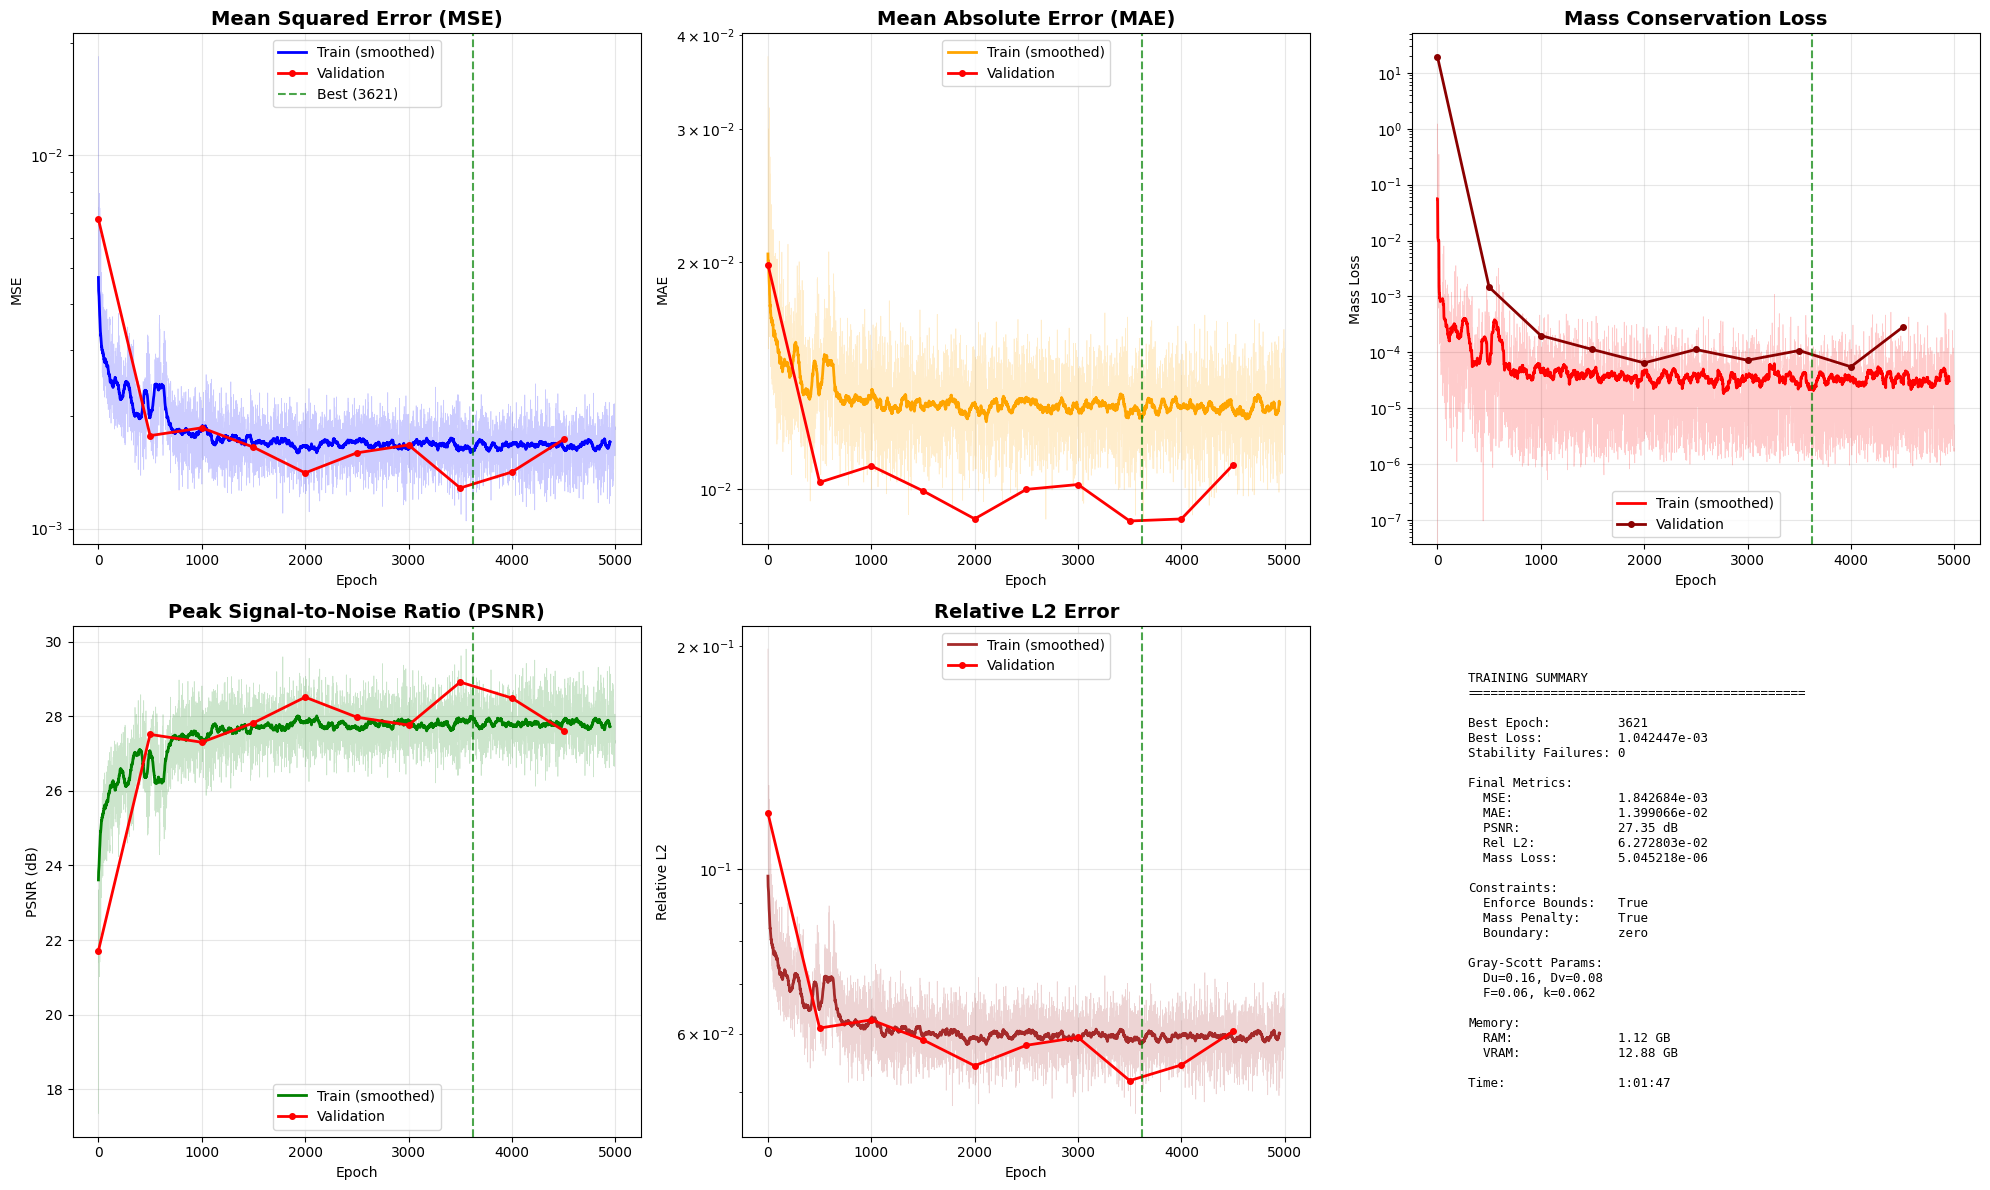


CONSTRAINT SUMMARY
✓ Value bounds [0,1]: ENFORCED
✓ Mass conservation: ENFORCED (penalty=0.01)
✓ Boundary conditions: zero - ENFORCED
✓ Numerical stability: CHECKED
✓ Gradient clipping: ENABLED (max_norm=1.0)


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import imageio
from IPython.display import Image, display
import cv2
from pathlib import Path
import psutil
import time
from datetime import timedelta

# 1. Determinism & Device
torch.manual_seed(42)
np.random.seed(42)
torch.backends.cudnn.benchmark = True
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ==========================================
# Memory & Performance Tracker
# ==========================================
class PerformanceMonitor:
    def __init__(self):
        self.start_time = time.time()
        self.process = psutil.Process()
        self.initial_ram = self.process.memory_info().rss / 1024**3  # GB
        if torch.cuda.is_available():
            torch.cuda.reset_peak_memory_stats()
            self.initial_vram = torch.cuda.memory_allocated() / 1024**3
        else:
            self.initial_vram = 0

    def get_stats(self):
        current_ram = self.process.memory_info().rss / 1024**3
        ram_used = current_ram - self.initial_ram

        if torch.cuda.is_available():
            current_vram = torch.cuda.memory_allocated() / 1024**3
            peak_vram = torch.cuda.max_memory_allocated() / 1024**3
            vram_used = current_vram - self.initial_vram
        else:
            current_vram = peak_vram = vram_used = 0

        elapsed = time.time() - self.start_time

        return {
            'ram_used_gb': ram_used,
            'ram_current_gb': current_ram,
            'vram_used_gb': vram_used,
            'vram_current_gb': current_vram,
            'vram_peak_gb': peak_vram,
            'elapsed_time': elapsed,
            'elapsed_str': str(timedelta(seconds=int(elapsed)))
        }

    def print_stats(self, stage=""):
        stats = self.get_stats()
        print(f"\n{'='*70}")
        print(f"MEMORY & PERFORMANCE - {stage}")
        print(f"{'='*70}")
        print(f"RAM Usage:      {stats['ram_used_gb']:.2f} GB (Current: {stats['ram_current_gb']:.2f} GB)")
        if torch.cuda.is_available():
            print(f"VRAM Usage:     {stats['vram_used_gb']:.2f} GB (Current: {stats['vram_current_gb']:.2f} GB)")
            print(f"VRAM Peak:      {stats['vram_peak_gb']:.2f} GB")
        print(f"Elapsed Time:   {stats['elapsed_str']}")
        print(f"{'='*70}\n")

# Initialize monitor
perf_monitor = PerformanceMonitor()

# ==========================================
# Configuration
# ==========================================
CONFIG = {
    'train_size': 64,
    'test_size': 128,
    'batch_size': 16,
    'epochs': 5000,
    'lr': 0.0005,
    'weight_decay': 5e-5,

    # Gray-Scott parameters (coral pattern)
    'Du': 0.16,      # Diffusion rate for U (activator)
    'Dv': 0.08,      # Diffusion rate for V (inhibitor)
    'feed': 0.060,   # Feed rate (F)
    'kill': 0.062,   # Kill rate (k)
    'dt': 1.0,       # Time step

    'min_steps': 50,
    'max_steps': 200,
    'val_freq': 500,

    # Testing parameters
    'short_test_steps': 500,
    'long_test_steps': 2000,
    'video_fps': 30,
    'frame_interval': 5,

    # Visualization options
    'use_relative_error': True,
    'save_best_weights': True,
    'weights_path': 'best_grayscott_nca_model.pth',
    'boundary': 'zero',  # 'zero' for bounded walls, 'circular' for periodic

    # NEW: Constraint enforcement options
    'enforce_bounds': True,           # Clamp U, V to [0, 1]
    'enforce_mass_conservation': True, # Penalize mass drift
    'mass_penalty_weight': 0.01,      # Weight for mass conservation loss
    'stability_check': True,          # Check for numerical instability
}

# ==========================================
# Enhanced Metrics Calculator
# ==========================================
def calculate_metrics(pred, target):
    """
    Calculate comprehensive metrics between prediction and target
    """
    mse = torch.mean((pred - target)**2).item()
    mae = torch.mean(torch.abs(pred - target)).item()

    # RMSE
    rmse = np.sqrt(mse)

    # PSNR (Peak Signal-to-Noise Ratio)
    max_val = torch.max(target).item()
    if mse > 0 and max_val > 0:
        psnr = 20 * np.log10(max_val / np.sqrt(mse))
    else:
        psnr = float('inf')

    # Relative L2 error
    target_norm = torch.norm(target)
    if target_norm > 1e-10:
        rel_l2 = (torch.norm(pred - target) / target_norm).item()
    else:
        rel_l2 = 0.0

    # Max absolute error
    max_abs_error = torch.max(torch.abs(pred - target)).item()

    return {
        'mse': mse,
        'mae': mae,
        'rmse': rmse,
        'psnr': psnr,
        'rel_l2': rel_l2,
        'max_abs_error': max_abs_error
    }

# ==========================================
# Gray-Scott Analytical Solver (WITH CONSTRAINTS)
# ==========================================
class GrayScottSolver:
    """
    Gray-Scott reaction-diffusion equations with explicit constraint enforcement:
    ∂u/∂t = Du∇²u - uv² + F(1-u)
    ∂v/∂t = Dv∇²v + uv² - (F+k)v

    Constraints:
    1. 0 ≤ u, v ≤ 1 (physical bounds)
    2. Mass conservation (for bounded domains)
    3. Boundary conditions
    """
    def __init__(self, Du, Dv, feed, kill, dt, boundary='zero', enforce_bounds=True):
        self.Du = Du
        self.Dv = Dv
        self.feed = feed
        self.kill = kill
        self.dt = dt
        self.boundary = boundary
        self.enforce_bounds = enforce_bounds

        # Laplacian kernel for discrete diffusion
        self.laplacian = torch.tensor([[0.05, 0.2, 0.05],
                                       [0.2, -1.0, 0.2],
                                       [0.05, 0.2, 0.05]],
                                      dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)

    def step(self, state):
        """
        state: (batch, 2, H, W) - channel 0 is U, channel 1 is V
        """
        u = state[:, 0:1, :, :]
        v = state[:, 1:2, :, :]

        # CONSTRAINT 1: Enforce input bounds before computation
        if self.enforce_bounds:
            u = torch.clamp(u, 0, 1)
            v = torch.clamp(v, 0, 1)

        # Apply boundary conditions
        if self.boundary == 'zero':
            padded_u = torch.nn.functional.pad(u, (1, 1, 1, 1), mode='constant', value=1.0)  # U=1 at boundary
            padded_v = torch.nn.functional.pad(v, (1, 1, 1, 1), mode='constant', value=0.0)  # V=0 at boundary
        else:  # circular
            padded_u = torch.nn.functional.pad(u, (1, 1, 1, 1), mode='circular')
            padded_v = torch.nn.functional.pad(v, (1, 1, 1, 1), mode='circular')

        # Compute Laplacians (diffusion)
        laplacian_u = torch.nn.functional.conv2d(padded_u, self.laplacian)
        laplacian_v = torch.nn.functional.conv2d(padded_v, self.laplacian)

        # Reaction term: uv²
        uvv = u * v * v

        # Gray-Scott equations
        du_dt = self.Du * laplacian_u - uvv + self.feed * (1 - u)
        dv_dt = self.Dv * laplacian_v + uvv - (self.feed + self.kill) * v

        # Update with Euler method
        u_new = u + du_dt * self.dt
        v_new = v + dv_dt * self.dt

        # CONSTRAINT 2: Enforce output bounds
        u_new = torch.clamp(u_new, 0, 1)
        v_new = torch.clamp(v_new, 0, 1)

        # CONSTRAINT 3: Apply boundary conditions to output
        if self.boundary == 'zero':
            # Keep boundaries fixed
            u_new[:, :, 0, :] = 1.0   # top
            u_new[:, :, -1, :] = 1.0  # bottom
            u_new[:, :, :, 0] = 1.0   # left
            u_new[:, :, :, -1] = 1.0  # right

            v_new[:, :, 0, :] = 0.0
            v_new[:, :, -1, :] = 0.0
            v_new[:, :, :, 0] = 0.0
            v_new[:, :, :, -1] = 0.0

        return torch.cat([u_new, v_new], dim=1)

# ==========================================
# Deep Flux-NCA for Gray-Scott (WITH CONSTRAINTS)
# ==========================================
class GrayScottNCA(nn.Module):
    """
    Neural Cellular Automata for Gray-Scott with constraint enforcement
    """
    def __init__(self, boundary='zero', enforce_bounds=True):
        super().__init__()
        self.boundary = boundary
        self.enforce_bounds = enforce_bounds

        # Perceive: learn spatial patterns from both U and V
        padding_mode = 'zeros' if boundary == 'zero' else 'circular'
        self.perceive = nn.Conv2d(2, 64, 3, padding=1, padding_mode=padding_mode)

        # Process: compute updates for U and V
        self.process = nn.Sequential(
            nn.ReLU(),
            nn.Conv2d(64, 128, 1),
            nn.ReLU(),
            nn.Conv2d(128, 64, 1),
            nn.ReLU(),
            nn.Conv2d(64, 4, 1, bias=False)  # 4 channels: flux_u_x, flux_u_y, flux_v_x, flux_v_y
        )

        # Initialize weights
        with torch.no_grad():
            self.process[-1].weight.data.fill_(0.0)  # Start with zero flux (identity mapping)
            nn.init.kaiming_normal_(self.perceive.weight, nonlinearity='relu')
            nn.init.kaiming_normal_(self.process[1].weight, nonlinearity='relu')
            nn.init.kaiming_normal_(self.process[3].weight, nonlinearity='relu')

    def forward(self, x):
        """
        x: (batch, 2, H, W) with channels [U, V]
        Returns: updated state with constraints enforced
        """
        # CONSTRAINT 1: Enforce input bounds
        if self.enforce_bounds:
            x = torch.clamp(x, 0, 1)

        # Perceive spatial patterns
        features = self.perceive(x)

        # Compute flux for both U and V
        flux = self.process(features)

        # Split into U and V fluxes
        flux_u_x = flux[:, 0:1, :, :]
        flux_u_y = flux[:, 1:2, :, :]
        flux_v_x = flux[:, 2:3, :, :]
        flux_v_y = flux[:, 3:4, :, :]

        # Compute divergence (flux conservation)
        du = (torch.roll(flux_u_x, 1, 3) - flux_u_x) + (torch.roll(flux_u_y, 1, 2) - flux_u_y)
        dv = (torch.roll(flux_v_x, 1, 3) - flux_v_x) + (torch.roll(flux_v_y, 1, 2) - flux_v_y)

        # Update state
        u_new = x[:, 0:1, :, :] + du
        v_new = x[:, 1:2, :, :] + dv

        # CONSTRAINT 2: Enforce output bounds
        u_new = torch.clamp(u_new, 0, 1)
        v_new = torch.clamp(v_new, 0, 1)

        # CONSTRAINT 3: Enforce boundary conditions
        if self.boundary == 'zero':
            # Keep boundaries fixed at initial conditions
            u_new[:, :, 0, :] = 1.0   # top
            u_new[:, :, -1, :] = 1.0  # bottom
            u_new[:, :, :, 0] = 1.0   # left
            u_new[:, :, :, -1] = 1.0  # right

            v_new[:, :, 0, :] = 0.0
            v_new[:, :, -1, :] = 0.0
            v_new[:, :, :, 0] = 0.0
            v_new[:, :, :, -1] = 0.0

        return torch.cat([u_new, v_new], dim=1)

# ==========================================
# Initial State Generator
# ==========================================
def make_state(batch_size, size):
    """
    Create initial state for Gray-Scott system with proper constraints
    """
    state = torch.zeros(batch_size, 2, size, size).to(device)

    # Initialize U to 1.0 (full activator)
    state[:, 0, :, :] = 1.0

    # Initialize V with random seeds in the center region
    for i in range(batch_size):
        # Add random seeds for V (inhibitor)
        num_seeds = np.random.randint(3, 8)
        for _ in range(num_seeds):
            # Random position (avoid edges for bounded case)
            margin = size // 8
            cx = np.random.randint(margin, size - margin)
            cy = np.random.randint(margin, size - margin)

            # Random size
            radius = np.random.randint(2, 5)

            # Create circular seed
            y, x = torch.meshgrid(
                torch.arange(size, device=device),
                torch.arange(size, device=device),
                indexing='ij'
            )
            mask = ((x - cx)**2 + (y - cy)**2) <= radius**2
            state[i, 1, mask] = 1.0  # Set V to 1.0 in seed region
            state[i, 0, mask] = 0.0  # Set U to 0.0 in seed region

    # Enforce boundary conditions
    if CONFIG['boundary'] == 'zero':
        state[:, 0, 0, :] = 1.0   # U = 1 at boundaries
        state[:, 0, -1, :] = 1.0
        state[:, 0, :, 0] = 1.0
        state[:, 0, :, -1] = 1.0

        state[:, 1, 0, :] = 0.0   # V = 0 at boundaries
        state[:, 1, -1, :] = 0.0
        state[:, 1, :, 0] = 0.0
        state[:, 1, :, -1] = 0.0

    return state

# ==========================================
# NEW: Constraint Loss Functions
# ==========================================
def compute_mass_conservation_loss(state_initial, state_final):
    """
    Penalize deviation from mass conservation
    For Gray-Scott: total mass should be conserved in closed systems
    """
    initial_total = torch.sum(state_initial, dim=(2, 3))
    final_total = torch.sum(state_final, dim=(2, 3))

    mass_loss = torch.mean((initial_total - final_total)**2)
    return mass_loss

def check_stability(state):
    """
    Check for numerical instability (NaN, Inf, or values way outside [0,1])
    """
    if torch.isnan(state).any():
        return False, "NaN detected"
    if torch.isinf(state).any():
        return False, "Inf detected"
    if torch.max(state) > 10.0 or torch.min(state) < -10.0:
        return False, f"Values out of range: [{torch.min(state):.2f}, {torch.max(state):.2f}]"
    return True, "Stable"

# ==========================================
# Training Loop (WITH CONSTRAINT ENFORCEMENT)
# ==========================================
print("=" * 70)
print("TRAINING GRAY-SCOTT NCA WITH CONSTRAINT ENFORCEMENT")
print("=" * 70)
print(f"Parameters: Du={CONFIG['Du']}, Dv={CONFIG['Dv']}, F={CONFIG['feed']}, k={CONFIG['kill']}")
print(f"Boundary: {CONFIG['boundary']}")
print(f"Constraints: Bounds={CONFIG['enforce_bounds']}, Mass={CONFIG['enforce_mass_conservation']}")
print("=" * 70)

model = GrayScottNCA(boundary=CONFIG['boundary'], enforce_bounds=CONFIG['enforce_bounds']).to(device)
solver = GrayScottSolver(CONFIG['Du'], CONFIG['Dv'], CONFIG['feed'],
                          CONFIG['kill'], CONFIG['dt'], CONFIG['boundary'],
                          CONFIG['enforce_bounds'])
optimizer = optim.Adam(model.parameters(), lr=CONFIG['lr'], weight_decay=CONFIG['weight_decay'])
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=200)
loss_fn = nn.MSELoss()

# Enhanced tracking
train_metrics = {
    'mse': [], 'mae': [], 'rmse': [], 'psnr': [], 'rel_l2': [], 'mass_loss': []
}
val_metrics = {
    'epoch': [], 'mse': [], 'mae': [], 'rmse': [], 'psnr': [], 'rel_l2': [], 'mass_loss': []
}

best_loss = float('inf')
best_weights = None
best_epoch = 0
stability_failures = 0

perf_monitor.print_stats("Before Training")

for i in range(CONFIG['epochs']):
    model.train()
    initial_state = make_state(CONFIG['batch_size'], CONFIG['train_size'])

    target = initial_state.clone()
    pred = initial_state.clone()
    current_steps = np.random.randint(CONFIG['min_steps'], CONFIG['max_steps'])

    seq_loss = 0
    mass_loss_accum = 0

    for step in range(current_steps):
        with torch.no_grad():
            target = solver.step(target)
        pred = model(pred)

        # Primary loss: match the analytical solution
        seq_loss += loss_fn(pred, target)

        # NEW: Mass conservation loss
        if CONFIG['enforce_mass_conservation']:
            mass_loss = compute_mass_conservation_loss(initial_state, pred)
            mass_loss_accum += mass_loss

    # Combined loss
    loss_val = seq_loss / current_steps
    if CONFIG['enforce_mass_conservation']:
        mass_penalty = (mass_loss_accum / current_steps) * CONFIG['mass_penalty_weight']
        total_loss = loss_val + mass_penalty
    else:
        total_loss = loss_val
        mass_penalty = 0

    # NEW: Stability check
    if CONFIG['stability_check']:
        is_stable, stability_msg = check_stability(pred)
        if not is_stable:
            stability_failures += 1
            if stability_failures > 10:
                print(f"\n⚠️  Too many stability failures ({stability_failures}). {stability_msg}")
                print("    Consider: reducing learning rate or time step (dt)")
            continue  # Skip this batch

    optimizer.zero_grad()
    total_loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()
    scheduler.step(total_loss)

    # Calculate training metrics
    with torch.no_grad():
        metrics = calculate_metrics(pred, target)
        train_metrics['mse'].append(metrics['mse'])
        train_metrics['mae'].append(metrics['mae'])
        train_metrics['rmse'].append(metrics['rmse'])
        train_metrics['psnr'].append(metrics['psnr'])
        train_metrics['rel_l2'].append(metrics['rel_l2'])
        train_metrics['mass_loss'].append(mass_penalty.item() if CONFIG['enforce_mass_conservation'] else 0)

    # Validation
    if i % CONFIG['val_freq'] == 0:
        model.eval()
        with torch.no_grad():
            v_initial = make_state(CONFIG['batch_size'], CONFIG['train_size'])
            v_target, v_pred = v_initial.clone(), v_initial.clone()

            for _ in range(20):
                v_target = solver.step(v_target)
                v_pred = model(v_pred)

            v_metrics = calculate_metrics(v_pred, v_target)
            v_mass_loss = compute_mass_conservation_loss(v_initial, v_pred).item() if CONFIG['enforce_mass_conservation'] else 0

            val_metrics['epoch'].append(i)
            val_metrics['mse'].append(v_metrics['mse'])
            val_metrics['mae'].append(v_metrics['mae'])
            val_metrics['rmse'].append(v_metrics['rmse'])
            val_metrics['psnr'].append(v_metrics['psnr'])
            val_metrics['rel_l2'].append(v_metrics['rel_l2'])
            val_metrics['mass_loss'].append(v_mass_loss)

            print(f"Epoch {i:4d}: Loss {total_loss.item():.7f} (MSE:{loss_val.item():.7f} Mass:{mass_penalty:.7f}) | "
                  f"Val MSE {v_metrics['mse']:.7f} | PSNR {v_metrics['psnr']:.2f} dB")

    # Save best weights
    if total_loss.item() < best_loss:
        best_loss = total_loss.item()
        best_epoch = i
        if CONFIG['save_best_weights']:
            best_weights = {
                'epoch': i,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'loss': best_loss,
                'config': CONFIG
            }

# Save best model
if CONFIG['save_best_weights'] and best_weights is not None:
    torch.save(best_weights, CONFIG['weights_path'])
    print(f"\n✓ Best model weights saved to {CONFIG['weights_path']}")
    print(f"  Best epoch: {best_epoch}, Best loss: {best_loss:.7f}")
    if stability_failures > 0:
        print(f"  ⚠️  Stability failures during training: {stability_failures}")

# Load best weights for testing
if best_weights is not None:
    model.load_state_dict(best_weights['model_state_dict'])
    print(f"✓ Loaded best weights from epoch {best_epoch}")

perf_monitor.print_stats("After Training")

# ==========================================
# Plot Training Metrics (WITH MASS CONSERVATION)
# ==========================================
print("\n" + "="*70)
print("GENERATING TRAINING METRICS PLOTS")
print("="*70)

fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# Smooth training curves
def smooth(data, window=50):
    if len(data) < window:
        return data
    return np.convolve(data, np.ones(window)/window, mode='valid')

# MSE
axes[0, 0].plot(train_metrics['mse'], alpha=0.2, color='blue', linewidth=0.5)
smoothed = smooth(train_metrics['mse'])
axes[0, 0].plot(range(len(smoothed)), smoothed, color='blue', linewidth=2, label='Train (smoothed)')
if val_metrics['epoch']:
    axes[0, 0].plot(val_metrics['epoch'], val_metrics['mse'], 'o-', color='red',
                    markersize=4, linewidth=2, label='Validation')
axes[0, 0].axvline(best_epoch, color='green', linestyle='--', alpha=0.7, label=f'Best ({best_epoch})')
axes[0, 0].set_yscale('log')
axes[0, 0].set_title('Mean Squared Error (MSE)', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('MSE')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# MAE
axes[0, 1].plot(train_metrics['mae'], alpha=0.2, color='orange', linewidth=0.5)
smoothed = smooth(train_metrics['mae'])
axes[0, 1].plot(range(len(smoothed)), smoothed, color='orange', linewidth=2, label='Train (smoothed)')
if val_metrics['epoch']:
    axes[0, 1].plot(val_metrics['epoch'], val_metrics['mae'], 'o-', color='red',
                    markersize=4, linewidth=2, label='Validation')
axes[0, 1].axvline(best_epoch, color='green', linestyle='--', alpha=0.7)
axes[0, 1].set_yscale('log')
axes[0, 1].set_title('Mean Absolute Error (MAE)', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('MAE')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# NEW: Mass Conservation Loss
if CONFIG['enforce_mass_conservation']:
    axes[0, 2].plot(train_metrics['mass_loss'], alpha=0.2, color='red', linewidth=0.5)
    smoothed = smooth(train_metrics['mass_loss'])
    axes[0, 2].plot(range(len(smoothed)), smoothed, color='red', linewidth=2, label='Train (smoothed)')
    if val_metrics['epoch']:
        axes[0, 2].plot(val_metrics['epoch'], val_metrics['mass_loss'], 'o-', color='darkred',
                        markersize=4, linewidth=2, label='Validation')
    axes[0, 2].axvline(best_epoch, color='green', linestyle='--', alpha=0.7)
    axes[0, 2].set_yscale('log')
    axes[0, 2].set_title('Mass Conservation Loss', fontsize=14, fontweight='bold')
    axes[0, 2].set_xlabel('Epoch')
    axes[0, 2].set_ylabel('Mass Loss')
    axes[0, 2].legend()
    axes[0, 2].grid(True, alpha=0.3)
else:
    # PSNR if not using mass conservation
    psnr_filtered = [p for p in train_metrics['psnr'] if p != float('inf')]
    axes[0, 2].plot(psnr_filtered, alpha=0.2, color='green', linewidth=0.5)
    if len(psnr_filtered) >= 50:
        smoothed = smooth(psnr_filtered)
        axes[0, 2].plot(range(len(smoothed)), smoothed, color='green', linewidth=2, label='Train (smoothed)')
    axes[0, 2].set_title('PSNR', fontsize=14, fontweight='bold')
    axes[0, 2].set_xlabel('Epoch')
    axes[0, 2].set_ylabel('PSNR (dB)')
    axes[0, 2].legend()
    axes[0, 2].grid(True, alpha=0.3)

# PSNR
psnr_filtered = [p for p in train_metrics['psnr'] if p != float('inf')]
axes[1, 0].plot(psnr_filtered, alpha=0.2, color='green', linewidth=0.5)
if len(psnr_filtered) >= 50:
    smoothed = smooth(psnr_filtered)
    axes[1, 0].plot(range(len(smoothed)), smoothed, color='green', linewidth=2, label='Train (smoothed)')
if val_metrics['epoch']:
    axes[1, 0].plot(val_metrics['epoch'], val_metrics['psnr'], 'o-', color='red',
                    markersize=4, linewidth=2, label='Validation')
axes[1, 0].axvline(best_epoch, color='green', linestyle='--', alpha=0.7)
axes[1, 0].set_title('Peak Signal-to-Noise Ratio (PSNR)', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('PSNR (dB)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Relative L2 Error
axes[1, 1].plot(train_metrics['rel_l2'], alpha=0.2, color='brown', linewidth=0.5)
smoothed = smooth(train_metrics['rel_l2'])
axes[1, 1].plot(range(len(smoothed)), smoothed, color='brown', linewidth=2, label='Train (smoothed)')
if val_metrics['epoch']:
    axes[1, 1].plot(val_metrics['epoch'], val_metrics['rel_l2'], 'o-', color='red',
                    markersize=4, linewidth=2, label='Validation')
axes[1, 1].axvline(best_epoch, color='green', linestyle='--', alpha=0.7)
axes[1, 1].set_yscale('log')
axes[1, 1].set_title('Relative L2 Error', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Relative L2')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# Training Summary
axes[1, 2].axis('off')
final_stats = perf_monitor.get_stats()
summary_text = f"""
TRAINING SUMMARY
{'='*45}

Best Epoch:         {best_epoch}
Best Loss:          {best_loss:.6e}
Stability Failures: {stability_failures}

Final Metrics:
  MSE:              {train_metrics['mse'][-1]:.6e}
  MAE:              {train_metrics['mae'][-1]:.6e}
  PSNR:             {train_metrics['psnr'][-1]:.2f} dB
  Rel L2:           {train_metrics['rel_l2'][-1]:.6e}
  Mass Loss:        {train_metrics['mass_loss'][-1]:.6e}

Constraints:
  Enforce Bounds:   {CONFIG['enforce_bounds']}
  Mass Penalty:     {CONFIG['enforce_mass_conservation']}
  Boundary:         {CONFIG['boundary']}

Gray-Scott Params:
  Du={CONFIG['Du']}, Dv={CONFIG['Dv']}
  F={CONFIG['feed']}, k={CONFIG['kill']}

Memory:
  RAM:              {final_stats['ram_used_gb']:.2f} GB
  VRAM:             {final_stats['vram_peak_gb']:.2f} GB

Time:               {final_stats['elapsed_str']}
"""
axes[1, 2].text(0.1, 0.5, summary_text, fontsize=9, family='monospace',
                verticalalignment='center')

plt.tight_layout()
plt.savefig('grayscott_training_metrics.png', dpi=150, bbox_inches='tight')
print("✓ Training metrics saved: grayscott_training_metrics.png")
plt.show()

print("\n" + "="*70)
print("CONSTRAINT SUMMARY")
print("="*70)
print(f"✓ Value bounds [0,1]: {'ENFORCED' if CONFIG['enforce_bounds'] else 'NOT ENFORCED'}")
print(f"✓ Mass conservation: {'ENFORCED (penalty={})'.format(CONFIG['mass_penalty_weight']) if CONFIG['enforce_mass_conservation'] else 'NOT ENFORCED'}")
print(f"✓ Boundary conditions: {CONFIG['boundary']} - ENFORCED")
print(f"✓ Numerical stability: {'CHECKED' if CONFIG['stability_check'] else 'NOT CHECKED'}")
print(f"✓ Gradient clipping: ENABLED (max_norm=1.0)")
print("="*70)


STARTING POST-TRAINING SIMULATIONS

MEMORY & PERFORMANCE - Before Testing
RAM Usage:      1.23 GB (Current: 1.74 GB)
VRAM Usage:     0.00 GB (Current: 0.00 GB)
VRAM Peak:      12.88 GB
Elapsed Time:   1:05:19


TEST 1: Training Scale (Short): 64×64 for 500 steps
  Step 100/500: MSE=2.30e-03, MAE=1.74e-02, PSNR=26.37 dB
  Step 200/500: MSE=2.60e-03, MAE=1.98e-02, PSNR=25.85 dB
  Step 300/500: MSE=3.09e-03, MAE=2.22e-02, PSNR=25.11 dB
  Step 400/500: MSE=3.44e-03, MAE=2.35e-02, PSNR=24.63 dB
  Step 500/500: MSE=3.67e-03, MAE=2.45e-02, PSNR=24.35 dB

✓ GIF saved: gs_64x64_short_comparison.gif
✓ Metrics plot saved: gs_64x64_short_metrics.png


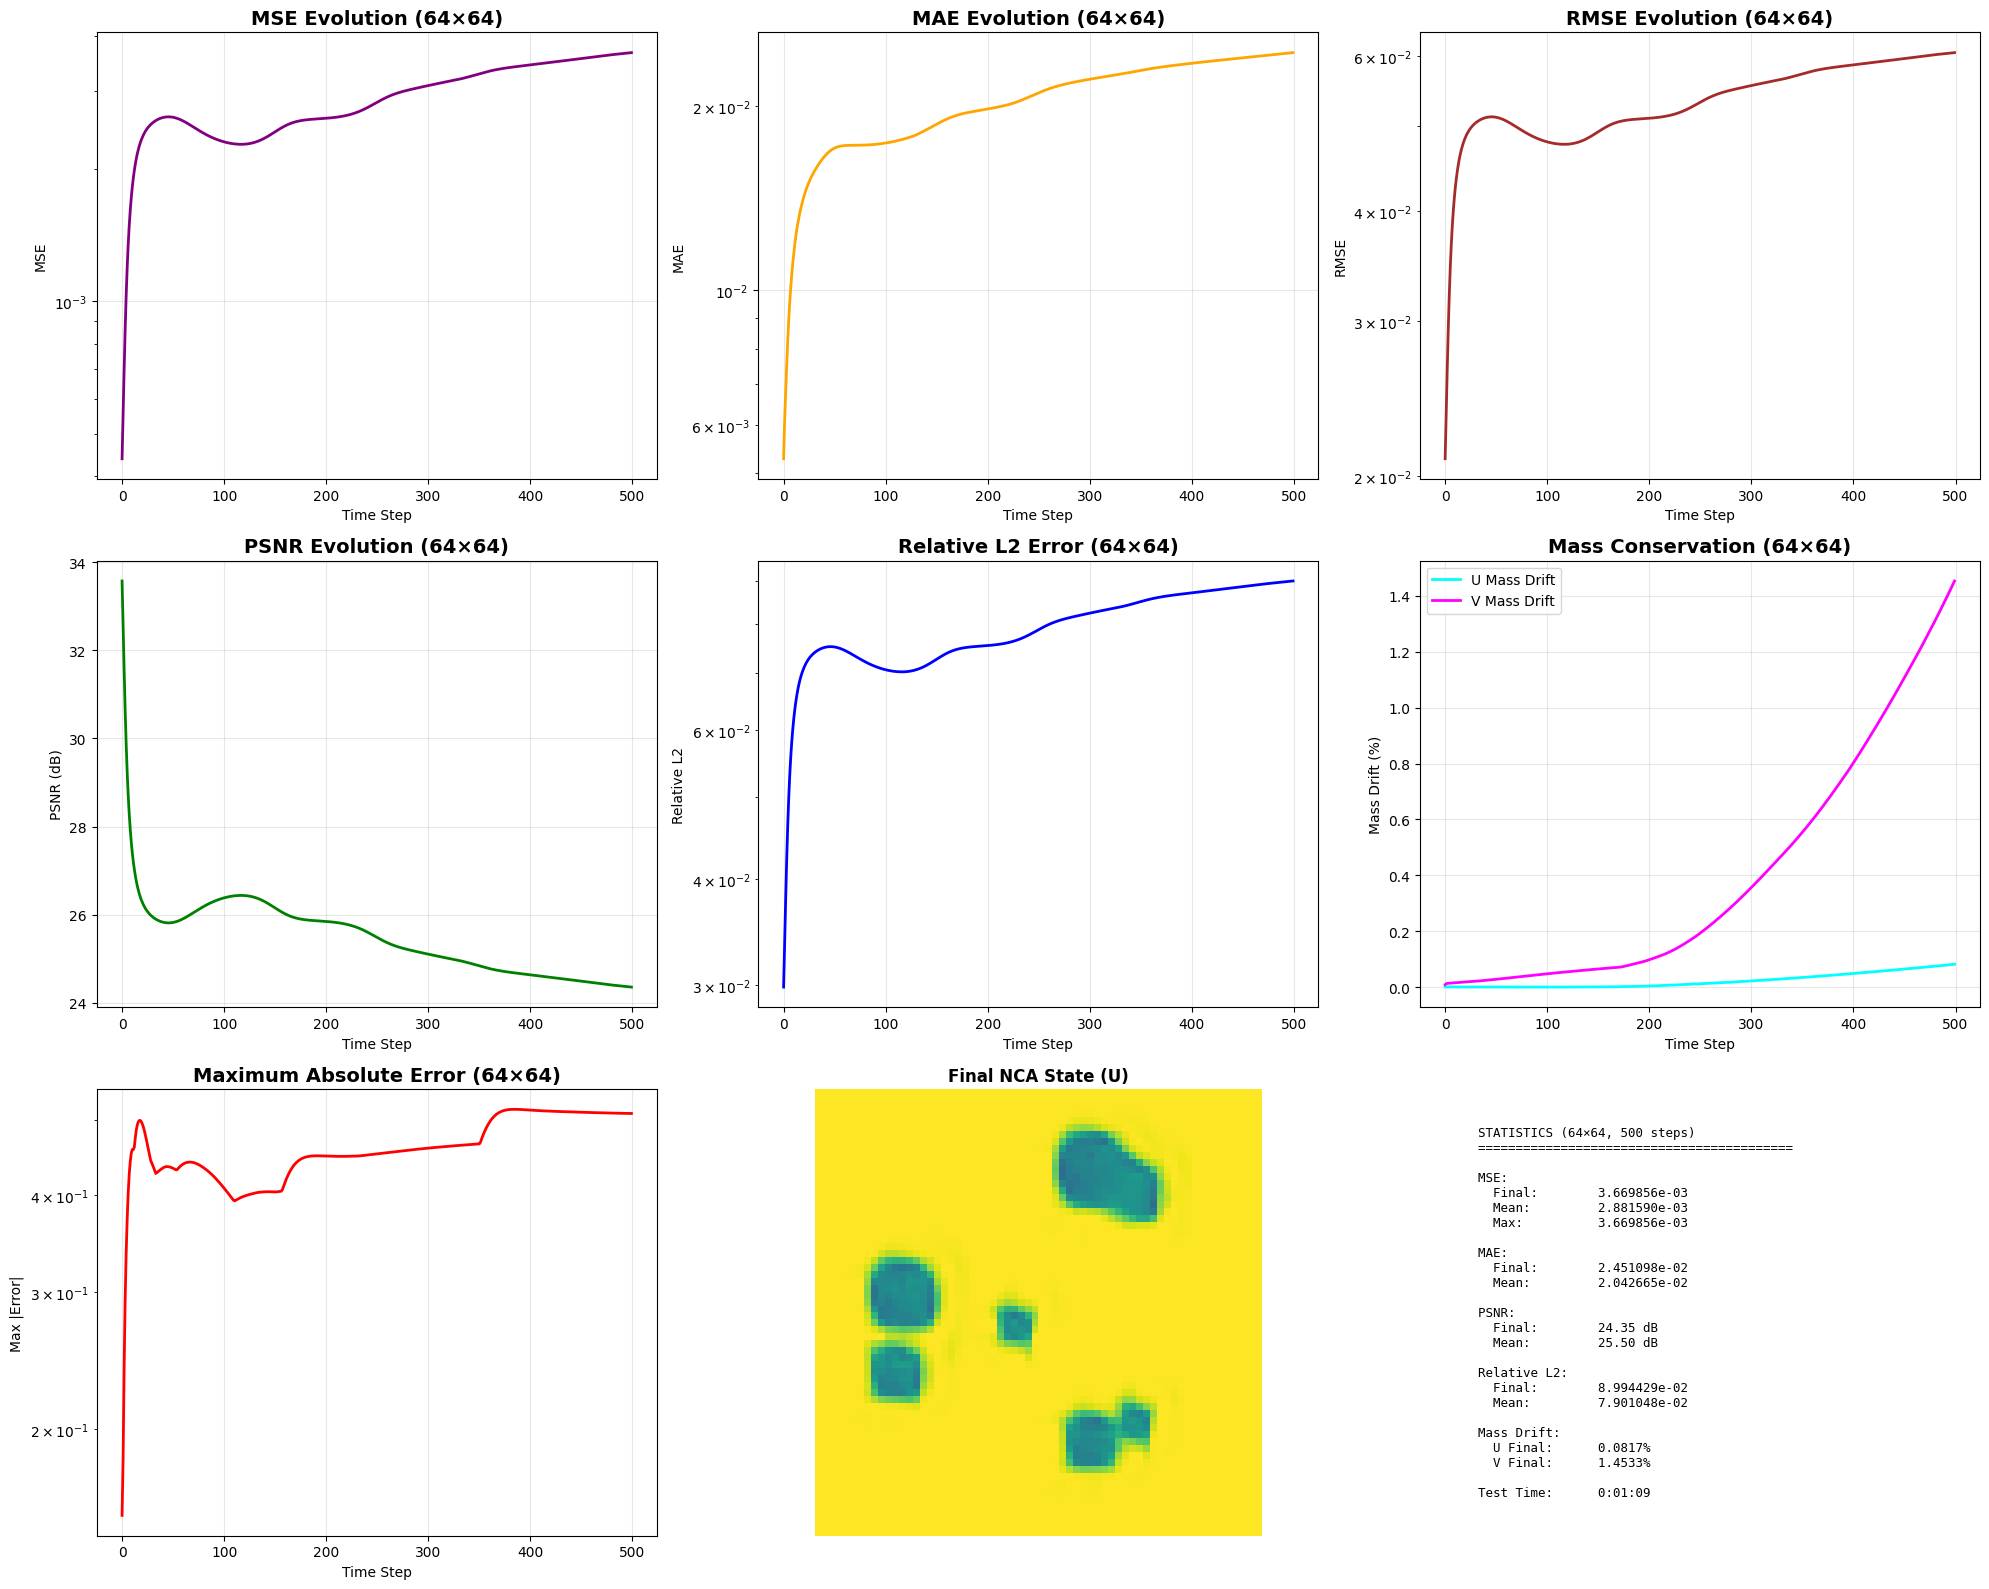


TEST 2: Training Scale (Long): 64×64 for 2000 steps
  Step 100/2000: MSE=1.38e-03, MAE=1.33e-02, PSNR=28.59 dB
  Step 200/2000: MSE=1.93e-03, MAE=1.62e-02, PSNR=27.15 dB
  Step 300/2000: MSE=2.56e-03, MAE=1.87e-02, PSNR=25.92 dB
  Step 400/2000: MSE=2.79e-03, MAE=1.96e-02, PSNR=25.55 dB
  Step 500/2000: MSE=2.84e-03, MAE=2.01e-02, PSNR=25.46 dB
  Step 600/2000: MSE=2.96e-03, MAE=2.08e-02, PSNR=25.29 dB
  Step 700/2000: MSE=3.12e-03, MAE=2.15e-02, PSNR=25.06 dB
  Step 800/2000: MSE=3.33e-03, MAE=2.24e-02, PSNR=24.78 dB
  Step 900/2000: MSE=3.54e-03, MAE=2.32e-02, PSNR=24.51 dB
  Step 1000/2000: MSE=3.76e-03, MAE=2.41e-02, PSNR=24.25 dB
  Step 1100/2000: MSE=3.99e-03, MAE=2.50e-02, PSNR=23.99 dB
  Step 1200/2000: MSE=4.23e-03, MAE=2.59e-02, PSNR=23.74 dB
  Step 1300/2000: MSE=4.45e-03, MAE=2.68e-02, PSNR=23.51 dB
  Step 1400/2000: MSE=4.71e-03, MAE=2.77e-02, PSNR=23.27 dB
  Step 1500/2000: MSE=4.98e-03, MAE=2.87e-02, PSNR=23.02 dB
  Step 1600/2000: MSE=5.31e-03, MAE=2.97e-02, PSNR=22.75

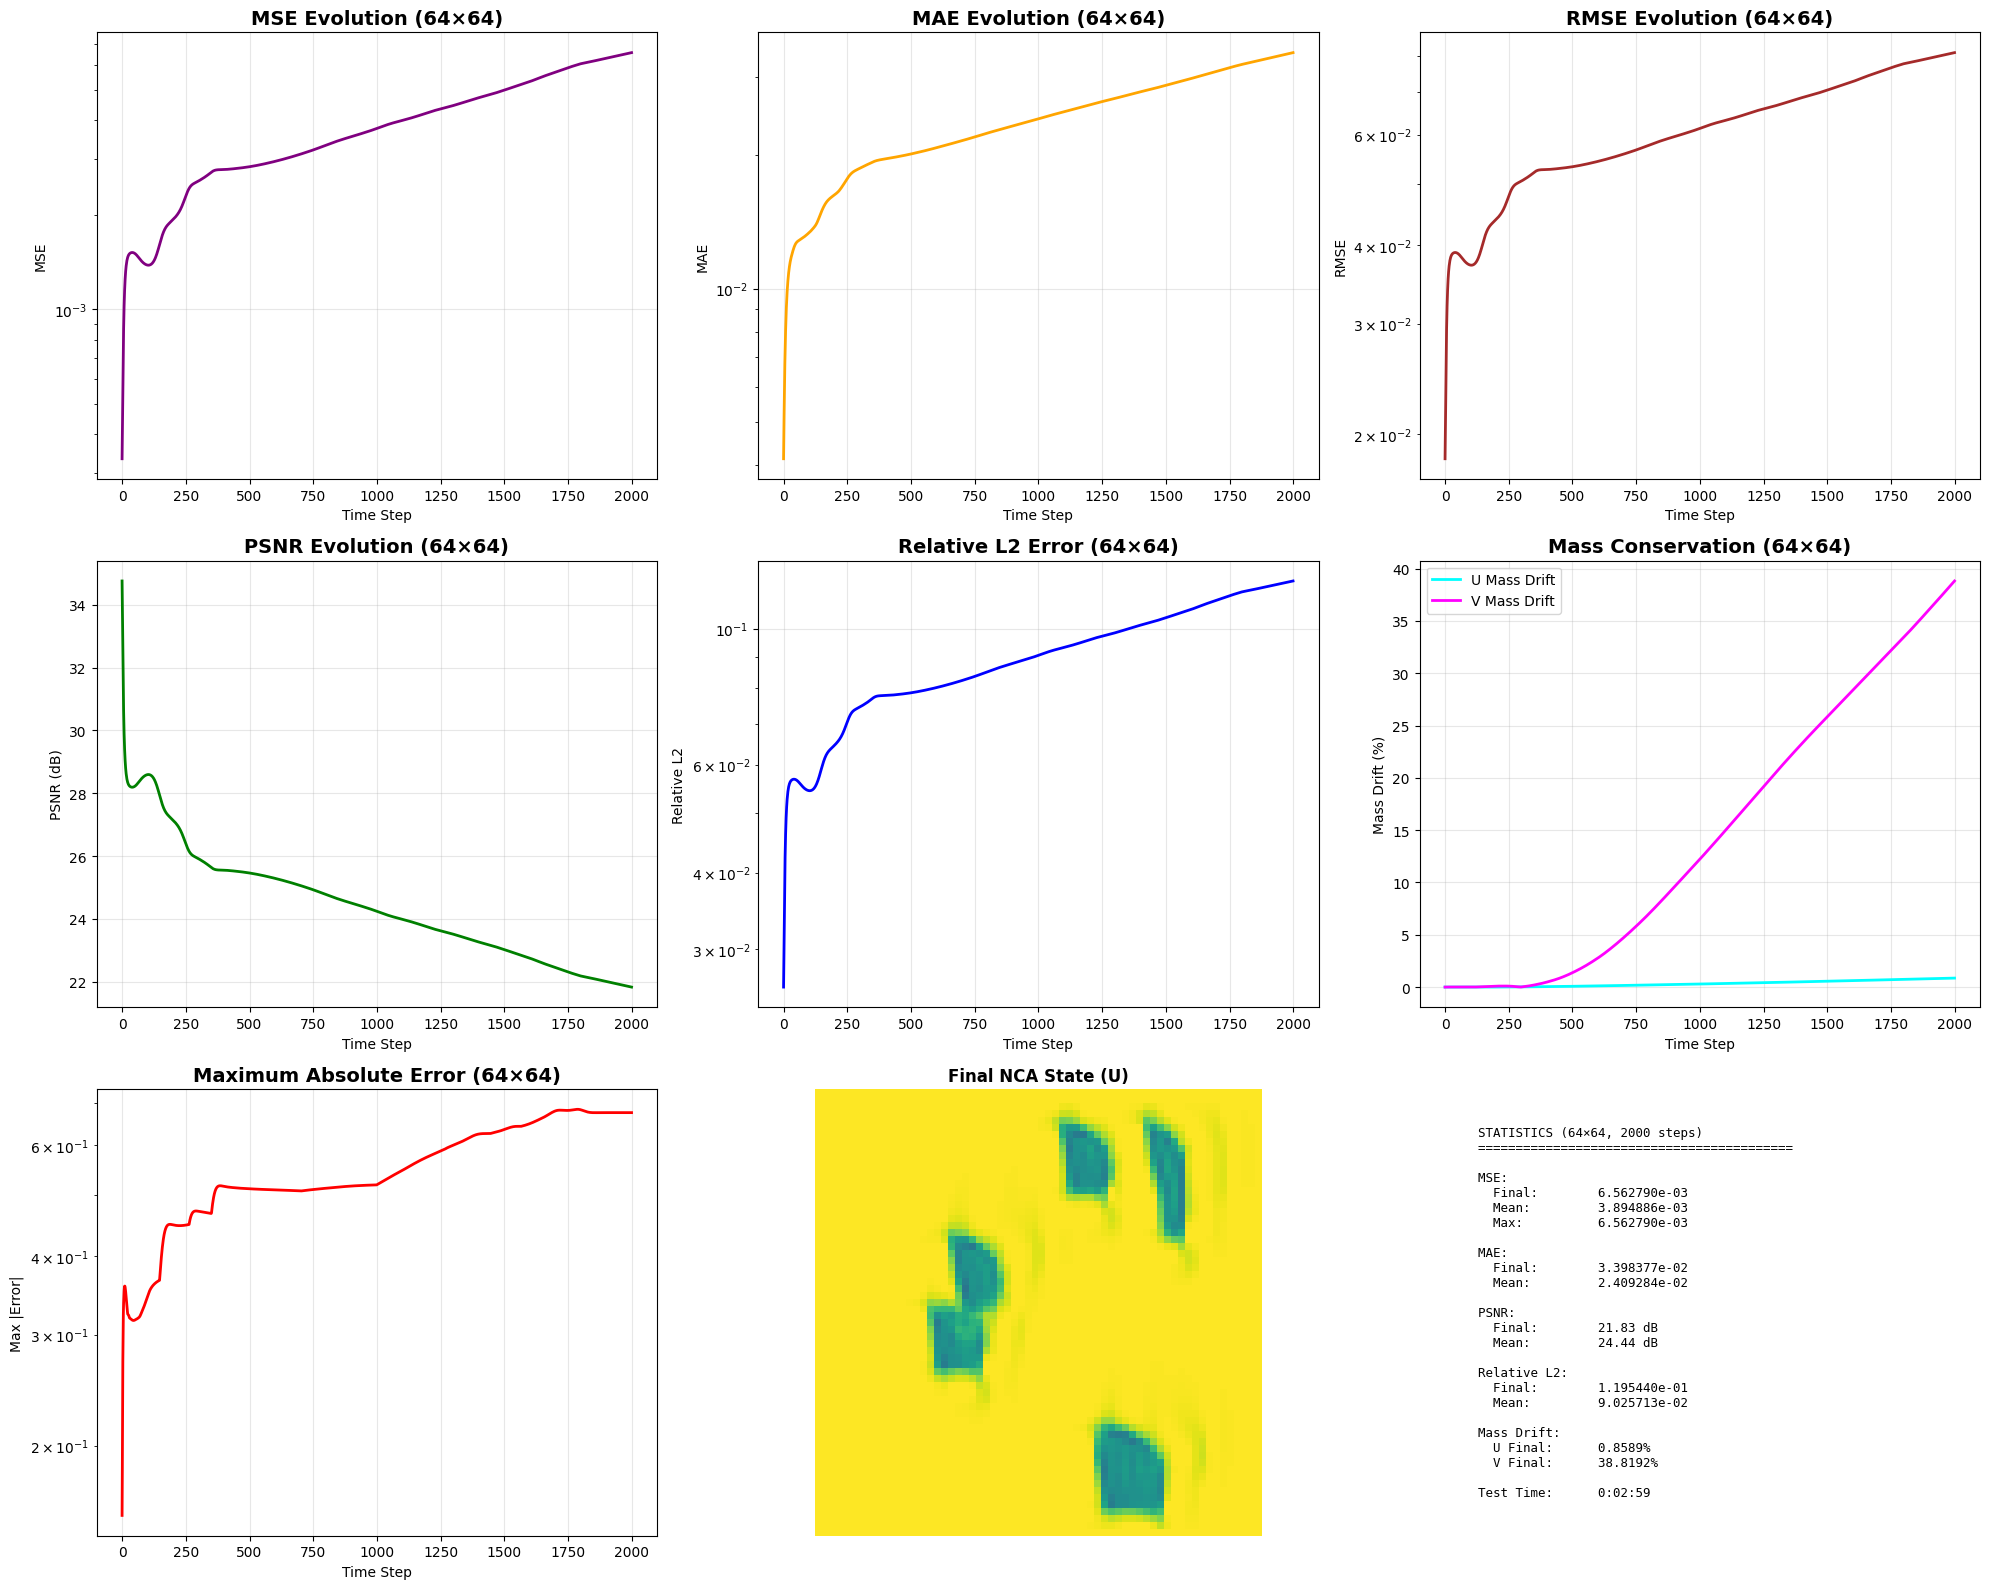


TEST 3: Generalization to Larger Scale (Short): 128×128 for 500 steps
  Step 100/500: MSE=1.31e-04, MAE=1.65e-03, PSNR=38.83 dB
  Step 200/500: MSE=2.02e-04, MAE=2.07e-03, PSNR=36.94 dB
  Step 300/500: MSE=3.15e-04, MAE=2.47e-03, PSNR=35.02 dB
  Step 400/500: MSE=3.18e-04, MAE=2.57e-03, PSNR=34.98 dB
  Step 500/500: MSE=3.30e-04, MAE=2.68e-03, PSNR=34.81 dB

✓ GIF saved: gs_128x128_short_comparison.gif
✓ Metrics plot saved: gs_128x128_short_metrics.png


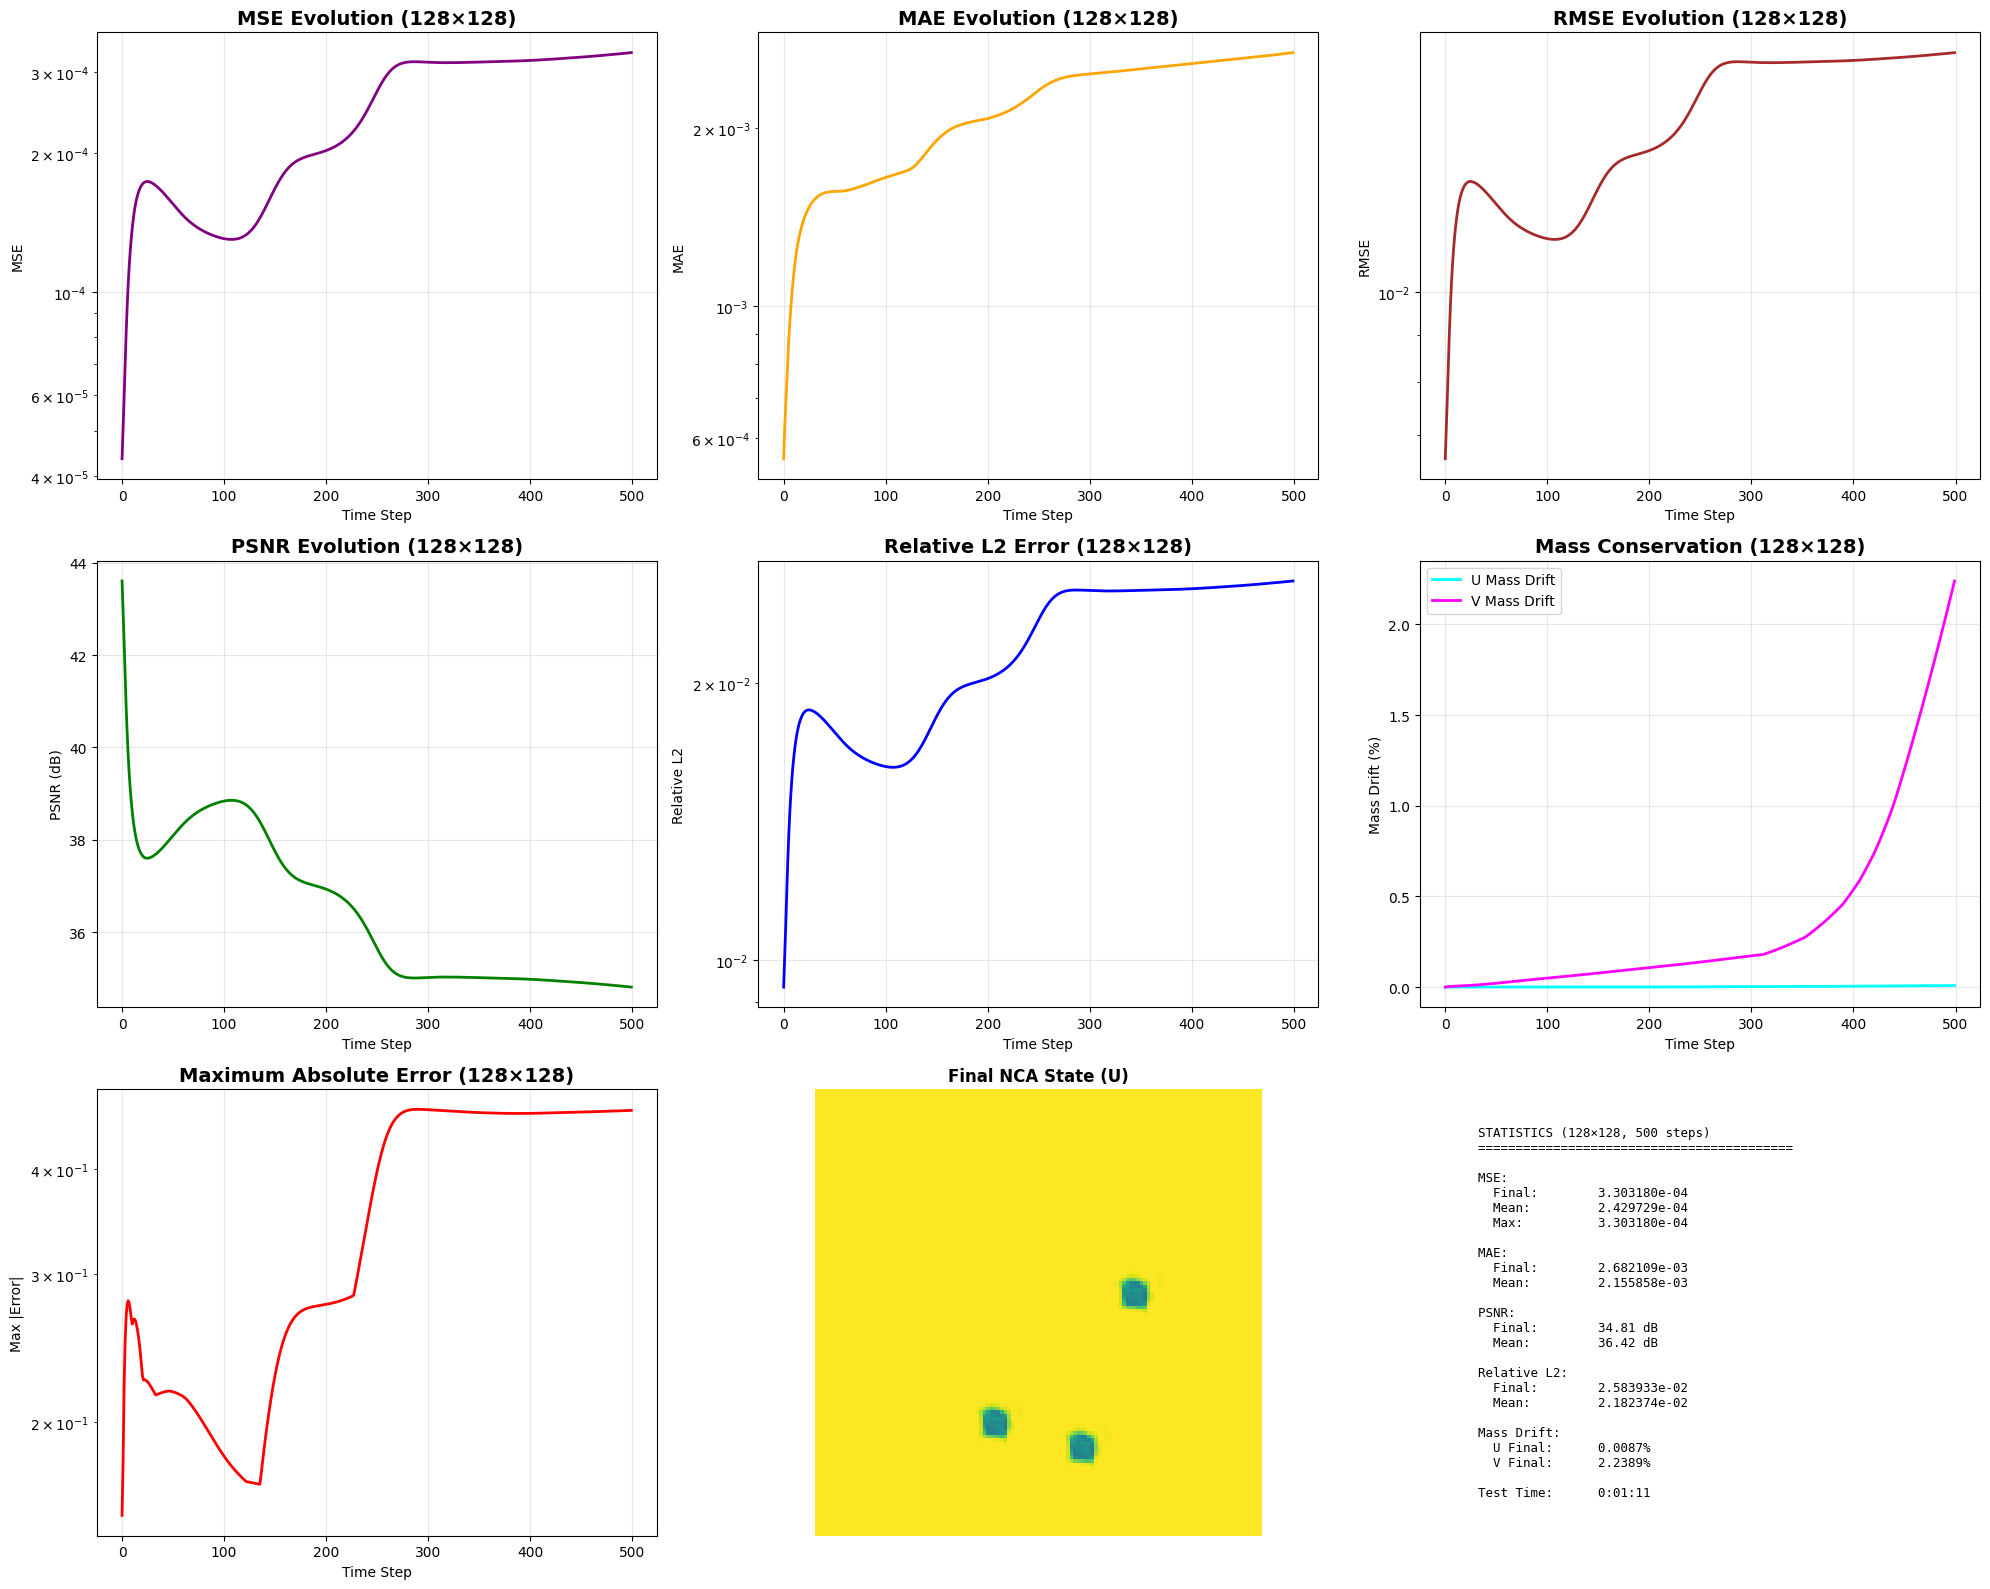


TEST 4: Generalization to Larger Scale (Long): 128×128 for 2000 steps
  Step 100/2000: MSE=3.56e-04, MAE=2.92e-03, PSNR=34.48 dB
  Step 200/2000: MSE=5.49e-04, MAE=3.67e-03, PSNR=32.60 dB
  Step 300/2000: MSE=6.07e-04, MAE=3.99e-03, PSNR=32.17 dB
  Step 400/2000: MSE=6.57e-04, MAE=4.20e-03, PSNR=31.82 dB
  Step 500/2000: MSE=6.79e-04, MAE=4.34e-03, PSNR=31.68 dB
  Step 600/2000: MSE=7.06e-04, MAE=4.48e-03, PSNR=31.51 dB
  Step 700/2000: MSE=7.50e-04, MAE=4.67e-03, PSNR=31.25 dB
  Step 800/2000: MSE=8.10e-04, MAE=4.91e-03, PSNR=30.91 dB
  Step 900/2000: MSE=8.49e-04, MAE=5.12e-03, PSNR=30.71 dB
  Step 1000/2000: MSE=8.93e-04, MAE=5.34e-03, PSNR=30.49 dB
  Step 1100/2000: MSE=9.33e-04, MAE=5.55e-03, PSNR=30.30 dB
  Step 1200/2000: MSE=9.82e-04, MAE=5.78e-03, PSNR=30.08 dB
  Step 1300/2000: MSE=1.04e-03, MAE=6.02e-03, PSNR=29.82 dB
  Step 1400/2000: MSE=1.11e-03, MAE=6.26e-03, PSNR=29.55 dB
  Step 1500/2000: MSE=1.16e-03, MAE=6.50e-03, PSNR=29.34 dB
  Step 1600/2000: MSE=1.22e-03, MAE=6.

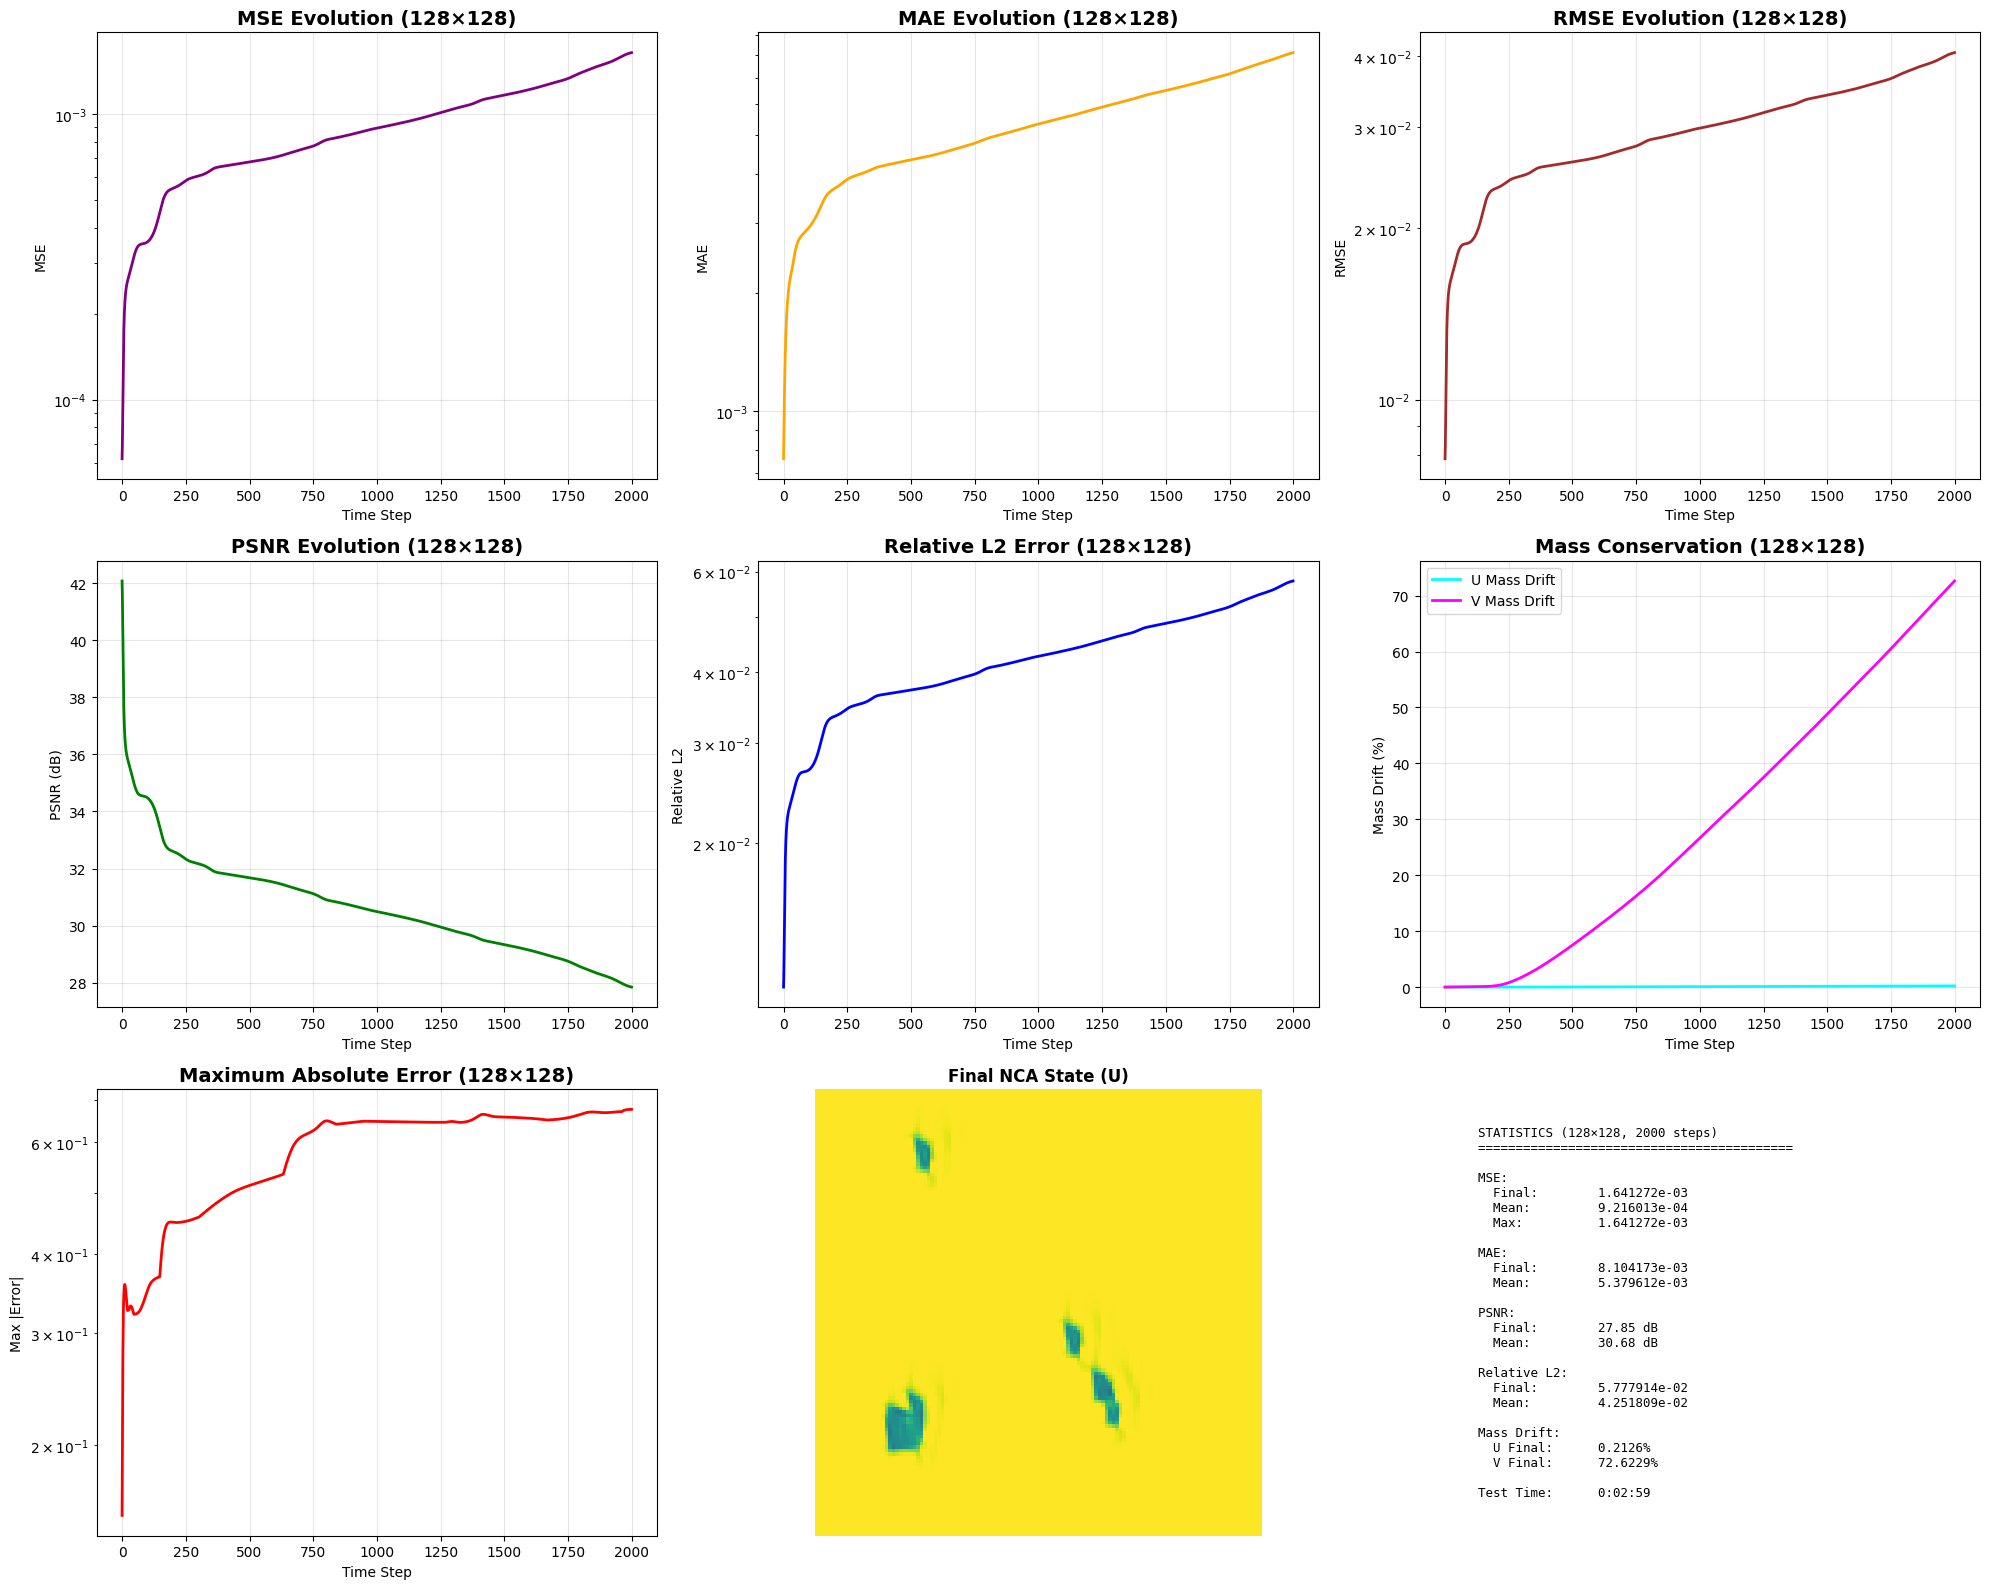


MEMORY & PERFORMANCE - After All Tests
RAM Usage:      6.06 GB (Current: 6.57 GB)
VRAM Usage:     0.00 GB (Current: 0.00 GB)
VRAM Peak:      12.88 GB
Elapsed Time:   1:13:55


GENERATING CROSS-SCALE COMPARISON
✓ Cross-scale comparison saved: grayscott_cross_scale_comparison.png


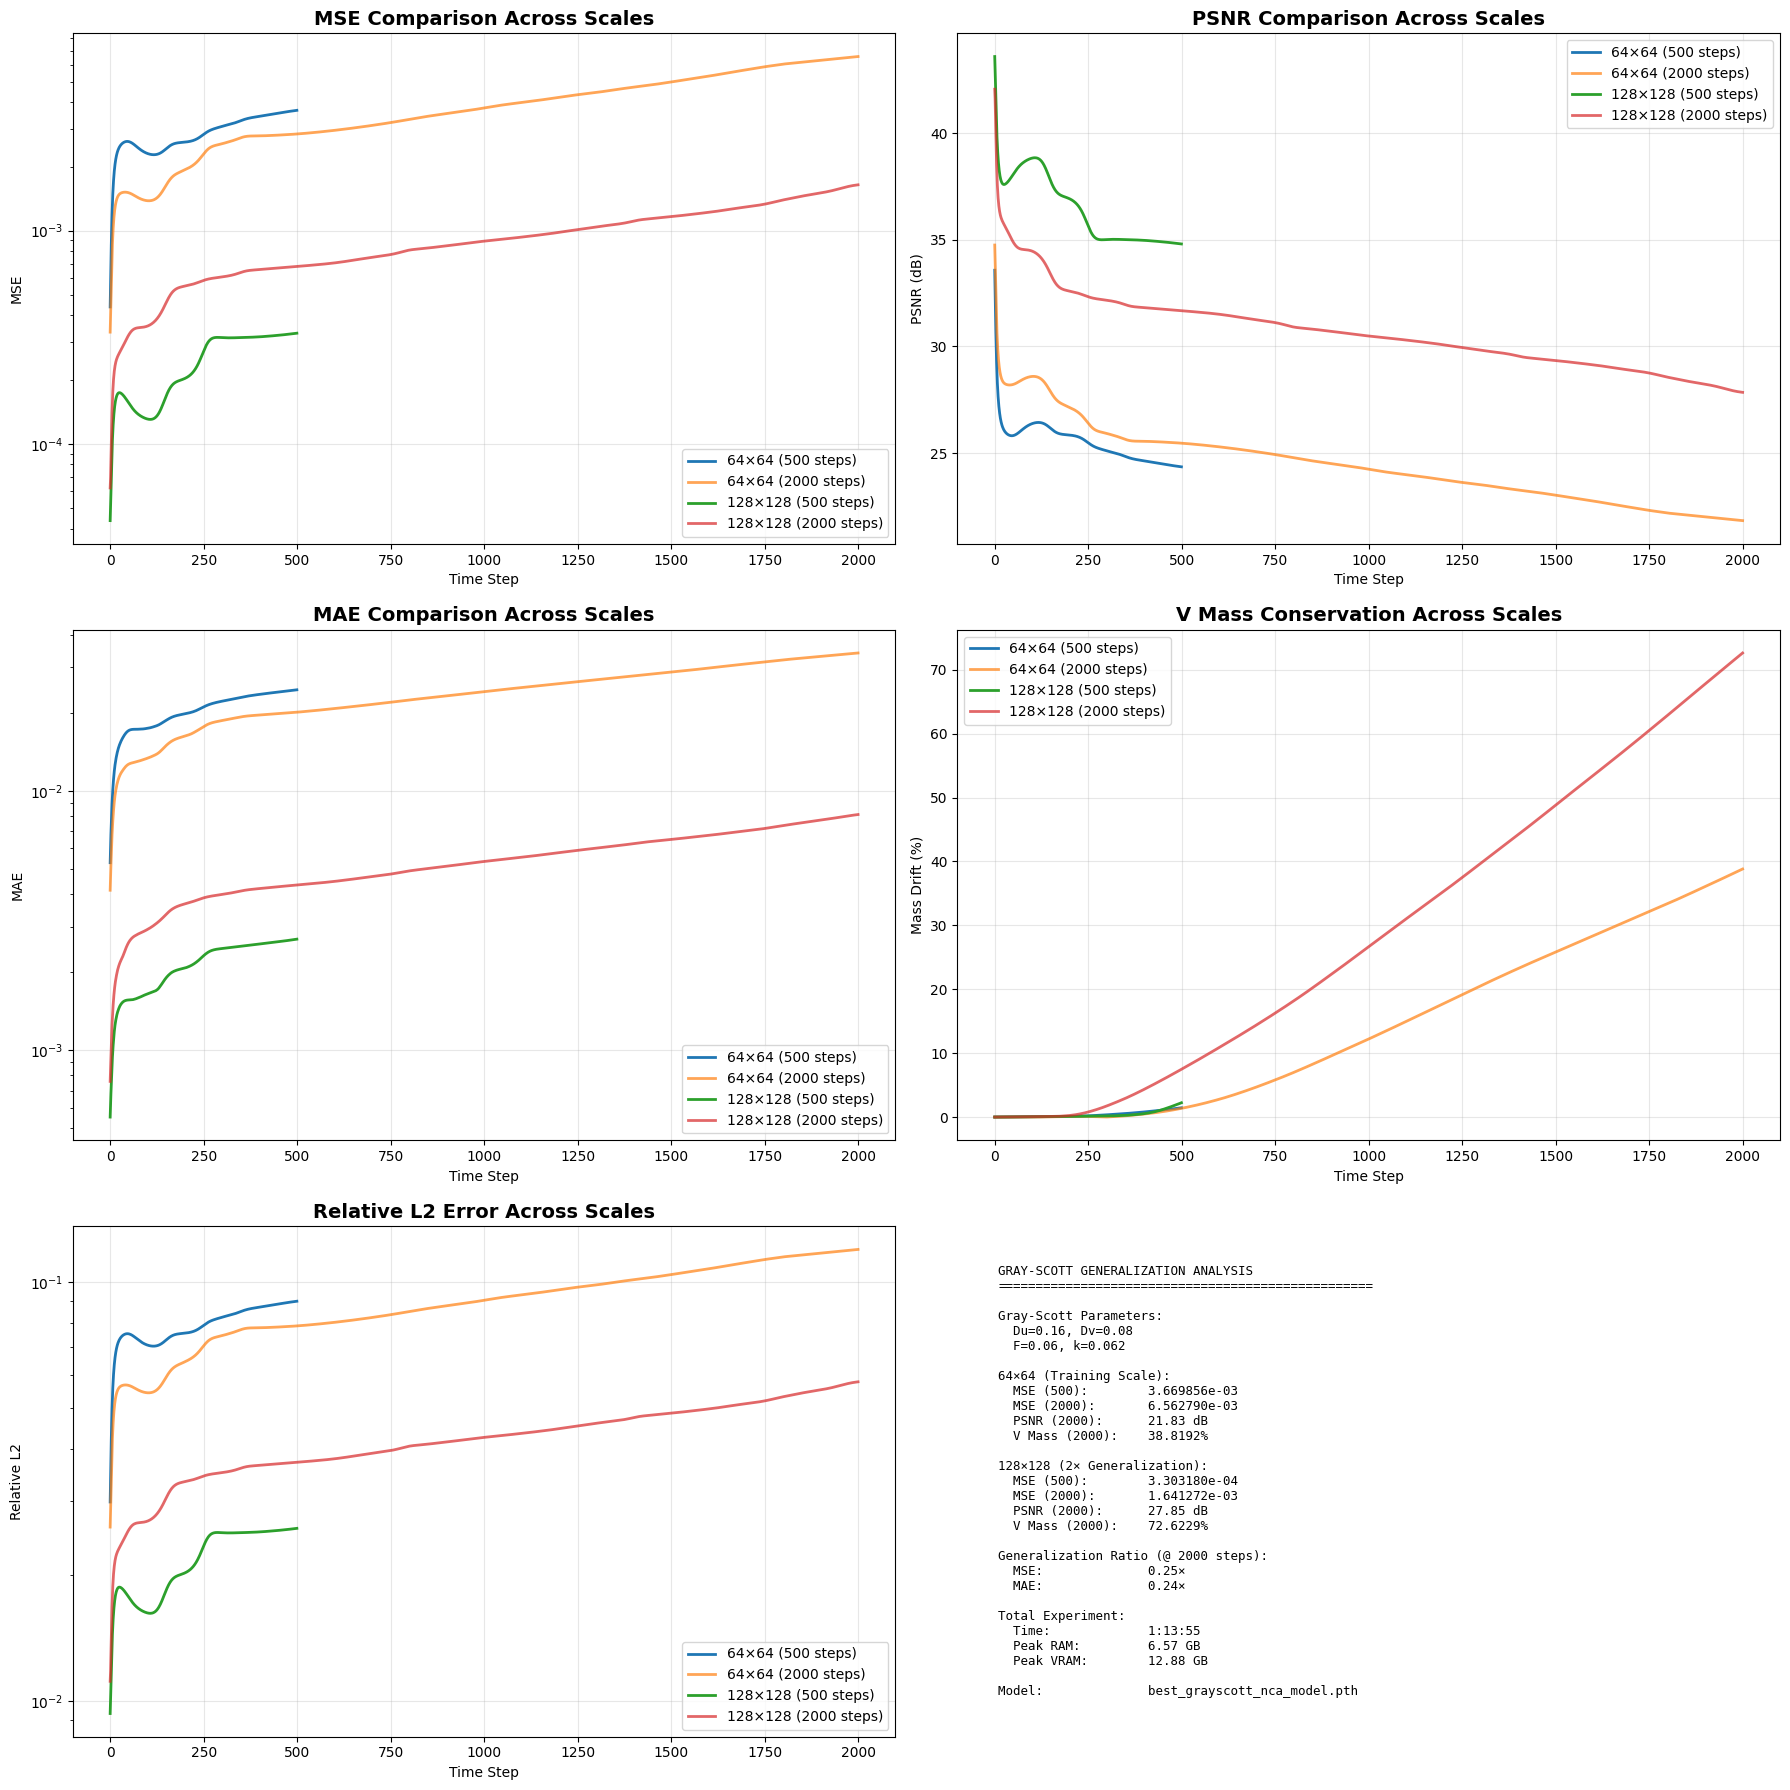


ALL TESTS COMPLETE!

Generated files:
  • grayscott_training_metrics.png - Full training curves
  • best_grayscott_nca_model.pth - Best model weights
  • gs_64x64_short_comparison.gif - 64×64 short simulation
  • gs_64x64_short_metrics.png - 64×64 short metrics
  • gs_64x64_long_comparison.mp4 - 64×64 long simulation
  • gs_64x64_long_metrics.png - 64×64 long metrics
  • gs_128x128_short_comparison.gif - 128×128 short simulation
  • gs_128x128_short_metrics.png - 128×128 short metrics
  • gs_128x128_long_comparison.mp4 - 128×128 long simulation
  • gs_128x128_long_metrics.png - 128×128 long metrics
  • grayscott_cross_scale_comparison.png - Multi-scale analysis

MEMORY & PERFORMANCE - FINAL
RAM Usage:      6.15 GB (Current: 6.67 GB)
VRAM Usage:     0.00 GB (Current: 0.00 GB)
VRAM Peak:      12.88 GB
Elapsed Time:   1:13:58


GRAY-SCOTT PATTERN PARAMETERS

Current settings produce 'coral' patterns.
Try these parameter combinations for different patterns:

  Mitosis:    Du=0.16, Dv=0.08

In [2]:
# ==========================================
# POST-TRAINING: SIMULATION & VISUALIZATION
# ==========================================

print("\n" + "="*70)
print("STARTING POST-TRAINING SIMULATIONS")
print("="*70)

perf_monitor.print_stats("Before Testing")

# ==========================================
# Enhanced Multi-Scale Testing Function
# ==========================================
def run_comparison(model, solver, size, steps, title_prefix, save_prefix):
    """
    Run comparative simulation with enhanced metrics and relative error visualization
    """
    print(f"\n{'='*70}")
    print(f"{title_prefix}: {size}×{size} for {steps} steps")
    print(f"{'='*70}")

    test_start_time = time.time()

    init_state = make_state(1, size)
    curr_t = init_state.clone()
    curr_m = init_state.clone()

    frames = []
    all_metrics = {
        'mse': [], 'mae': [], 'rmse': [], 'psnr': [], 'rel_l2': [], 'max_abs_error': []
    }

    # Track mass conservation for both U and V
    mass_u_error = []
    mass_v_error = []
    start_mass_u = torch.sum(init_state[:, 0:1, :, :]).item()
    start_mass_v = torch.sum(init_state[:, 1:2, :, :]).item()

    use_video = steps > 1000
    frame_interval = CONFIG['frame_interval']

    for t in range(steps):
        with torch.no_grad():
            curr_t = solver.step(curr_t)
            curr_m = model(curr_m)

        # Calculate all metrics
        metrics = calculate_metrics(curr_m, curr_t)
        for key in all_metrics:
            all_metrics[key].append(metrics[key])

        # Mass conservation tracking
        model_mass_u = torch.sum(curr_m[:, 0:1, :, :]).item()
        model_mass_v = torch.sum(curr_m[:, 1:2, :, :]).item()

        if start_mass_u > 0:
            mass_u_error.append(abs(model_mass_u - start_mass_u) / start_mass_u * 100.0)
        else:
            mass_u_error.append(0.0)

        if start_mass_v > 0:
            mass_v_error.append(abs(model_mass_v - start_mass_v) / start_mass_v * 100.0)
        else:
            mass_v_error.append(0.0)

        # Capture frames
        if t % frame_interval == 0:
            fig, axes = plt.subplots(2, 3, figsize=(18, 10))

            # Analytical U
            u_analytical = curr_t[0, 0].cpu().numpy()
            im0 = axes[0, 0].imshow(u_analytical, cmap='viridis', vmin=0, vmax=1)
            axes[0, 0].set_title(f"Analytical U (t={t})", fontsize=12, fontweight='bold')
            axes[0, 0].axis('off')
            plt.colorbar(im0, ax=axes[0, 0], fraction=0.046)

            # Analytical V
            v_analytical = curr_t[0, 1].cpu().numpy()
            im1 = axes[0, 1].imshow(v_analytical, cmap='plasma', vmin=0, vmax=1)
            axes[0, 1].set_title(f"Analytical V (t={t})", fontsize=12, fontweight='bold')
            axes[0, 1].axis('off')
            plt.colorbar(im1, ax=axes[0, 1], fraction=0.046)

            # Combined visualization (V on U background)
            combined_analytical = np.stack([u_analytical, v_analytical, u_analytical], axis=-1)
            axes[0, 2].imshow(combined_analytical)
            axes[0, 2].set_title(f"Analytical Combined (t={t})", fontsize=12, fontweight='bold')
            axes[0, 2].axis('off')

            # NCA U
            u_model = curr_m[0, 0].cpu().numpy()
            im3 = axes[1, 0].imshow(u_model, cmap='viridis', vmin=0, vmax=1)
            axes[1, 0].set_title(f"NCA U (t={t})", fontsize=12, fontweight='bold')
            axes[1, 0].axis('off')
            plt.colorbar(im3, ax=axes[1, 0], fraction=0.046)

            # NCA V
            v_model = curr_m[0, 1].cpu().numpy()
            im4 = axes[1, 1].imshow(v_model, cmap='plasma', vmin=0, vmax=1)
            axes[1, 1].set_title(f"NCA V (t={t})", fontsize=12, fontweight='bold')
            axes[1, 1].axis('off')
            plt.colorbar(im4, ax=axes[1, 1], fraction=0.046)

            # Error visualization
            diff = torch.abs(curr_t - curr_m).cpu().numpy()
            total_error = np.sqrt(diff[0, 0]**2 + diff[0, 1]**2)

            if CONFIG['use_relative_error']:
                max_solution = max(torch.max(torch.abs(curr_t)).item(), 1e-10)
                total_error_normalized = total_error / max_solution
                im5 = axes[1, 2].imshow(total_error_normalized, cmap='hot', vmin=0, vmax=0.05)
                axes[1, 2].set_title(f"Relative Error\nMSE: {metrics['mse']:.2e}",
                                   fontsize=12, fontweight='bold')
            else:
                im5 = axes[1, 2].imshow(total_error, cmap='hot', vmin=0, vmax=0.1)
                axes[1, 2].set_title(f"Absolute Error\nMSE: {metrics['mse']:.2e}",
                                   fontsize=12, fontweight='bold')

            axes[1, 2].axis('off')
            plt.colorbar(im5, ax=axes[1, 2], fraction=0.046)

            plt.tight_layout()
            fig.canvas.draw()
            frame = np.asarray(fig.canvas.buffer_rgba())[:, :, :3]
            frames.append(frame)
            plt.close()

        if (t + 1) % 100 == 0:
            print(f"  Step {t+1}/{steps}: MSE={metrics['mse']:.2e}, MAE={metrics['mae']:.2e}, "
                  f"PSNR={metrics['psnr']:.2f} dB")

    # Save as video or GIF
    output_path = f'{save_prefix}_comparison.{"mp4" if use_video else "gif"}'
    if use_video:
        height, width = frames[0].shape[:2]
        fourcc = cv2.VideoWriter_fourcc(*'mp4v')
        out = cv2.VideoWriter(output_path, fourcc, CONFIG['video_fps'], (width, height))
        for frame in frames:
            out.write(cv2.cvtColor(frame, cv2.COLOR_RGB2BGR))
        out.release()
        print(f"\n✓ Video saved: {output_path}")
    else:
        imageio.mimsave(output_path, frames, fps=15)
        print(f"\n✓ GIF saved: {output_path}")

    test_time = time.time() - test_start_time

    # Enhanced metrics plots
    fig, ax = plt.subplots(3, 3, figsize=(20, 16))

    # MSE over time
    ax[0, 0].plot(all_metrics['mse'], color='purple', linewidth=2)
    ax[0, 0].set_title(f'MSE Evolution ({size}×{size})', fontsize=14, fontweight='bold')
    ax[0, 0].set_xlabel('Time Step')
    ax[0, 0].set_ylabel('MSE')
    ax[0, 0].set_yscale('log')
    ax[0, 0].grid(True, alpha=0.3)

    # MAE over time
    ax[0, 1].plot(all_metrics['mae'], color='orange', linewidth=2)
    ax[0, 1].set_title(f'MAE Evolution ({size}×{size})', fontsize=14, fontweight='bold')
    ax[0, 1].set_xlabel('Time Step')
    ax[0, 1].set_ylabel('MAE')
    ax[0, 1].set_yscale('log')
    ax[0, 1].grid(True, alpha=0.3)

    # RMSE over time
    ax[0, 2].plot(all_metrics['rmse'], color='brown', linewidth=2)
    ax[0, 2].set_title(f'RMSE Evolution ({size}×{size})', fontsize=14, fontweight='bold')
    ax[0, 2].set_xlabel('Time Step')
    ax[0, 2].set_ylabel('RMSE')
    ax[0, 2].set_yscale('log')
    ax[0, 2].grid(True, alpha=0.3)

    # PSNR over time
    psnr_filtered = [p for p in all_metrics['psnr'] if p != float('inf')]
    ax[1, 0].plot(psnr_filtered, color='green', linewidth=2)
    ax[1, 0].set_title(f'PSNR Evolution ({size}×{size})', fontsize=14, fontweight='bold')
    ax[1, 0].set_xlabel('Time Step')
    ax[1, 0].set_ylabel('PSNR (dB)')
    ax[1, 0].grid(True, alpha=0.3)

    # Relative L2 Error
    ax[1, 1].plot(all_metrics['rel_l2'], color='blue', linewidth=2)
    ax[1, 1].set_title(f'Relative L2 Error ({size}×{size})', fontsize=14, fontweight='bold')
    ax[1, 1].set_xlabel('Time Step')
    ax[1, 1].set_ylabel('Relative L2')
    ax[1, 1].set_yscale('log')
    ax[1, 1].grid(True, alpha=0.3)

    # Mass conservation
    ax[1, 2].plot(mass_u_error, color='cyan', linewidth=2, label='U Mass Drift')
    ax[1, 2].plot(mass_v_error, color='magenta', linewidth=2, label='V Mass Drift')
    ax[1, 2].set_title(f'Mass Conservation ({size}×{size})', fontsize=14, fontweight='bold')
    ax[1, 2].set_xlabel('Time Step')
    ax[1, 2].set_ylabel('Mass Drift (%)')
    ax[1, 2].legend()
    ax[1, 2].grid(True, alpha=0.3)

    # Max absolute error
    ax[2, 0].plot(all_metrics['max_abs_error'], color='red', linewidth=2)
    ax[2, 0].set_title(f'Maximum Absolute Error ({size}×{size})', fontsize=14, fontweight='bold')
    ax[2, 0].set_xlabel('Time Step')
    ax[2, 0].set_ylabel('Max |Error|')
    ax[2, 0].set_yscale('log')
    ax[2, 0].grid(True, alpha=0.3)

    # Final states comparison - U
    ax[2, 1].imshow(curr_m[0, 0].cpu().numpy(), cmap='viridis', vmin=0, vmax=1)
    ax[2, 1].set_title('Final NCA State (U)', fontsize=12, fontweight='bold')
    ax[2, 1].axis('off')

    # Summary statistics
    ax[2, 2].axis('off')
    summary_text = f"""
    STATISTICS ({size}×{size}, {steps} steps)
    {'='*42}

    MSE:
      Final:        {all_metrics['mse'][-1]:.6e}
      Mean:         {np.mean(all_metrics['mse']):.6e}
      Max:          {np.max(all_metrics['mse']):.6e}

    MAE:
      Final:        {all_metrics['mae'][-1]:.6e}
      Mean:         {np.mean(all_metrics['mae']):.6e}

    PSNR:
      Final:        {all_metrics['psnr'][-1]:.2f} dB
      Mean:         {np.mean(psnr_filtered):.2f} dB

    Relative L2:
      Final:        {all_metrics['rel_l2'][-1]:.6e}
      Mean:         {np.mean(all_metrics['rel_l2']):.6e}

    Mass Drift:
      U Final:      {mass_u_error[-1]:.4f}%
      V Final:      {mass_v_error[-1]:.4f}%

    Test Time:      {str(timedelta(seconds=int(test_time)))}
    """
    ax[2, 2].text(0.05, 0.5, summary_text, fontsize=9, family='monospace',
                  verticalalignment='center')

    plt.tight_layout()
    plt.savefig(f'{save_prefix}_metrics.png', dpi=150, bbox_inches='tight')
    print(f"✓ Metrics plot saved: {save_prefix}_metrics.png")
    plt.show()

    return {
        'metrics': all_metrics,
        'mass_u_error': mass_u_error,
        'mass_v_error': mass_v_error,
        'final_analytical': curr_t,
        'final_model': curr_m,
        'test_time': test_time
    }

# ==========================================
# Run All Tests
# ==========================================

# Test 1: Same size as training (64×64) - Short
results_64_short = run_comparison(
    model, solver,
    size=64,
    steps=CONFIG['short_test_steps'],
    title_prefix="TEST 1: Training Scale (Short)",
    save_prefix="gs_64x64_short"
)

# Test 2: Same size as training (64×64) - Long
results_64_long = run_comparison(
    model, solver,
    size=64,
    steps=CONFIG['long_test_steps'],
    title_prefix="TEST 2: Training Scale (Long)",
    save_prefix="gs_64x64_long"
)

# Test 3: Generalization to larger size (128×128) - Short
results_128_short = run_comparison(
    model, solver,
    size=128,
    steps=CONFIG['short_test_steps'],
    title_prefix="TEST 3: Generalization to Larger Scale (Short)",
    save_prefix="gs_128x128_short"
)

# Test 4: Generalization to larger size (128×128) - Long
results_128_long = run_comparison(
    model, solver,
    size=128,
    steps=CONFIG['long_test_steps'],
    title_prefix="TEST 4: Generalization to Larger Scale (Long)",
    save_prefix="gs_128x128_long"
)

perf_monitor.print_stats("After All Tests")

# ==========================================
# Enhanced Cross-Comparison Visualization
# ==========================================
print("\n" + "="*70)
print("GENERATING CROSS-SCALE COMPARISON")
print("="*70)

fig, axes = plt.subplots(3, 2, figsize=(18, 18))

# MSE Comparison
axes[0, 0].plot(results_64_short['metrics']['mse'], label='64×64 (500 steps)', linewidth=2)
axes[0, 0].plot(results_64_long['metrics']['mse'], label='64×64 (2000 steps)', linewidth=2, alpha=0.7)
axes[0, 0].plot(results_128_short['metrics']['mse'], label='128×128 (500 steps)', linewidth=2)
axes[0, 0].plot(results_128_long['metrics']['mse'], label='128×128 (2000 steps)', linewidth=2, alpha=0.7)
axes[0, 0].set_title('MSE Comparison Across Scales', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Time Step')
axes[0, 0].set_ylabel('MSE')
axes[0, 0].set_yscale('log')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# PSNR Comparison
psnr_64_short = [p for p in results_64_short['metrics']['psnr'] if p != float('inf')]
psnr_64_long = [p for p in results_64_long['metrics']['psnr'] if p != float('inf')]
psnr_128_short = [p for p in results_128_short['metrics']['psnr'] if p != float('inf')]
psnr_128_long = [p for p in results_128_long['metrics']['psnr'] if p != float('inf')]

axes[0, 1].plot(psnr_64_short, label='64×64 (500 steps)', linewidth=2)
axes[0, 1].plot(psnr_64_long, label='64×64 (2000 steps)', linewidth=2, alpha=0.7)
axes[0, 1].plot(psnr_128_short, label='128×128 (500 steps)', linewidth=2)
axes[0, 1].plot(psnr_128_long, label='128×128 (2000 steps)', linewidth=2, alpha=0.7)
axes[0, 1].set_title('PSNR Comparison Across Scales', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Time Step')
axes[0, 1].set_ylabel('PSNR (dB)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# MAE Comparison
axes[1, 0].plot(results_64_short['metrics']['mae'], label='64×64 (500 steps)', linewidth=2)
axes[1, 0].plot(results_64_long['metrics']['mae'], label='64×64 (2000 steps)', linewidth=2, alpha=0.7)
axes[1, 0].plot(results_128_short['metrics']['mae'], label='128×128 (500 steps)', linewidth=2)
axes[1, 0].plot(results_128_long['metrics']['mae'], label='128×128 (2000 steps)', linewidth=2, alpha=0.7)
axes[1, 0].set_title('MAE Comparison Across Scales', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Time Step')
axes[1, 0].set_ylabel('MAE')
axes[1, 0].set_yscale('log')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Mass Conservation Comparison (V)
axes[1, 1].plot(results_64_short['mass_v_error'], label='64×64 (500 steps)', linewidth=2)
axes[1, 1].plot(results_64_long['mass_v_error'], label='64×64 (2000 steps)', linewidth=2, alpha=0.7)
axes[1, 1].plot(results_128_short['mass_v_error'], label='128×128 (500 steps)', linewidth=2)
axes[1, 1].plot(results_128_long['mass_v_error'], label='128×128 (2000 steps)', linewidth=2, alpha=0.7)
axes[1, 1].set_title('V Mass Conservation Across Scales', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Time Step')
axes[1, 1].set_ylabel('Mass Drift (%)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# Relative L2 Comparison
axes[2, 0].plot(results_64_short['metrics']['rel_l2'], label='64×64 (500 steps)', linewidth=2)
axes[2, 0].plot(results_64_long['metrics']['rel_l2'], label='64×64 (2000 steps)', linewidth=2, alpha=0.7)
axes[2, 0].plot(results_128_short['metrics']['rel_l2'], label='128×128 (500 steps)', linewidth=2)
axes[2, 0].plot(results_128_long['metrics']['rel_l2'], label='128×128 (2000 steps)', linewidth=2, alpha=0.7)
axes[2, 0].set_title('Relative L2 Error Across Scales', fontsize=14, fontweight='bold')
axes[2, 0].set_xlabel('Time Step')
axes[2, 0].set_ylabel('Relative L2')
axes[2, 0].set_yscale('log')
axes[2, 0].legend()
axes[2, 0].grid(True, alpha=0.3)

# Final State Comparison & Summary
axes[2, 1].axis('off')
final_stats = perf_monitor.get_stats()
comparison_text = f"""
GRAY-SCOTT GENERALIZATION ANALYSIS
{'='*50}

Gray-Scott Parameters:
  Du={CONFIG['Du']}, Dv={CONFIG['Dv']}
  F={CONFIG['feed']}, k={CONFIG['kill']}

64×64 (Training Scale):
  MSE (500):        {results_64_short['metrics']['mse'][-1]:.6e}
  MSE (2000):       {results_64_long['metrics']['mse'][-1]:.6e}
  PSNR (2000):      {results_64_long['metrics']['psnr'][-1]:.2f} dB
  V Mass (2000):    {results_64_long['mass_v_error'][-1]:.4f}%

128×128 (2× Generalization):
  MSE (500):        {results_128_short['metrics']['mse'][-1]:.6e}
  MSE (2000):       {results_128_long['metrics']['mse'][-1]:.6e}
  PSNR (2000):      {results_128_long['metrics']['psnr'][-1]:.2f} dB
  V Mass (2000):    {results_128_long['mass_v_error'][-1]:.4f}%

Generalization Ratio (@ 2000 steps):
  MSE:              {results_128_long['metrics']['mse'][-1] / results_64_long['metrics']['mse'][-1]:.2f}×
  MAE:              {results_128_long['metrics']['mae'][-1] / results_64_long['metrics']['mae'][-1]:.2f}×

Total Experiment:
  Time:             {final_stats['elapsed_str']}
  Peak RAM:         {final_stats['ram_current_gb']:.2f} GB
  Peak VRAM:        {final_stats['vram_peak_gb']:.2f} GB

Model:              {CONFIG['weights_path']}
"""
axes[2, 1].text(0.05, 0.5, comparison_text, fontsize=9, family='monospace',
                verticalalignment='center')

plt.tight_layout()
plt.savefig('grayscott_cross_scale_comparison.png', dpi=150, bbox_inches='tight')
print("✓ Cross-scale comparison saved: grayscott_cross_scale_comparison.png")
plt.show()

# ==========================================
# Final Summary
# ==========================================
print("\n" + "="*70)
print("ALL TESTS COMPLETE!")
print("="*70)
print("\nGenerated files:")
print("  • grayscott_training_metrics.png - Full training curves")
print("  • best_grayscott_nca_model.pth - Best model weights")
print("  • gs_64x64_short_comparison.gif - 64×64 short simulation")
print("  • gs_64x64_short_metrics.png - 64×64 short metrics")
print("  • gs_64x64_long_comparison.mp4 - 64×64 long simulation")
print("  • gs_64x64_long_metrics.png - 64×64 long metrics")
print("  • gs_128x128_short_comparison.gif - 128×128 short simulation")
print("  • gs_128x128_short_metrics.png - 128×128 short metrics")
print("  • gs_128x128_long_comparison.mp4 - 128×128 long simulation")
print("  • gs_128x128_long_metrics.png - 128×128 long metrics")
print("  • grayscott_cross_scale_comparison.png - Multi-scale analysis")

perf_monitor.print_stats("FINAL")

print("\n" + "="*70)
print("GRAY-SCOTT PATTERN PARAMETERS")
print("="*70)
print("\nCurrent settings produce 'coral' patterns.")
print("Try these parameter combinations for different patterns:")
print("\n  Mitosis:    Du=0.16, Dv=0.08, F=0.035, k=0.060")
print("  Coral:      Du=0.16, Dv=0.08, F=0.060, k=0.062 (current)")
print("  Spots:      Du=0.16, Dv=0.08, F=0.030, k=0.062")
print("  Stripes:    Du=0.16, Dv=0.08, F=0.040, k=0.060")
print("  Waves:      Du=0.16, Dv=0.08, F=0.050, k=0.065")
print("  Spirals:    Du=0.16, Dv=0.08, F=0.018, k=0.050")
print("\nModify CONFIG parameters and rerun to explore!")
print("="*70)

# ==========================================
# BONUS: Create Side-by-Side Comparison Video
# ==========================================
print("\n" + "="*70)
print("BONUS: Creating high-quality comparison video")
print("="*70)

def create_comparison_video(model, solver, size=128, steps=1000, filename='final_comparison.mp4'):
    """
    Create a side-by-side comparison video with metrics overlay
    """
    print(f"Generating {filename}...")

    init_state = make_state(1, size)
    curr_t = init_state.clone()
    curr_m = init_state.clone()

    frames = []

    for t in range(steps):
        with torch.no_grad():
            curr_t = solver.step(curr_t)
            curr_m = model(curr_m)

        if t % 2 == 0:  # Every 2 steps
            # Calculate error
            mse = torch.mean((curr_t - curr_m)**2).item()

            # Create figure
            fig = plt.figure(figsize=(20, 8))
            gs = fig.add_gridspec(2, 4, hspace=0.3, wspace=0.3)

            # Analytical U
            ax1 = fig.add_subplot(gs[0, 0])
            im1 = ax1.imshow(curr_t[0, 0].cpu().numpy(), cmap='viridis', vmin=0, vmax=1)
            ax1.set_title('Analytical U', fontsize=12, fontweight='bold')
            ax1.axis('off')
            plt.colorbar(im1, ax=ax1, fraction=0.046)

            # Analytical V
            ax2 = fig.add_subplot(gs[0, 1])
            im2 = ax2.imshow(curr_t[0, 1].cpu().numpy(), cmap='plasma', vmin=0, vmax=1)
            ax2.set_title('Analytical V', fontsize=12, fontweight='bold')
            ax2.axis('off')
            plt.colorbar(im2, ax=ax2, fraction=0.046)

            # NCA U
            ax3 = fig.add_subplot(gs[1, 0])
            im3 = ax3.imshow(curr_m[0, 0].cpu().numpy(), cmap='viridis', vmin=0, vmax=1)
            ax3.set_title('NCA U', fontsize=12, fontweight='bold')
            ax3.axis('off')
            plt.colorbar(im3, ax=ax3, fraction=0.046)

            # NCA V
            ax4 = fig.add_subplot(gs[1, 1])
            im4 = ax4.imshow(curr_m[0, 1].cpu().numpy(), cmap='plasma', vmin=0, vmax=1)
            ax4.set_title('NCA V', fontsize=12, fontweight='bold')
            ax4.axis('off')
            plt.colorbar(im4, ax=ax4, fraction=0.046)

            # Error map
            ax5 = fig.add_subplot(gs[:, 2])
            error = torch.abs(curr_t - curr_m)[0].cpu().numpy()
            total_err = np.sqrt(error[0]**2 + error[1]**2)
            im5 = ax5.imshow(total_err, cmap='hot', vmin=0, vmax=0.1)
            ax5.set_title(f'Error Map\nMSE: {mse:.2e}', fontsize=12, fontweight='bold')
            ax5.axis('off')
            plt.colorbar(im5, ax=ax5, fraction=0.046)

            # Info panel
            ax6 = fig.add_subplot(gs[:, 3])
            ax6.axis('off')
            info_text = f"""
GRAY-SCOTT NCA
{'='*30}

Time Step: {t}/{steps}
Grid Size: {size}×{size}

Metrics:
  MSE: {mse:.6e}

Parameters:
  Du: {CONFIG['Du']}
  Dv: {CONFIG['Dv']}
  F:  {CONFIG['feed']}
  k:  {CONFIG['kill']}

Boundary: {CONFIG['boundary']}
Model: Flux-NCA
            """
            ax6.text(0.1, 0.5, info_text, fontsize=10,
                    family='monospace', verticalalignment='center')

            fig.canvas.draw()
            frame = np.asarray(fig.canvas.buffer_rgba())[:, :, :3]
            frames.append(frame)
            plt.close()

        if (t + 1) % 100 == 0:
            print(f"  Frame {len(frames)}/{steps//2}...")

    # Save video
    height, width = frames[0].shape[:2]
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(filename, fourcc, 30, (width, height))
    for frame in frames:
        out.write(cv2.cvtColor(frame, cv2.COLOR_RGB2BGR))
    out.release()

    print(f"✓ High-quality video saved: {filename}")

# Create the bonus video
create_comparison_video(model, solver, size=128, steps=1000, filename='grayscott_final_comparison.mp4')

print("\n" + "="*70)
print("🎉 ALL SIMULATIONS AND VISUALIZATIONS COMPLETE! 🎉")
print("="*70)